# This Model Is Made By Eng/Abdelatef Osama

# **Installs**

In [ ]:
!pip install lightgbm imbalanced-learn pytorch-tabnet catboost scikeras -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 955.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00


# **Import**

In [ ]:
import time, os, io, zipfile, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, log_loss, precision_recall_curve, precision_score, recall_score,
                             average_precision_score, f1_score, roc_curve, auc, RocCurveDisplay)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone as sklearn_clone
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
import seaborn as sns
import shap
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization,
                                     LSTM, Conv1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.callbacks import Callback
import zipfile
import tempfile
import shutil
import random
import warnings

warnings.filterwarnings('ignore')

# **Constants**

In [ ]:
PARK_ZIP = "/content/Clean Dataset – Parkinson’s Group.zip"
CTRL_ZIP = "/content/Clean Dataset – Control Group.zip"
VOL_ZIP = "/content/Clean Dataset – Voluntary Group.zip"
FS = 66.67
WINDOW_SIZE = int(round(FS * 1.0))   # 1 second
LOWCUT = 0.5
HIGHCUT = 20.0
RANDOM_STATE = 42
SIGNAL_COLS = ["AX", "AY", "AZ", "GX", "GY", "GZ"]
all_models_metrics = {}

# **Signal Processing Functions**

In [ ]:
def bandpass(x, fs=FS, low=LOWCUT, high=HIGHCUT, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def resample_df(df, fs=FS):
    t = (df["T"].values - df["T"].values[0]) / 1000.0
    new_t = np.arange(0, t[-1], 1/fs)
    out = pd.DataFrame({"T": new_t * 1000})
    for c in SIGNAL_COLS:
        f = interp1d(t, df[c].values, kind="linear", fill_value="extrapolate")
        out[c] = f(new_t)
    return out

def fft_top2(x, fs=FS):
    x = x - np.mean(x)
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    mag = np.abs(np.fft.rfft(x))
    mask = (freqs >= LOWCUT) & (freqs <= HIGHCUT)
    freqs, mag = freqs[mask], mag[mask]
    idx = np.argsort(mag)[::-1]
    i1 = idx[0]
    i2 = idx[1] if len(idx) > 1 else idx[0]
    return freqs[i1], mag[i1], freqs[i2], mag[i2]

def extract_features(win):
    feats = {}
    for c in SIGNAL_COLS:
        x = win[c].values
        f1, a1, f2, a2 = fft_top2(x)
        feats[f"{c}_mean"] = np.mean(x)
        feats[f"{c}_std"] = np.std(x)
        feats[f"{c}_median"] = np.median(x)
        feats[f"{c}_q1"] = np.percentile(x, 25)
        feats[f"{c}_q3"] = np.percentile(x, 75)
        feats[f"{c}_min"] = np.min(x)
        feats[f"{c}_max"] = np.max(x)
        feats[f"{c}_peak1_freq"] = f1
        feats[f"{c}_peak1_amp"] = a1
        feats[f"{c}_peak2_freq"] = f2
        feats[f"{c}_peak2_amp"] = a2
    return feats

# **Data Loading Function (3 classes)**

In [ ]:
def load_zip_features(zip_path, default_label):
    rows = []
    with zipfile.ZipFile(zip_path, "r") as z:
        files = [f for f in z.namelist() if f.lower().endswith(".csv")]
        for file in files:
            df = pd.read_csv(io.BytesIO(z.read(file)))
            df.columns = ["T","AX","AY","AZ","GX","GY","GZ"]
            df = resample_df(df)
            for c in SIGNAL_COLS:
                df[c] = bandpass(df[c].values)
            file_id = os.path.splitext(os.path.basename(file))[0]
            final_label = default_label
            for start in range(0, len(df) - WINDOW_SIZE + 1, WINDOW_SIZE):
                win = df.iloc[start:start + WINDOW_SIZE]
                feats = extract_features(win)
                feats["file_id"] = file_id
                feats["label"] = final_label
                rows.append(feats)
    return pd.DataFrame(rows)

# Load data
park_features = load_zip_features(PARK_ZIP, 1)
ctrl_features = load_zip_features(CTRL_ZIP, 0)
vol_features = load_zip_features(VOL_ZIP, 2)

feature_df = pd.concat([park_features, ctrl_features, vol_features], ignore_index=True)
feature_df = feature_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# Separate features and labels
X = feature_df.drop(columns=["file_id", "label"])
y = feature_df["label"].values
groups = feature_df["file_id"].values
cv = GroupKFold(n_splits=4)

print("Dataset shape:", X.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))
print("Number of unique files:", feature_df["file_id"].nunique())

Dataset shape: (10592, 66)
Class distribution: {np.int64(0): np.int64(3712), np.int64(1): np.int64(3688), np.int64(2): np.int64(3192)}
Number of unique files: 116


# **Visualization Functions**

## Dataset Splitting for Deep Learning

To prepare the data for Deep Learning models while respecting the `file_id` groups, we perform a three-way split (Train, Validation, Test) using `GroupShuffleSplit`. This ensures that samples from the same `file_id` do not appear in different splits, preventing data leakage.

The process is as follows:
1.  **Initial Split**: The entire dataset is first split into a `train_validation` set and a `test` set. Here, 20% of the data, grouped by `file_id`, is allocated to the test set.
2.  **Second Split**: The `train_validation` set is then further split into `train` and `validation` sets. Again, 20% of the `train_validation` data, grouped by `file_id`, is allocated to the validation set.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Step 1: Split data into 80% (Train+Validation) and 20% (Test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss1.split(X, y, groups=groups))

# Create subsets for the next split
X_train_val = X.iloc[train_val_idx]
y_train_val = y[train_val_idx]
groups_train_val = groups[train_val_idx]

# Step 2: Split the Train+Validation set into 80% (Train) and 20% (Validation)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx_local, val_idx_local = next(gss2.split(X_train_val, y_train_val, groups=groups_train_val))

# Get the global indices for the final splits
train_idx = train_val_idx[train_idx_local]
val_idx = train_val_idx[val_idx_local]

# Print the results of the split
print(f"Total samples in the dataset: {len(X)}")
print("\n--- Sample Counts ---")
print(f"Train samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")

print("\n--- Unique File Counts ---")
print(f"Train files: {len(set(groups[train_idx]))}")
print(f"Validation files: {len(set(groups[val_idx]))}")
print(f"Test files: {len(set(groups[test_idx]))}")

Total samples in the dataset: 10592

--- Sample Counts ---
Train samples: 6982
Validation samples: 1524
Test samples: 2086

--- Unique File Counts ---
Train files: 73
Validation files: 19
Test files: 24


In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def plot_class_distribution(y):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=y, palette=['#3498db', '#e74c3c', '#2ecc71'])
    plt.title('Class Distribution (0=Non-Tremor, 1=Tremor, 2=Voluntary)')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks([0,1,2], ['Non-Tremor', 'Tremor', 'Voluntary'])
    counts = pd.Series(y).value_counts().sort_index()
    for i, count in enumerate(counts):
        plt.text(i, count + 50, str(count), ha='center', fontsize=12)
    plt.show()

def plot_correlation_heatmap(feature_df, title="Feature Correlation"):
    numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
    numeric_cols = numeric_cols.drop('label')
    corr = feature_df[numeric_cols].corr()
    plt.figure(figsize=(16, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True,
                linewidths=0.3, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_key_features_boxplot(feature_df):
    key_features = [col for col in ['AY_std', 'GY_std', 'AY_mean', 'GY_mean', 'AX_std', 'GX_std']
                    if col in feature_df.columns]
    if len(key_features) == 0:
        print("No matching key features found in dataset")
        return
    plt.figure(figsize=(14, 6))
    melted = pd.melt(feature_df, id_vars=['label'], value_vars=key_features)
    sns.boxplot(x='variable', y='value', hue='label', data=melted,
                palette=['#3498db', '#e74c3c', '#2ecc71'])
    plt.title('Key Features Distribution (Non-Tremor vs Tremor vs Voluntary)')
    plt.xticks(rotation=45)
    plt.legend(title='Class', labels=['Non-Tremor', 'Tremor', 'Voluntary'])
    plt.tight_layout()
    plt.show()

def plot_frequency_features(feature_df):
    freq_features = [col for col in feature_df.columns if "freq" in col]
    if len(freq_features) == 0:
        print("No frequency features found in dataset")
        return
    plt.figure(figsize=(14, 6))
    melted = pd.melt(feature_df, id_vars=['label'], value_vars=freq_features)
    n_classes = len(melted['label'].unique())
    palette = sns.color_palette("Set2", n_classes)
    ax = sns.boxplot(x='variable', y='value', hue='label', data=melted, palette=palette)
    plt.title("Frequency Features Distribution")
    plt.xticks(rotation=45)
    class_names = {0: 'Non-Tremor', 1: 'Tremor', 2: 'Voluntary'}
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [class_names[int(l)] for l in labels if int(l) in class_names]
    ax.legend(handles=handles, labels=new_labels, title='Class')
    plt.tight_layout()
    plt.show()

def plot_time_signals(df, file_id, fs=FS):
    sample = df[df["file_id"] == file_id].copy()
    if len(sample) == 0:
        print("File not found")
        return
    axes = SIGNAL_COLS
    t = np.arange(len(sample)) / fs
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(axes):
        plt.subplot(3, 2, i+1)
        plt.plot(t, sample[col].values, linewidth=1)
        plt.title(f"{col} - Time Domain")
        plt.xlabel("Time (sec)")
        plt.ylabel("Amplitude")
        plt.grid()
    plt.suptitle(f"Time Domain Signals - {file_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_fft_signals(df, file_id, fs=FS):
    sample = df[df["file_id"] == file_id]
    if len(sample) == 0:
        print("File not found")
        return
    plt.figure(figsize=(14, 6))
    for col in ["AY", "GY"]:
        x = sample[col].values
        x = x - np.mean(x)
        freqs = np.fft.rfftfreq(len(x), d=1/fs)
        fft_vals = np.abs(np.fft.rfft(x))
        mask = (freqs >= LOWCUT) & (freqs <= HIGHCUT)
        plt.plot(freqs[mask], fft_vals[mask], label=col)
    plt.title(f"Frequency Domain (FFT) - {file_id}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

def compare_signals(df, park_id, ctrl_id):
    p = df[df["file_id"] == park_id]
    c = df[df["file_id"] == ctrl_id]
    t_p = np.arange(len(p)) / FS
    t_c = np.arange(len(c)) / FS
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(t_p, p["AY"], color="red")
    plt.title("Parkinson - AY")
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(t_c, c["AY"], color="blue")
    plt.title("Control - AY")
    plt.grid()
    plt.suptitle("Signal Comparison (AY Axis)")
    plt.show()

def load_raw_signal(zip_path, label):
    rows = []
    with zipfile.ZipFile(zip_path, "r") as z:
        files = [f for f in z.namelist() if f.endswith(".csv")]
        for file in files:
            df = pd.read_csv(io.BytesIO(z.read(file)))
            df.columns = ["T","AX","AY","AZ","GX","GY","GZ"]
            file_id = os.path.splitext(file)[0]
            df["file_id"] = file_id
            df["label"] = label
            rows.append(df)
    return pd.concat(rows, ignore_index=True)

def plot_top_features(feature_df, top_n=15):
    X_temp = feature_df.drop(columns=["label", "file_id"])
    y_temp = feature_df["label"]
    mi = mutual_info_classif(X_temp, y_temp, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi, index=X_temp.columns)
    mi_series = mi_series.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
    plt.title("Top Important Features (Mutual Information)")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

def plot_dominant_freq_kde(feature_df):
    freq_cols = [c for c in feature_df.columns if "peak1_freq" in c]
    if len(freq_cols) == 0:
        print("No frequency columns found")
        return
    plt.figure(figsize=(12, 6))
    for col in freq_cols:
        sns.kdeplot(data=feature_df[feature_df["label"] == 1][col], label=f"PD - {col}", fill=True, alpha=0.3)
        sns.kdeplot(data=feature_df[feature_df["label"] == 0][col], label=f"Control - {col}", fill=True, alpha=0.3)
        sns.kdeplot(data=feature_df[feature_df["label"] == 2][col], label=f"Voluntary - {col}", fill=True, alpha=0.3)
    plt.title("Distribution of Dominant Frequencies (KDE)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


BLOCK 1: Class Distribution (Non-Tremor / Tremor / Voluntary)


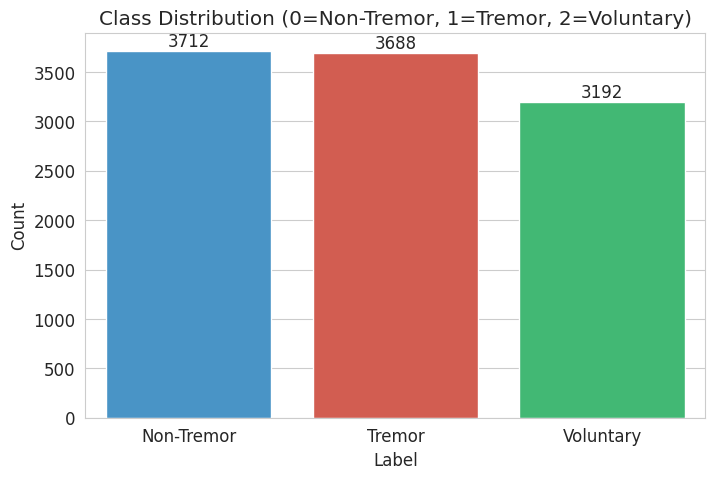

In [ ]:
print("\n" + "="*60)
print("BLOCK 1: Class Distribution (Non-Tremor / Tremor / Voluntary)")
print("="*60)
plot_class_distribution(y)


BLOCK 2: Feature Correlation Heatmap


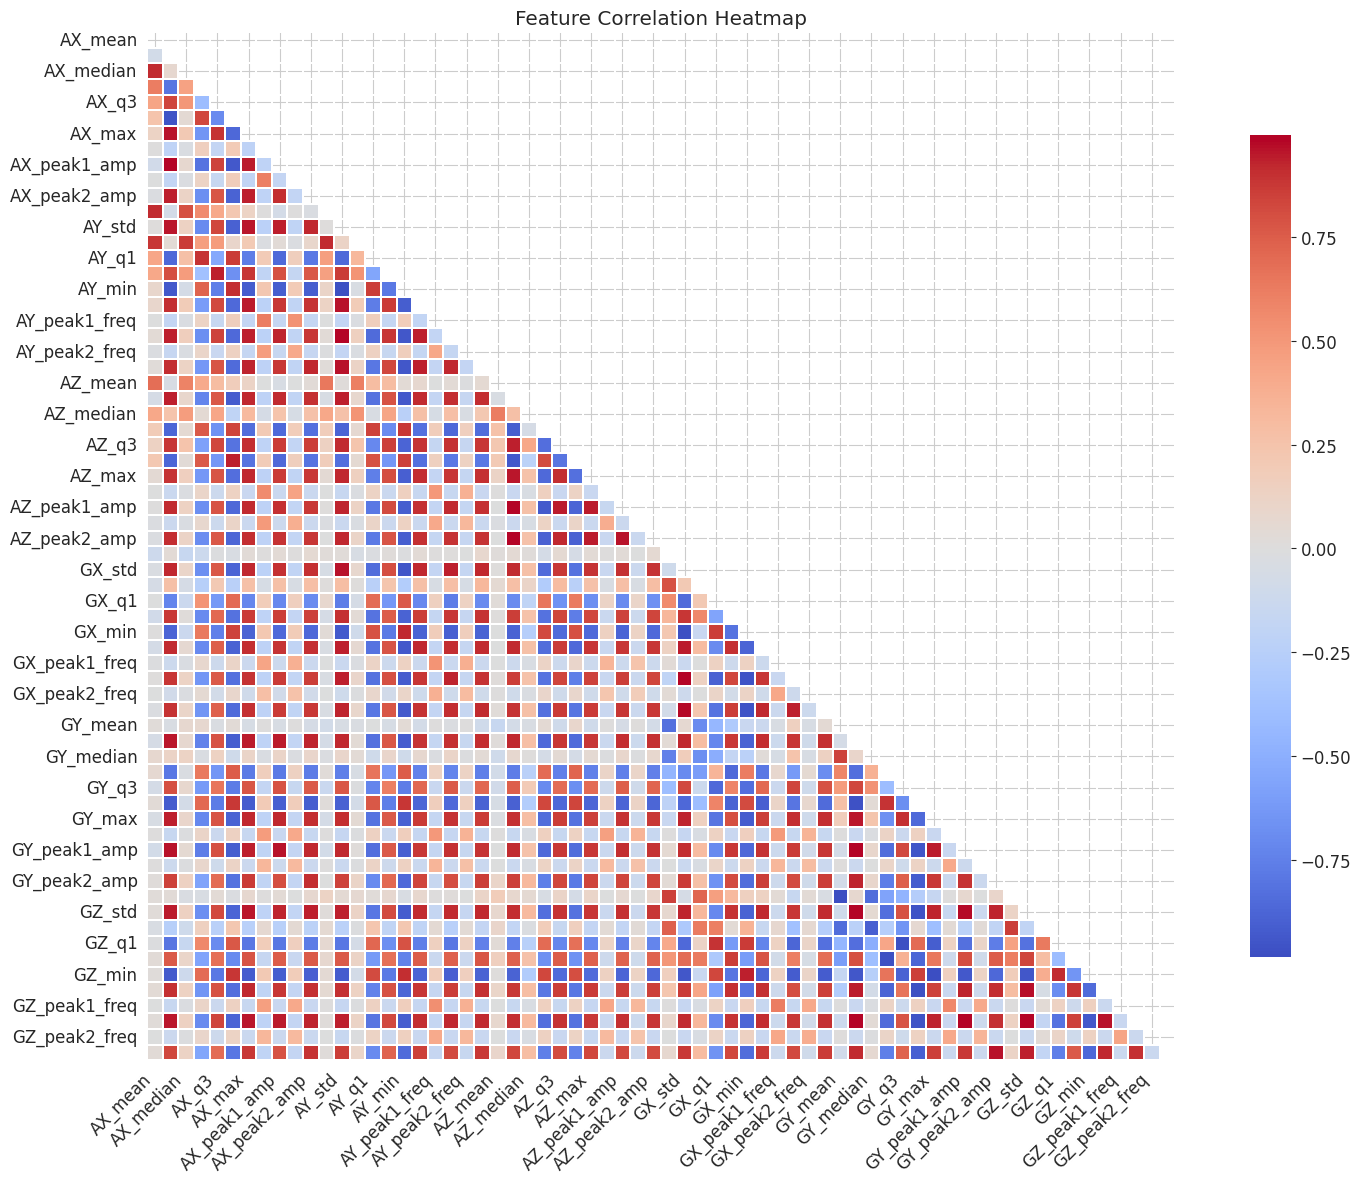

In [ ]:
print("\n" + "="*60)
print("BLOCK 2: Feature Correlation Heatmap")
print("="*60)
plot_correlation_heatmap(feature_df, "Feature Correlation Heatmap")


BLOCK 3: Key Features Boxplot (AY_std, GY_std, etc.)


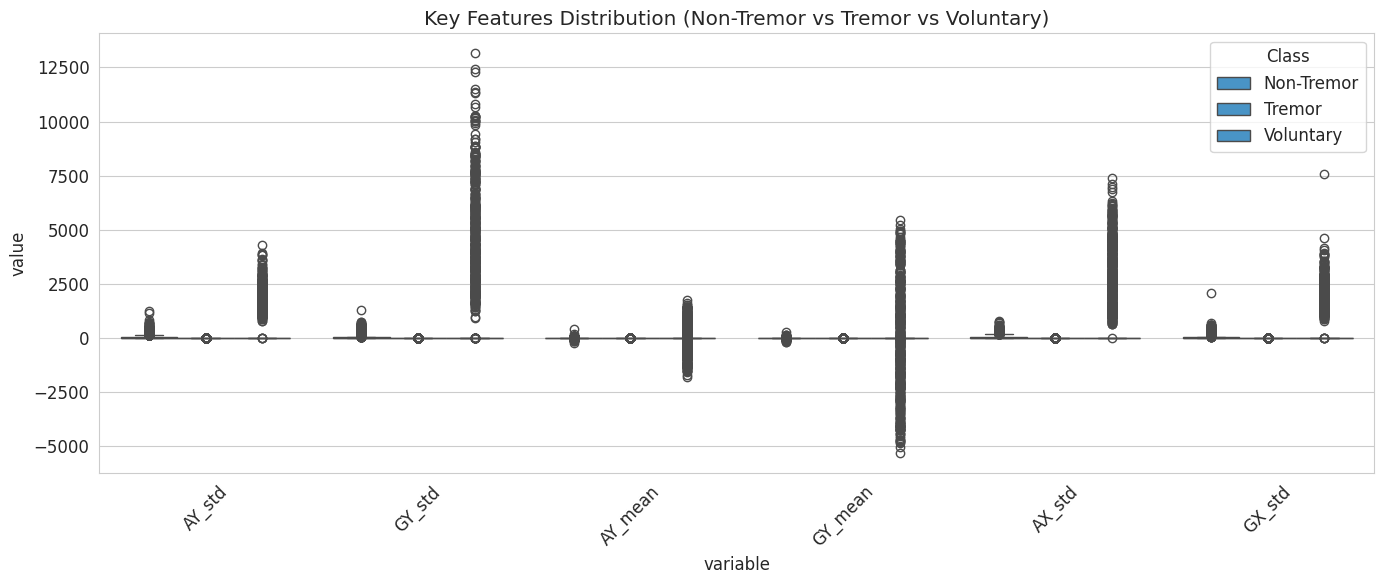

In [ ]:
print("\n" + "="*60)
print("BLOCK 3: Key Features Boxplot (AY_std, GY_std, etc.)")
print("="*60)
plot_key_features_boxplot(feature_df)


BLOCK 4: Frequency Features Boxplot


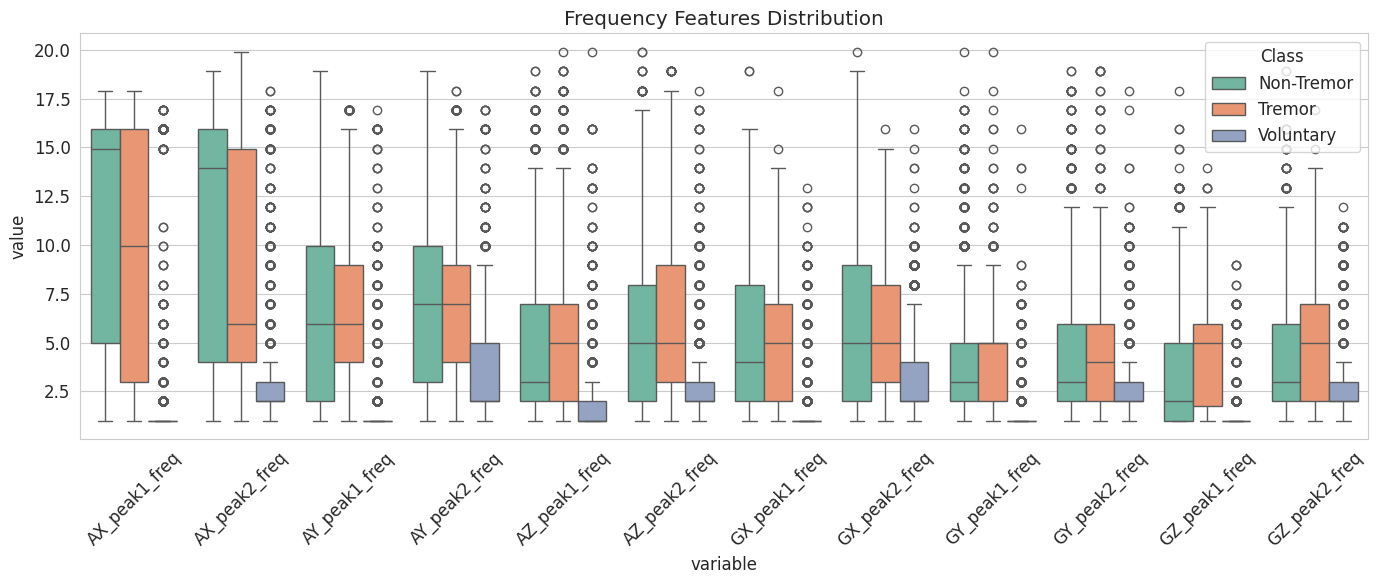

In [ ]:
print("\n" + "="*60)
print("BLOCK 4: Frequency Features Boxplot")
print("="*60)
plot_frequency_features(feature_df)


BLOCK 5: Dominant Frequency KDE (Peak1 Frequency)


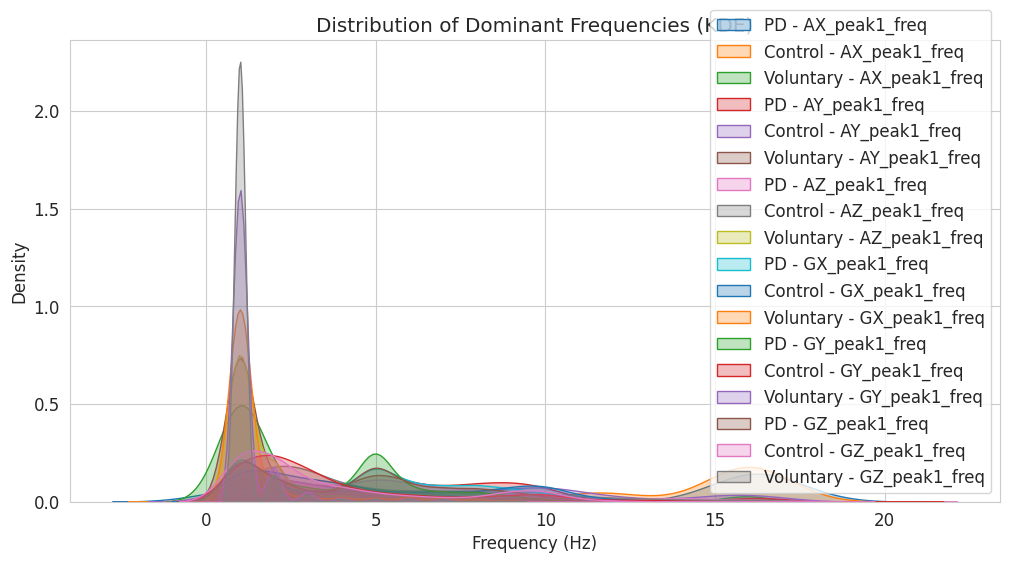

In [ ]:
print("\n" + "="*60)
print("BLOCK 5: Dominant Frequency KDE (Peak1 Frequency)")
print("="*60)
plot_dominant_freq_kde(feature_df)


BLOCK 6: Loading Raw Signals and Plotting Time Domain
Selected Parkinson file: Clean Dataset – Parkinson’s Group/ID07010201
Selected Control file: Clean Dataset – Control Group/ID01010100


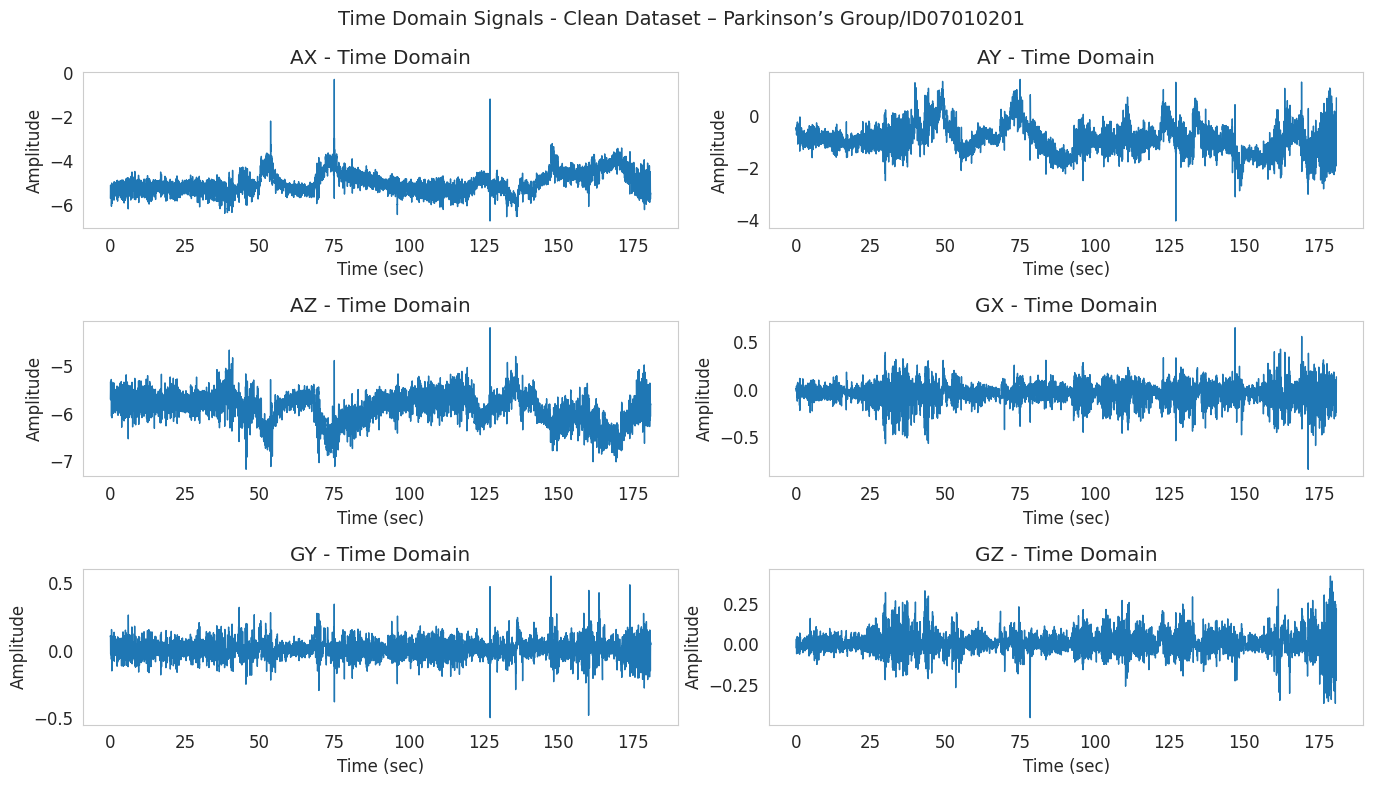

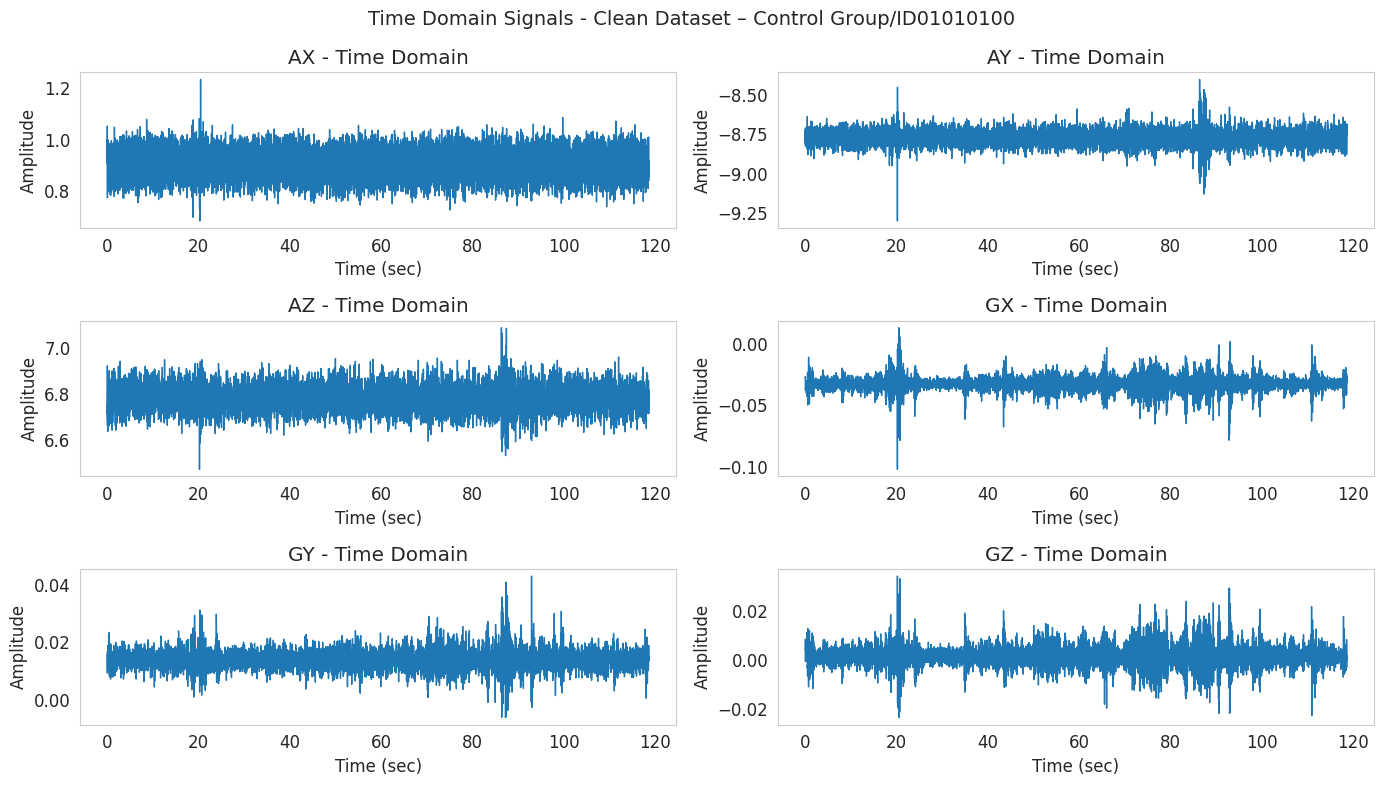

In [ ]:
print("\n" + "="*60)
print("BLOCK 6: Loading Raw Signals and Plotting Time Domain")
print("="*60)

# Load raw signals (only once, reuse for blocks 6-7)
raw_park = load_raw_signal(PARK_ZIP, 1)
raw_ctrl = load_raw_signal(CTRL_ZIP, 0)
raw_vol = load_raw_signal(VOL_ZIP, 2)
raw_df = pd.concat([raw_park, raw_ctrl, raw_vol], ignore_index=True)

# Get first file IDs for Parkinson and Control
park_id = raw_df[raw_df["label"] == 1]["file_id"].unique()[0]
ctrl_id = raw_df[raw_df["label"] == 0]["file_id"].unique()[0]

print(f"Selected Parkinson file: {park_id}")
print(f"Selected Control file: {ctrl_id}")

# Plot time signals
plot_time_signals(raw_df, park_id)
plot_time_signals(raw_df, ctrl_id)


BLOCK 7: FFT for Parkinson and Signal Comparison (AY axis)


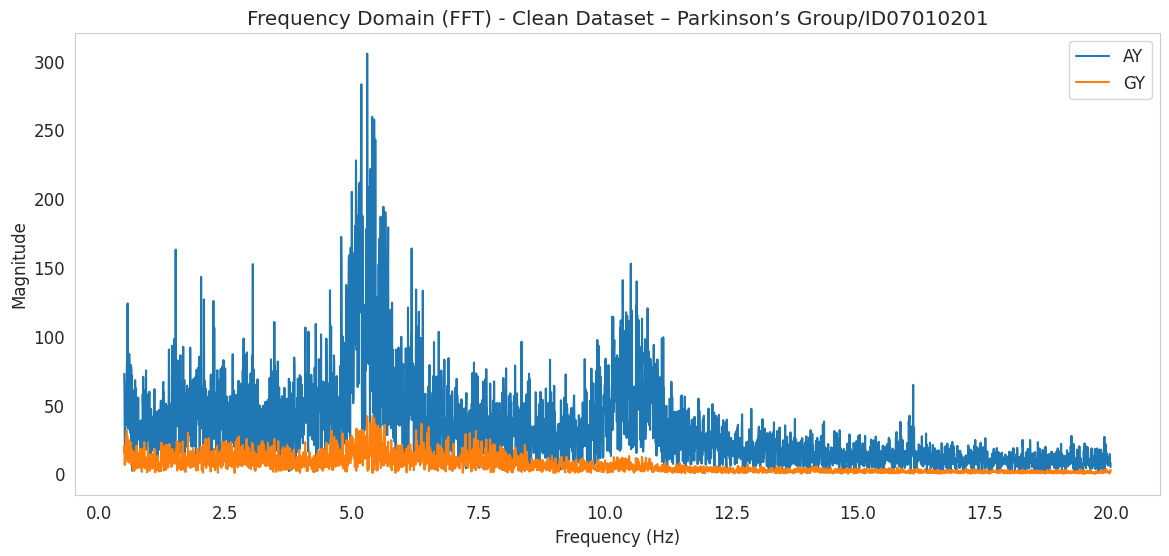

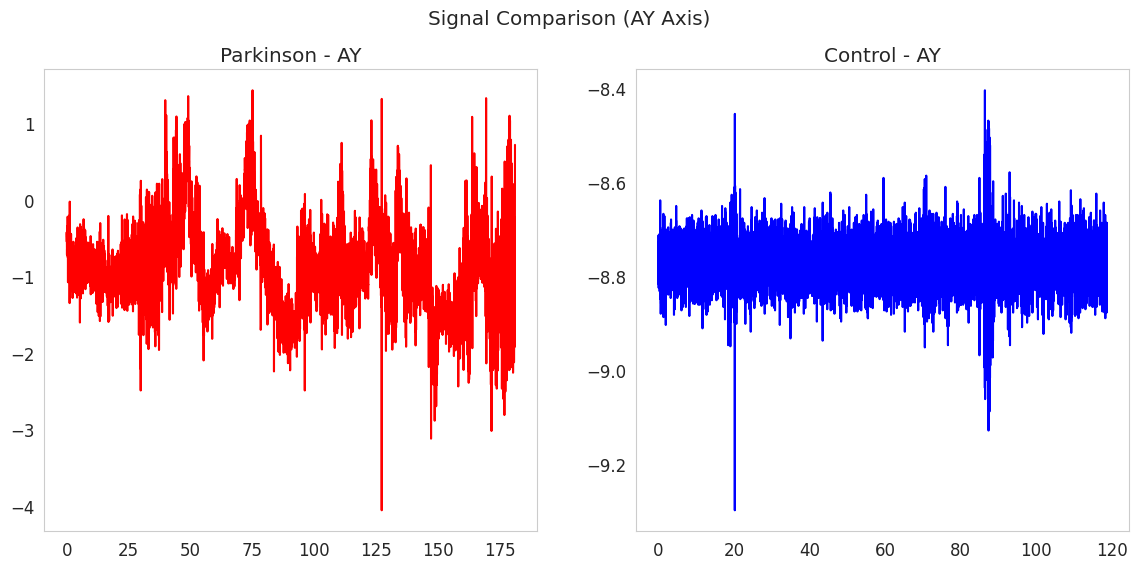

In [ ]:
print("\n" + "="*60)
print("BLOCK 7: FFT for Parkinson and Signal Comparison (AY axis)")
print("="*60)

plot_fft_signals(raw_df, park_id)
compare_signals(raw_df, park_id, ctrl_id)


BLOCK 8: Top 15 Features by Mutual Information


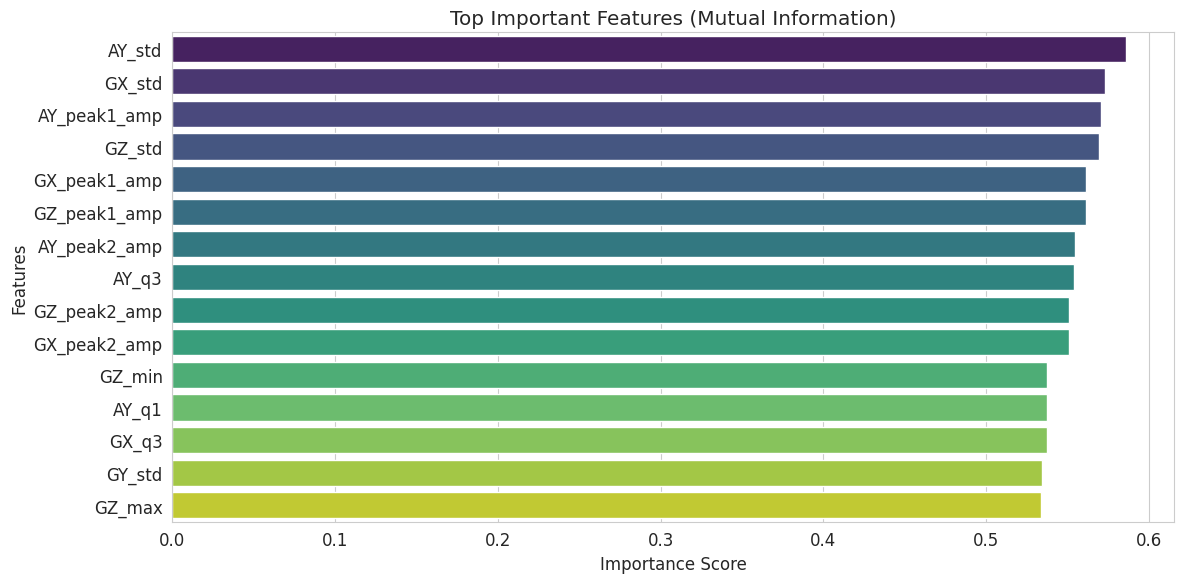

In [ ]:
print("\n" + "="*60)
print("BLOCK 8: Top 15 Features by Mutual Information")
print("="*60)
plot_top_features(feature_df, top_n=15)

# **Evaluation Functions**

In [ ]:
def evaluate_model(model, X, y, groups, title="Model", training_time=None, history=None):
    y_true_all = np.full(len(y), -1)
    y_pred_all = np.full(len(y), -1)
    y_proba_all = None
    model_copy = None

    for train_idx, test_idx in cv.split(X, y, groups):
        X_train = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
        X_test = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        model_copy = clone_model(model)
        model_copy.fit(X_train, y_train)
        y_pred = model_copy.predict(X_test)
        if y_pred.ndim > 1:
            y_pred = y_pred.ravel()
        y_pred_all[test_idx] = y_pred
        y_true_all[test_idx] = y_test
        if hasattr(model_copy, "predict_proba"):
            proba = model_copy.predict_proba(X_test)
            if y_proba_all is None:
                y_proba_all = np.zeros((len(y), proba.shape[1]))
            y_proba_all[test_idx] = proba

    valid = (y_true_all != -1)
    y_true_all = y[valid]
    y_pred_all = y_pred_all[valid]
    y_proba_all = y_proba_all[valid] if y_proba_all is not None else None

    # ----- WINDOW LEVEL -----
    print(f"\n===== {title} | WINDOW LEVEL =====")
    print(classification_report(y_true_all, y_pred_all,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - Window Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    if y_proba_all is not None:
        plot_multiclass_roc(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
        plot_precision_recall_curves(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
        acc, loss, precision, recall, f1, fnr = calculate_metrics(y_true_all, y_pred_all, y_proba_all)
        print(f"\n===== {title} | WINDOW LEVEL METRICS =====")
        print(f"Accuracy: {acc:.4f} | Log Loss: {loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")

    # ----- FILE LEVEL (Majority voting and average probabilities) -----
    vote_df = pd.DataFrame({"file_id": groups[valid], "y_true": y[valid], "y_pred": y_pred_all})
    if y_proba_all is not None:
        vote_df['proba'] = list(y_proba_all)
    file_pred = vote_df.groupby("file_id")["y_pred"].agg(lambda x: x.mode().iloc[0])
    file_true = vote_df.groupby("file_id")["y_true"].agg(lambda x: x.mode().iloc[0])
    if y_proba_all is not None:
        file_proba = vote_df.groupby("file_id")["proba"].apply(lambda x: np.mean(np.vstack(x), axis=0)).values
        file_proba = np.vstack(file_proba)
    else:
        file_proba = None

    print(f"\n===== {title} | FILE LEVEL =====")
    print(classification_report(file_true, file_pred,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm_file = confusion_matrix(file_true, file_pred)
    cm_file_percent = cm_file.astype('float') / cm_file.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_file_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - File Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    if file_proba is not None:
        plot_multiclass_roc(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
        plot_precision_recall_curves(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
        acc_f, loss_f, precision_f, recall_f, f1_f, fnr_f = calculate_metrics(file_true, file_pred, file_proba)
        print(f"\n===== {title} | FILE LEVEL METRICS =====")
        print(f"Accuracy: {acc_f:.4f} | Log Loss: {loss_f:.4f} | Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f} | FNR: {fnr_f:.4f}")
    else:
        acc_f = accuracy_score(file_true, file_pred)
        precision_f = precision_score(file_true, file_pred, average='macro', zero_division=0)
        recall_f = recall_score(file_true, file_pred, average='macro', zero_division=0)
        f1_f = f1_score(file_true, file_pred, average='macro', zero_division=0)
        fnr_f = 1 - recall_f
        loss_f = np.nan
        print(f"\n===== {title} | FILE LEVEL METRICS (no probabilities) =====")
        print(f"Accuracy: {acc_f:.4f} | Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f} | FNR: {fnr_f:.4f}")

    # Store metrics in global dictionary (both levels)
    if 'all_models_metrics' not in globals():
        global all_models_metrics
        all_models_metrics = {}
    all_models_metrics[f"{title}_window"] = {
        'Accuracy': acc, 'Loss': loss, 'Precision': precision,
        'Recall': recall, 'F1': f1, 'FNR': fnr,
        'Training Time': training_time
    }
    all_models_metrics[f"{title}_file"] = {
        'Accuracy': acc_f, 'Loss': loss_f, 'Precision': precision_f,
        'Recall': recall_f, 'F1': f1_f, 'FNR': fnr_f,
        'Training Time': training_time
    }

    if history is not None:
        plot_training_history(history, title, level="Window")

    X_file, y_file, _ = get_file_level_features(X, y, groups)
    if "MLP" in title or "LSTM" in title or "TabNet" in title or "CNN+LSTM" in title:
        X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_file, y_file, test_size=0.2, random_state=RANDOM_STATE)

        if "MLP" in title:
            def build_keras_mlp(input_dim):
                model = Sequential([
                    Input(shape=(input_dim,)),
                    Dense(256, activation='relu'), BatchNormalization(), Dropout(0.3),
                    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
                    Dense(64, activation='relu'), Dropout(0.2),
                    Dense(3, activation='softmax')
                ])
                model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
                return model
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            file_model = build_keras_mlp(X_train_scaled.shape[1])
            hist_file = file_model.fit(X_train_scaled, y_train_f, validation_data=(X_val_scaled, y_val_f),
                                       epochs=100, batch_size=64, verbose=0,
                                       callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
            plot_training_history(hist_file, title, level="File")

        elif "LSTM" in title:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
            X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
            model_file = Sequential([
                Input(shape=(1, X_train_scaled.shape[1])),
                LSTM(64), Dropout(0.3),
                Dense(32, activation='relu'), Dropout(0.3),
                Dense(3, activation='softmax')
            ])
            model_file.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            hist_file = model_file.fit(X_train_reshaped, y_train_f, validation_data=(X_val_reshaped, y_val_f),
                                       epochs=50, batch_size=32, verbose=0,
                                       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
            plot_training_history(hist_file, title, level="File")

        elif "TabNet" in title:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            mlp_file = MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', max_iter=200,
                                     early_stopping=True, validation_fraction=0.2, random_state=RANDOM_STATE)
            mlp_file.fit(X_train_scaled, y_train_f)
            print(f"File-level training for {title} completed (no history plot available for TabNet/MLP).")

        elif "CNN+LSTM" in title:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
            X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
            model_file = Sequential([
                Input(shape=(X_train_scaled.shape[1], 1)),
                Conv1D(64, 3, activation='relu', padding='same'), BatchNormalization(),
                Conv1D(32, 3, activation='relu', padding='same'), BatchNormalization(),
                MaxPooling1D(2, padding='same'),   # <-- أضف padding='same'
                LSTM(64, return_sequences=True), Dropout(0.3),
                LSTM(32), Dropout(0.3),
                Dense(64, activation='relu'),
                Dense(3, activation='softmax')
            ])
            model_file.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            hist_file = model_file.fit(X_train_reshaped, y_train_f, validation_data=(X_val_reshaped, y_val_f),
                                       epochs=50, batch_size=32, verbose=0,
                                       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
            plot_training_history(hist_file, title, level="File")

    return model_copy

In [ ]:
def evaluate_cnn_lstm_model(model_builder, best_params, X, y, groups, title="CNN+LSTM", training_time=None):
    y_true_all = []
    y_pred_all = []
    y_proba_all = []
    all_groups = []

    for train_idx, test_idx in cv.split(X, y, groups):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        test_groups = groups[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
        X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

        model = model_builder(X_train_scaled.shape[1],
                              conv_filters=best_params["conv_filters"],
                              lstm_units=best_params["lstm_units"],
                              dropout=best_params["dropout"])
        model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, verbose=0, validation_data=(X_test_scaled, y_test))

        y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
        y_proba = model.predict(X_test_scaled, verbose=0)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)
        all_groups.extend(test_groups)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_proba_all = np.array(y_proba_all)
    all_groups = np.array(all_groups)

    # ----- WINDOW LEVEL -----
    print(f"\n===== {title} | WINDOW LEVEL =====")
    print(classification_report(y_true_all, y_pred_all,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - Window Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    plot_multiclass_roc(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
    plot_precision_recall_curves(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
    acc, loss, precision, recall, f1, fnr = calculate_metrics(y_true_all, y_pred_all, y_proba_all)
    print(f"\n===== {title} | WINDOW LEVEL METRICS =====")
    print(f"Accuracy: {acc:.4f} | Log Loss: {loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")

    # ----- FILE LEVEL -----
    vote_df = pd.DataFrame({"file_id": all_groups, "y_true": y_true_all, "y_pred": y_pred_all})
    vote_df['proba'] = list(y_proba_all)
    file_pred = vote_df.groupby("file_id")["y_pred"].agg(lambda x: x.mode().iloc[0])
    file_true = vote_df.groupby("file_id")["y_true"].agg(lambda x: x.mode().iloc[0])
    file_proba = vote_df.groupby("file_id")["proba"].apply(lambda x: np.mean(np.vstack(x), axis=0)).values
    file_proba = np.vstack(file_proba)

    print(f"\n===== {title} | FILE LEVEL =====")
    print(classification_report(file_true, file_pred,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm_file = confusion_matrix(file_true, file_pred)
    cm_file_percent = cm_file.astype('float') / cm_file.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_file_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - File Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    plot_multiclass_roc(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
    plot_precision_recall_curves(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
    acc_f, loss_f, precision_f, recall_f, f1_f, fnr_f = calculate_metrics(file_true, file_pred, file_proba)
    print(f"\n===== {title} | FILE LEVEL METRICS =====")
    print(f"Accuracy: {acc_f:.4f} | Log Loss: {loss_f:.4f} | Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f} | FNR: {fnr_f:.4f}")

    if 'all_models_metrics' not in globals():
        global all_models_metrics
        all_models_metrics = {}
    all_models_metrics[f"{title}_window"] = {
        'Accuracy': acc, 'Loss': loss, 'Precision': precision,
        'Recall': recall, 'F1': f1, 'FNR': fnr,
        'Training Time': training_time
    }
    all_models_metrics[f"{title}_file"] = {
        'Accuracy': acc_f, 'Loss': loss_f, 'Precision': precision_f,
        'Recall': recall_f, 'F1': f1_f, 'FNR': fnr_f,
        'Training Time': training_time
    }

    X_file, y_file, _ = get_file_level_features(X, y, groups)
    X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_file, y_file, test_size=0.2, random_state=RANDOM_STATE)

    scaler_file = StandardScaler()
    X_train_scaled_f = scaler_file.fit_transform(X_train_f)
    X_val_scaled_f = scaler_file.transform(X_val_f)
    X_train_reshaped_f = X_train_scaled_f.reshape(X_train_scaled_f.shape[0], 1, X_train_scaled_f.shape[1])
    X_val_reshaped_f = X_val_scaled_f.reshape(X_val_scaled_f.shape[0], 1, X_val_scaled_f.shape[1])

    file_model = Sequential([
        Input(shape=(1, X_train_scaled_f.shape[1])),
        Conv1D(64, 3, activation='relu', padding='same'), BatchNormalization(),
        Conv1D(32, 3, activation='relu', padding='same'), BatchNormalization(),
        MaxPooling1D(2, padding='same'),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32), Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    file_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_file = file_model.fit(X_train_reshaped_f, y_train_f,
                               validation_data=(X_val_reshaped_f, y_val_f),
                               epochs=50, batch_size=32, verbose=0,
                               callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
    plot_training_history(hist_file, title, level="File")

In [ ]:
def clone_model(model):
    """Return a fresh copy of the model (handles sklearn pipelines and custom deep models)."""

    # If it's a sklearn pipeline (has named_steps), try to clone normally
    if hasattr(model, 'named_steps'):
        try:
            return sklearn_clone(model)
        except Exception:
            pass
    # For LSTMClassifier3
    if hasattr(model, 'named_steps') and isinstance(model.named_steps.get('clf'), LSTMClassifier3):
        # Extract parameters and recreate
        clf = model.named_steps['clf']
        new_clf = LSTMClassifier3(units=clf.units, dropout=clf.dropout,
                                  batch_size=clf.batch_size, epochs=clf.epochs,
                                  optimizer=clf.optimizer)
        return Pipeline([('clf', new_clf)])

    # For TabNetWrapper3
    if hasattr(model, 'named_steps') and isinstance(model.named_steps.get('clf'), TabNetWrapper3):
        clf = model.named_steps['clf']
        new_clf = TabNetWrapper3(n_d=clf.n_d, n_a=clf.n_a, n_steps=clf.n_steps,
                                 gamma=clf.gamma, lr=clf.lr,
                                 max_epochs=clf.max_epochs, patience=clf.patience,
                                 seed=clf.seed)
        return Pipeline([('smote', model.named_steps.get('smote')), ('clf', new_clf)])


    # For MLP (sklearn pipeline), just clone
    try:
        return sklearn_clone(model)
    except:
        return model

In [ ]:
def plot_multiclass_roc(y_true, y_pred_proba, class_names, level="Window"):
    """Plot ROC curves for each class (one-vs-rest)"""
    y_bin = label_binarize(y_true, classes=[0,1,2])
    n_classes = y_bin.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    plt.figure(figsize=(8,6))
    colors = ['green', 'red', 'blue']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curves ({level} Level)')
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
def calculate_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    fnr = 1 - recall
    loss = log_loss(y_true, y_proba, labels=[0,1,2])
    return acc, loss, precision, recall, f1, fnr

def plot_precision_recall_curves(y_true, y_proba, class_names, level="Window"):
    """Plot Precision-Recall curves for each class (one-vs-rest)"""
    n_classes = 3
    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        precision_curve, recall_curve, _ = precision_recall_curve(y_true == i, y_proba[:, i])
        ap_score = average_precision_score(y_true == i, y_proba[:, i])
        plt.plot(recall_curve, precision_curve, lw=2, label=f'{class_names[i]} (AP = {ap_score:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves ({level} Level)')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

def plot_training_history(history, title="Model", level="Window"):
    """Plot training and validation loss & accuracy.
    Supports Keras and TabNet history objects."""
    if history is None:
        print(f"No history to plot for {title}")
        return

    # Extract dictionary
    if hasattr(history, 'history'):
        hist_dict = history.history
    elif isinstance(history, dict):
        hist_dict = history
    else:
        hist_dict = getattr(history, 'history', {})
        if not hist_dict:
            hist_dict = getattr(history, 'history_', {})

    if not hist_dict:
        print(f"History dictionary is empty for {title}")
        return

    print(f"Available history keys for {title}: {list(hist_dict.keys())}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ----- Loss -----
    train_loss_key = None
    val_loss_key = None
    for key in hist_dict.keys():
        if 'loss' in key.lower() and 'val' not in key.lower():
            train_loss_key = key
            break
    for key in hist_dict.keys():
        if 'val' in key.lower() and 'loss' in key.lower():
            val_loss_key = key
            break

    if train_loss_key:
        axes[0].plot(hist_dict[train_loss_key], label='Train Loss')
    if val_loss_key:
        axes[0].plot(hist_dict[val_loss_key], label='Validation Loss')
    if train_loss_key or val_loss_key:
        axes[0].set_title(f'{title} - Loss ({level} Level)')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, 'No loss data', ha='center', va='center')

    # ----- Accuracy -----
    train_acc_key = None
    val_acc_key = None
    for key in hist_dict.keys():
        if 'accuracy' in key.lower() and 'val' not in key.lower():
            train_acc_key = key
            break
    for key in hist_dict.keys():
        if 'val' in key.lower() and 'accuracy' in key.lower():
            val_acc_key = key
            break

    if train_acc_key is None and val_acc_key is None:
        axes[1].text(0.5, 0.5, 'No accuracy data', ha='center', va='center')
    else:
        if train_acc_key:
            axes[1].plot(hist_dict[train_acc_key], label='Train Accuracy')
        if val_acc_key:
            axes[1].plot(hist_dict[val_acc_key], label='Validation Accuracy')
        axes[1].set_title(f'{title} - Accuracy ({level} Level)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

def get_file_level_features(X_window, y_window, groups_window):
    """
    Aggregate window-level features to file-level by taking mean of features per file.
    Returns:
        X_file: array of shape (n_files, n_features)
        y_file: array of shape (n_files,)
        file_ids: list of unique file IDs
    """
    df = pd.DataFrame(X_window)
    df['y'] = y_window
    df['group'] = groups_window
    # Group by file_id (group) and calculate mean of all features
    X_file = df.groupby('group').mean().drop(['y'], axis=1).values
    y_file = df.groupby('group')['y'].agg(lambda x: x.mode().iloc[0]).values
    file_ids = df.groupby('group').apply(lambda x: x.name).tolist()
    return X_file, y_file, file_ids

# **Randomized Search for ML Hyper-parameters**

In [ ]:
def train_and_evaluate(model_pipeline, param_grid, X, y, groups, title):
    start_time = time.time()
    search = RandomizedSearchCV(model_pipeline, param_grid, n_iter=15,
                                scoring='f1_macro', cv=cv, random_state=RANDOM_STATE,
                                n_jobs=-1, verbose=1)
    search.fit(X, y, groups=groups)
    elapsed = time.time() - start_time
    print(f"Training time for {title}: {elapsed:.2f} seconds")
    best_est = search.best_estimator_
    evaluate_model(best_est, X, y, groups, title=title, training_time=elapsed)
    return best_est

# **Machine Learning Models**

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for LightGBM : 181.25 seconds

===== LightGBM  | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.83      0.91      0.87      3712
      Tremor       0.84      0.81      0.82      3688
   Voluntary       0.97      0.90      0.93      3192

    accuracy                           0.87     10592
   macro avg       0.88      0.87      0.87     10592
weighted avg       0.87      0.87      0.87     10592



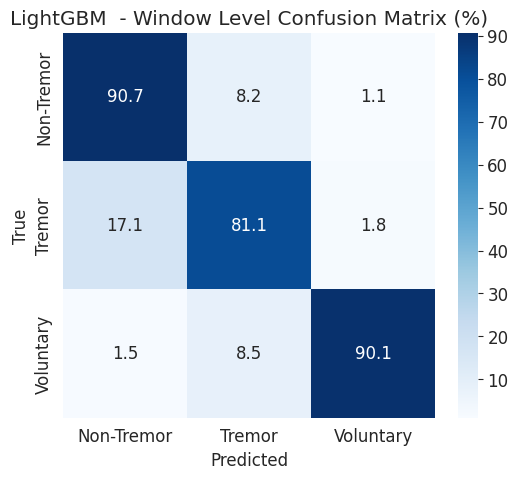

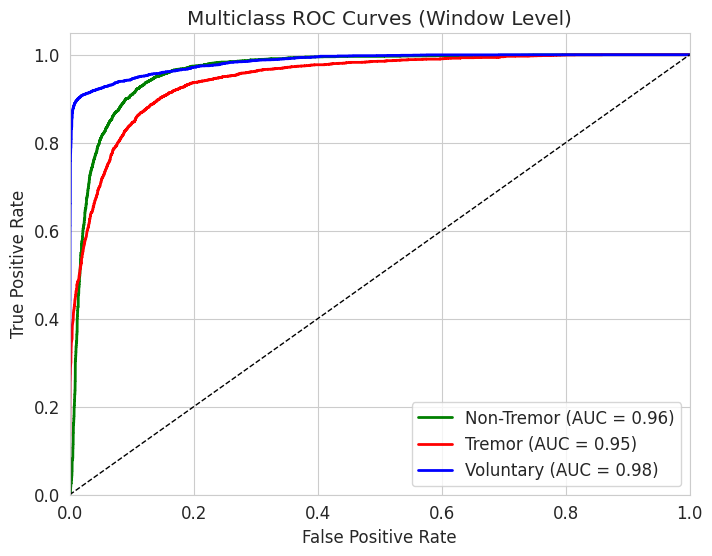

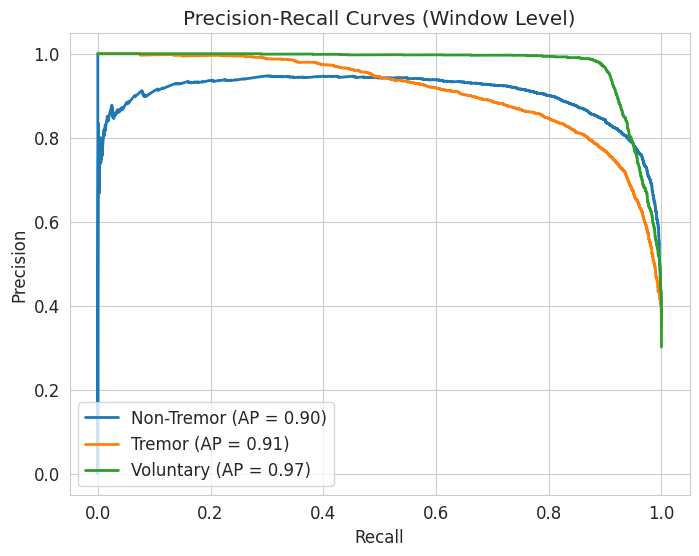


===== LightGBM  | WINDOW LEVEL METRICS =====
Accuracy: 0.8719 | Log Loss: 0.6197 | Precision: 0.8788 | Recall: 0.8731 | F1: 0.8750 | FNR: 0.1269

===== LightGBM  | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.98      0.97        59
      Tremor       0.95      0.91      0.93        23
   Voluntary       1.00      1.00      1.00        34

    accuracy                           0.97       116
   macro avg       0.97      0.97      0.97       116
weighted avg       0.97      0.97      0.97       116



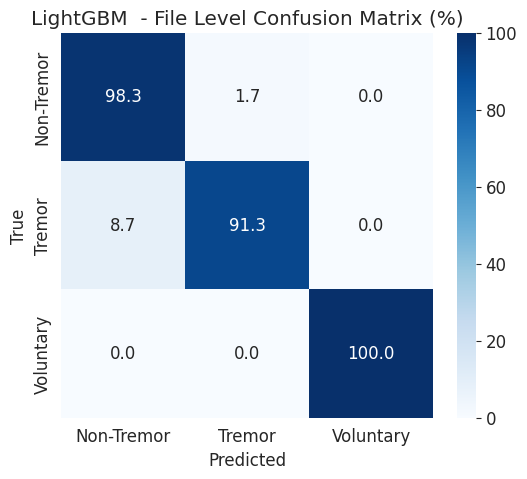

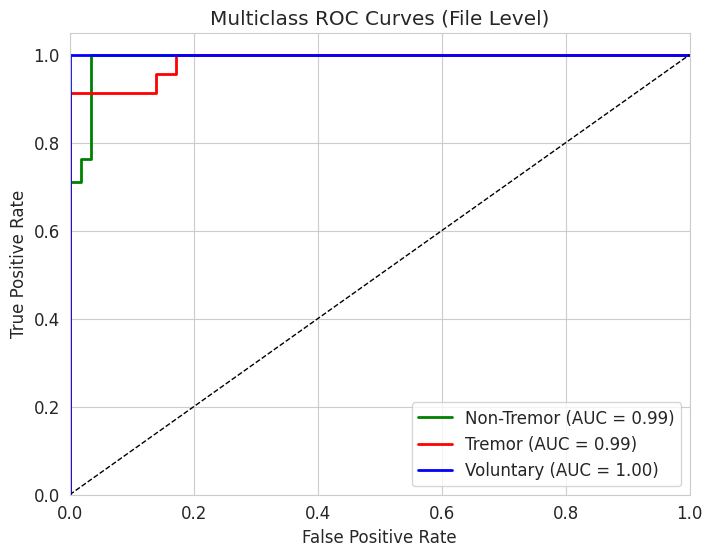

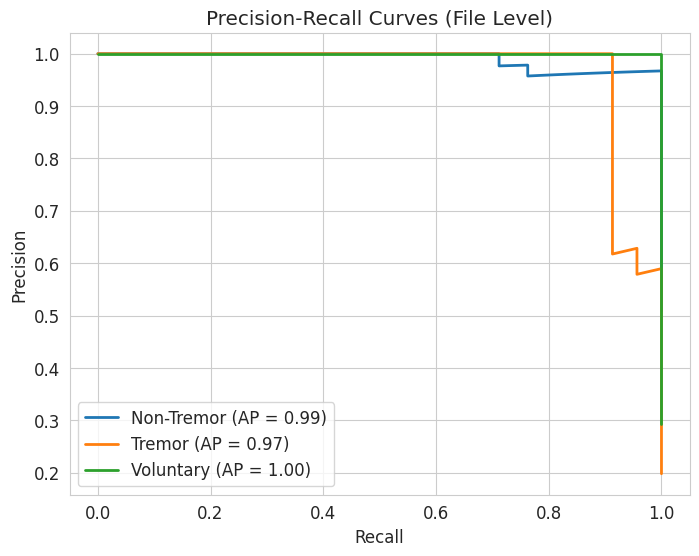


===== LightGBM  | FILE LEVEL METRICS =====
Accuracy: 0.9741 | Log Loss: 0.1326 | Precision: 0.9737 | Recall: 0.9654 | F1: 0.9694 | FNR: 0.0346


In [ ]:
# LightGBM
lgb_pipe = Pipeline([#("scaler", StandardScaler()),
                     ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])
lgb_params = {"clf__n_estimators": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
              "clf__num_leaves": [15,31,63], "clf__max_depth": [-1,5,10]}
best_lgb = train_and_evaluate(lgb_pipe, lgb_params, X, y, groups, "LightGBM ")

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for CatBoost: 1023.62 seconds

===== CatBoost | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.83      0.90      0.86      3712
      Tremor       0.84      0.79      0.81      3688
   Voluntary       0.94      0.91      0.92      3192

    accuracy                           0.86     10592
   macro avg       0.87      0.86      0.87     10592
weighted avg       0.86      0.86      0.86     10592



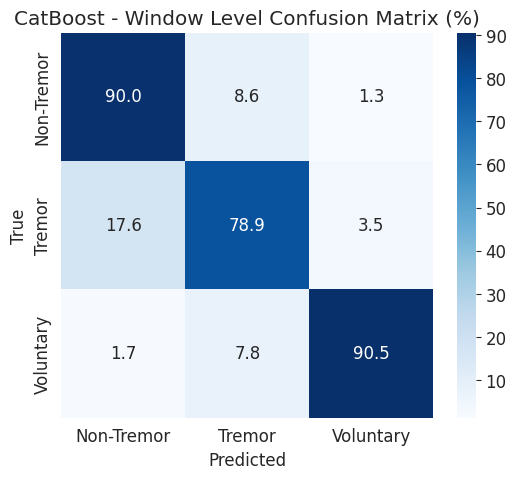

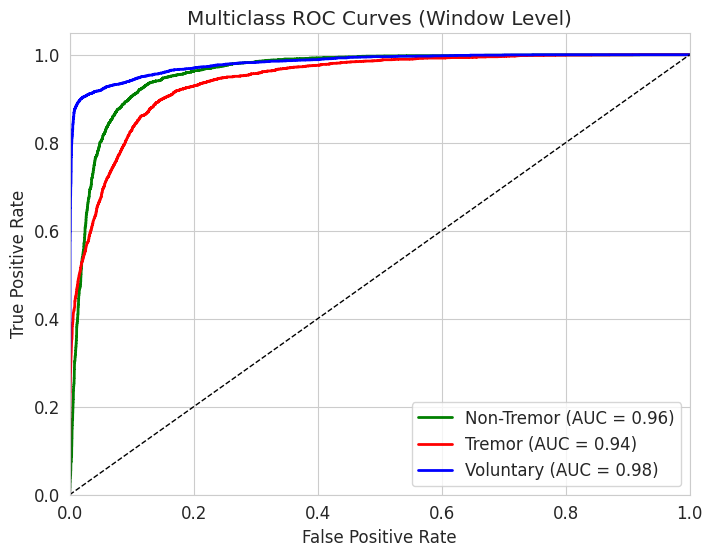

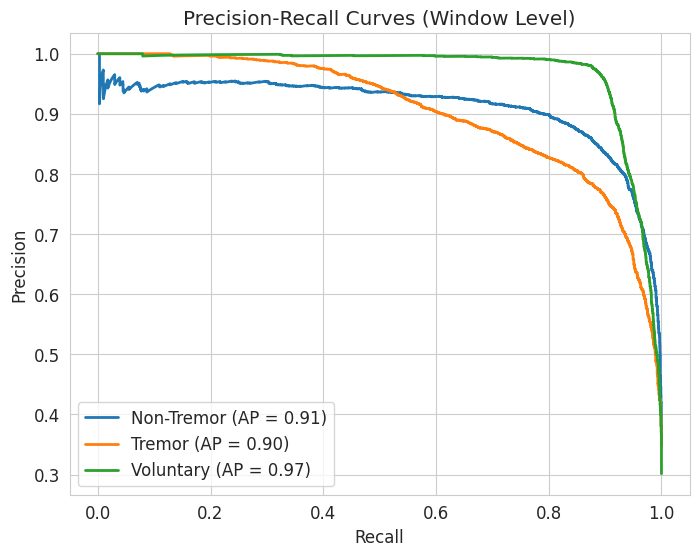


===== CatBoost | WINDOW LEVEL METRICS =====
Accuracy: 0.8631 | Log Loss: 0.3768 | Precision: 0.8682 | Recall: 0.8649 | F1: 0.8657 | FNR: 0.1351

===== CatBoost | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.98      0.97        59
      Tremor       0.95      0.91      0.93        23
   Voluntary       1.00      1.00      1.00        34

    accuracy                           0.97       116
   macro avg       0.97      0.97      0.97       116
weighted avg       0.97      0.97      0.97       116



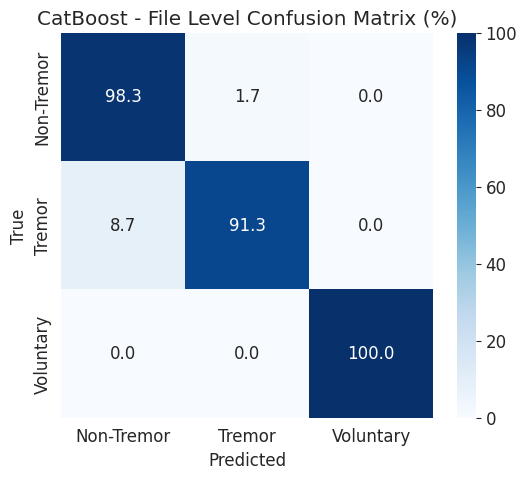

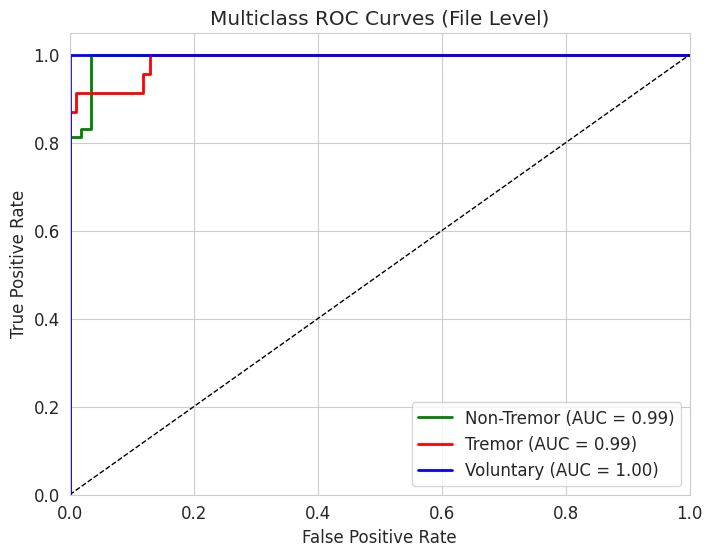

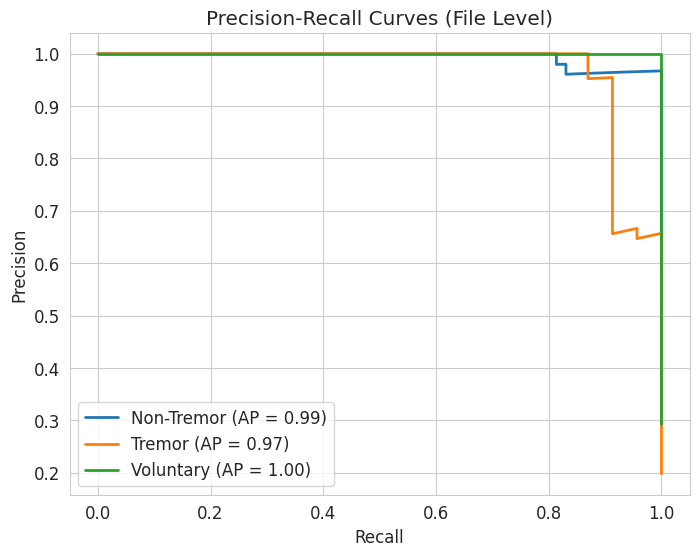


===== CatBoost | FILE LEVEL METRICS =====
Accuracy: 0.9741 | Log Loss: 0.1825 | Precision: 0.9737 | Recall: 0.9654 | F1: 0.9694 | FNR: 0.0346


In [ ]:
# CatBoost

cat_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0))])
cat_params = {"clf__iterations": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
              "clf__depth": [4,6,8]}
best_cat = train_and_evaluate(cat_pipe, cat_params, X, y, groups, "CatBoost")


Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for XGBoost (3-class): 484.81 seconds

===== XGBoost (3-class) | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.82      0.91      0.86      3712
      Tremor       0.84      0.80      0.82      3688
   Voluntary       0.96      0.90      0.93      3192

    accuracy                           0.87     10592
   macro avg       0.88      0.87      0.87     10592
weighted avg       0.87      0.87      0.87     10592



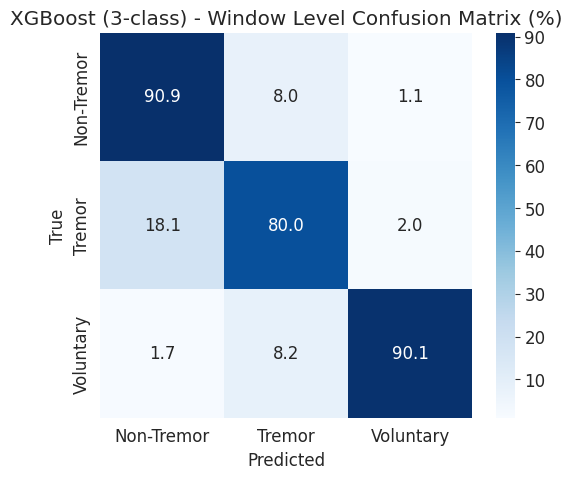

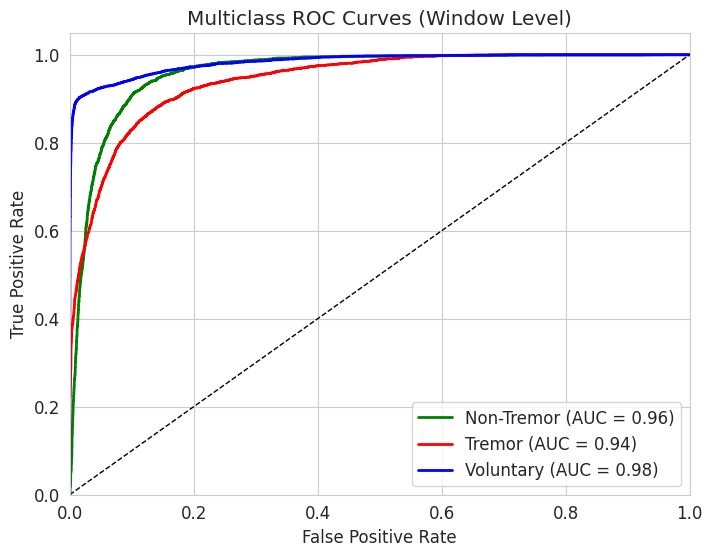

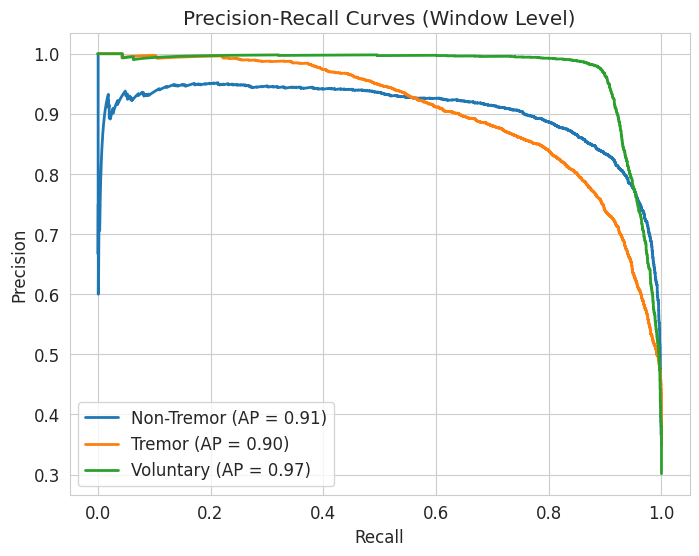


===== XGBoost (3-class) | WINDOW LEVEL METRICS =====
Accuracy: 0.8685 | Log Loss: 0.4452 | Precision: 0.8756 | Recall: 0.8699 | F1: 0.8715 | FNR: 0.1301

===== XGBoost (3-class) | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.98      0.97        59
      Tremor       0.95      0.91      0.93        23
   Voluntary       1.00      1.00      1.00        34

    accuracy                           0.97       116
   macro avg       0.97      0.97      0.97       116
weighted avg       0.97      0.97      0.97       116



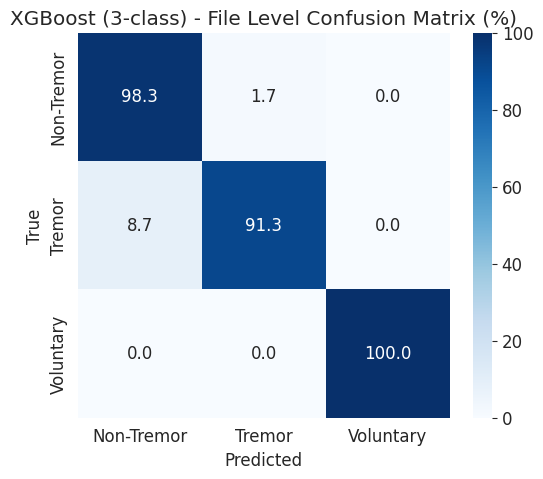

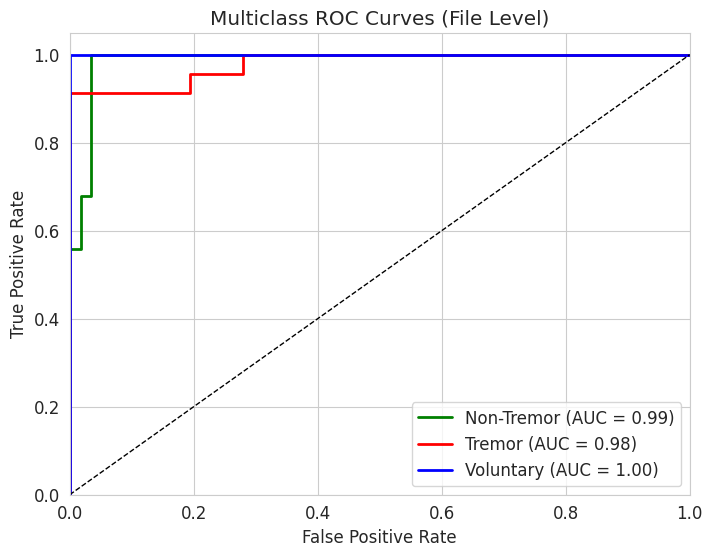

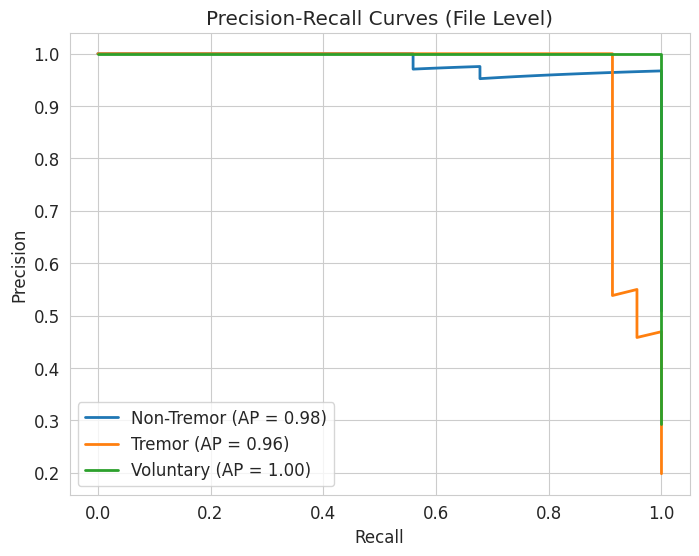


===== XGBoost (3-class) | FILE LEVEL METRICS =====
Accuracy: 0.9741 | Log Loss: 0.1564 | Precision: 0.9737 | Recall: 0.9654 | F1: 0.9694 | FNR: 0.0346


In [ ]:
# XGBoost

xgb_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))])
xgb_params = {"clf__n_estimators": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
              "clf__max_depth": [3,5,7]}
best_xgb = train_and_evaluate(xgb_pipe, xgb_params, X, y, groups, "XGBoost (3-class)")


Fitting 4 folds for each of 9 candidates, totalling 36 fits
Training time for SVM: 817.00 seconds

===== SVM | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.76      0.79      0.78      3712
      Tremor       0.72      0.62      0.66      3688
   Voluntary       0.78      0.88      0.83      3192

    accuracy                           0.76     10592
   macro avg       0.75      0.76      0.76     10592
weighted avg       0.75      0.76      0.75     10592



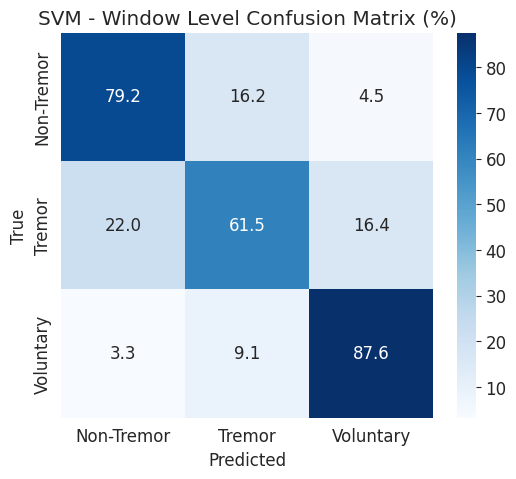

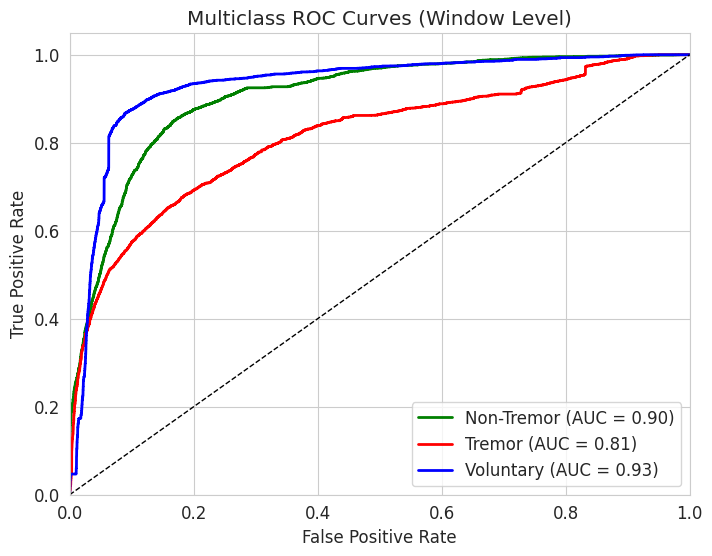

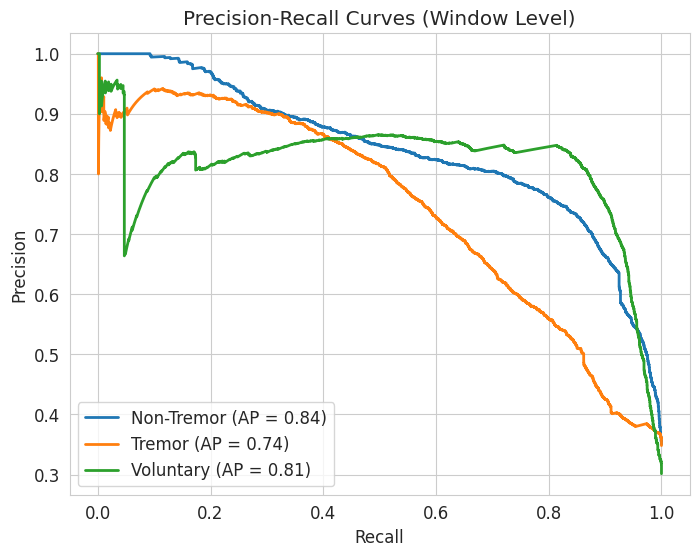


===== SVM | WINDOW LEVEL METRICS =====
Accuracy: 0.7558 | Log Loss: 0.6291 | Precision: 0.7541 | Recall: 0.7611 | F1: 0.7553 | FNR: 0.2389

===== SVM | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.94      0.98      0.96        59
      Tremor       0.94      0.65      0.77        23
   Voluntary       0.89      1.00      0.94        34

    accuracy                           0.92       116
   macro avg       0.92      0.88      0.89       116
weighted avg       0.92      0.92      0.92       116



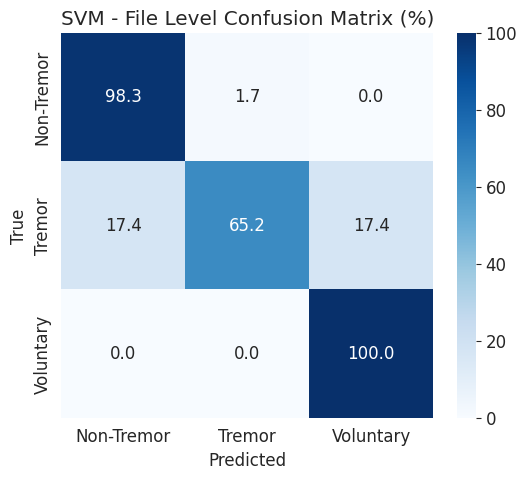

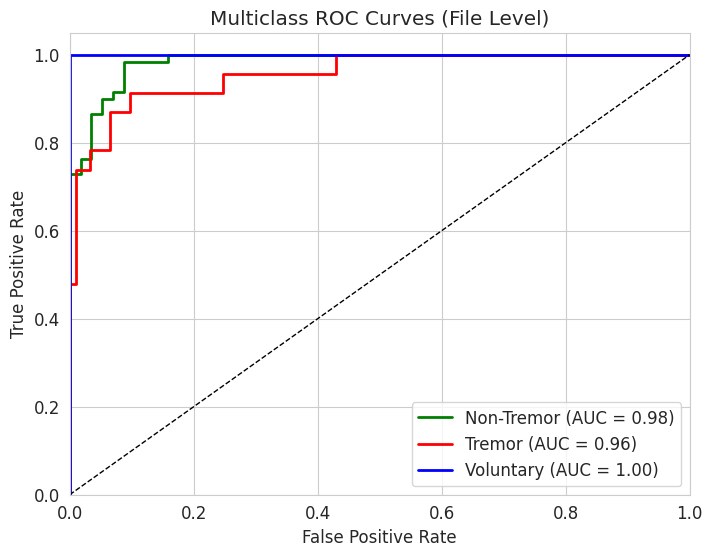

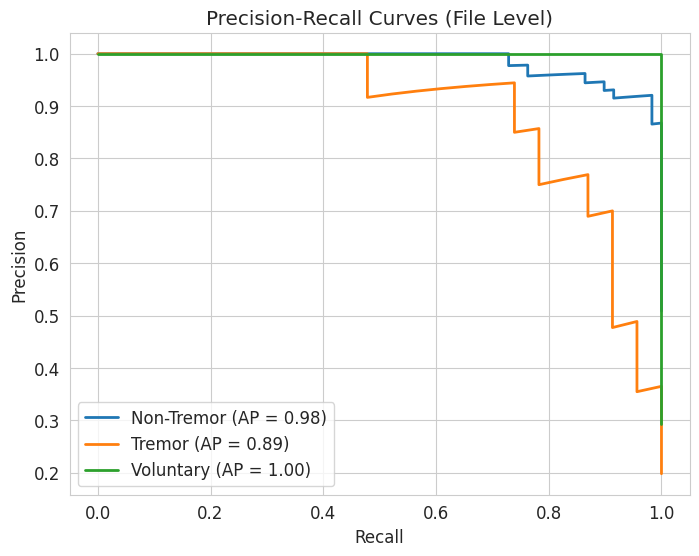


===== SVM | FILE LEVEL METRICS =====
Accuracy: 0.9224 | Log Loss: 0.3841 | Precision: 0.9226 | Recall: 0.8784 | F1: 0.8908 | FNR: 0.1216


In [ ]:
# SVM

svm_pipe = Pipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", SVC(probability=True))])
svm_params = {"clf__C": [0.1,1,10], "clf__gamma": ['scale',0.1,0.01]}
best_svm = train_and_evaluate(svm_pipe, svm_params, X, y, groups, "SVM")


Fitting 4 folds for each of 9 candidates, totalling 36 fits
Training time for Random Forest: 575.25 seconds

===== Random Forest | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.82      0.90      0.85      3712
      Tremor       0.83      0.79      0.81      3688
   Voluntary       0.96      0.90      0.93      3192

    accuracy                           0.86     10592
   macro avg       0.87      0.86      0.86     10592
weighted avg       0.86      0.86      0.86     10592



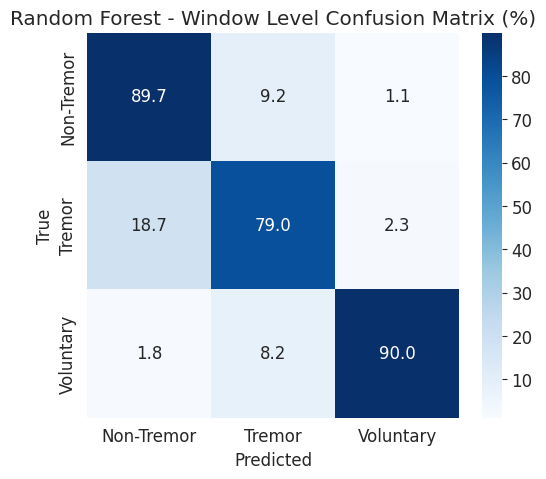

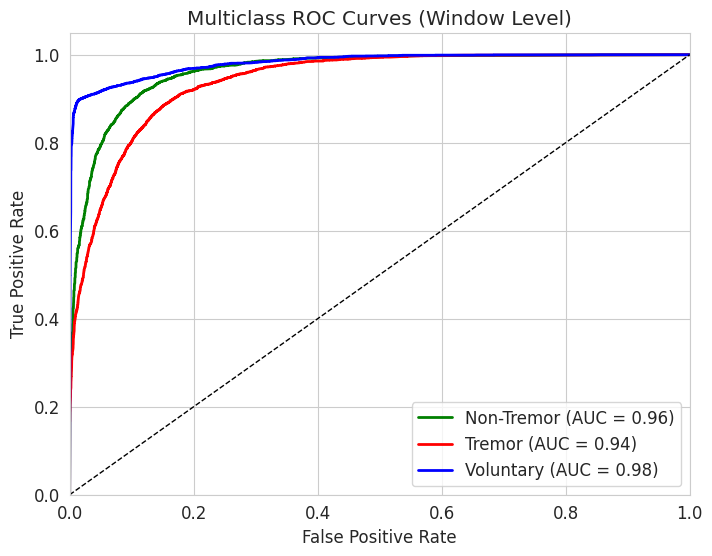

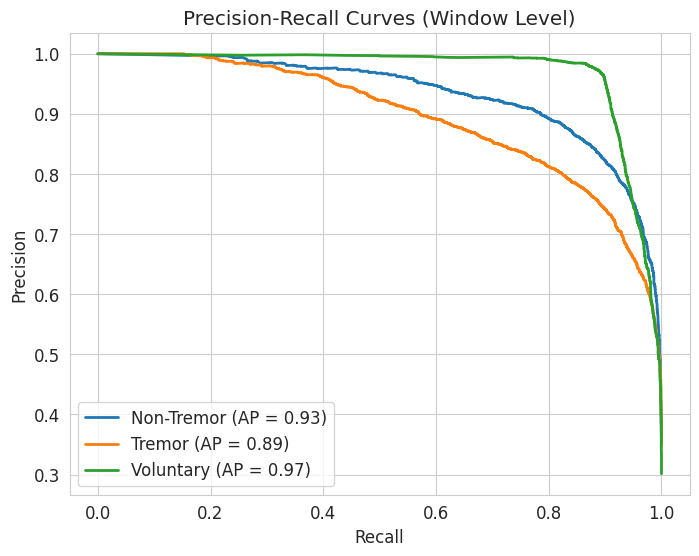


===== Random Forest | WINDOW LEVEL METRICS =====
Accuracy: 0.8603 | Log Loss: 0.3831 | Precision: 0.8674 | Recall: 0.8620 | F1: 0.8636 | FNR: 0.1380

===== Random Forest | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.95      0.96        59
      Tremor       0.91      0.91      0.91        23
   Voluntary       0.97      1.00      0.99        34

    accuracy                           0.96       116
   macro avg       0.95      0.95      0.95       116
weighted avg       0.96      0.96      0.96       116



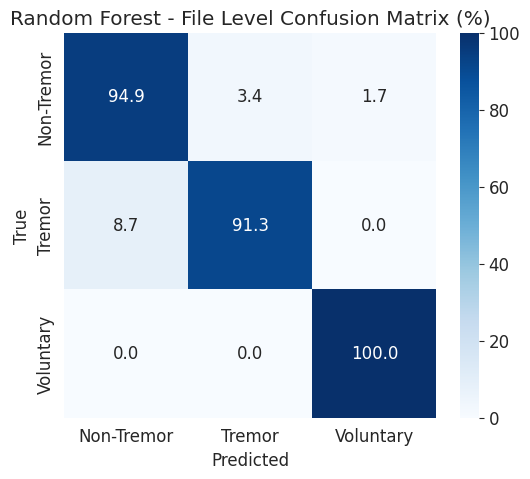

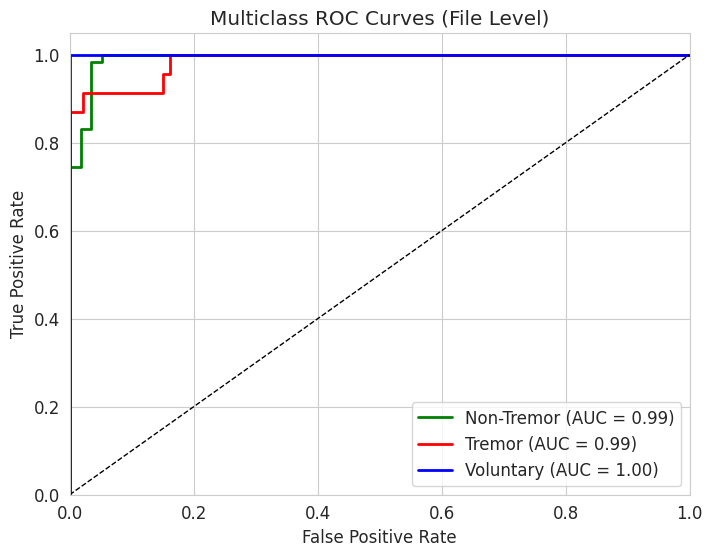

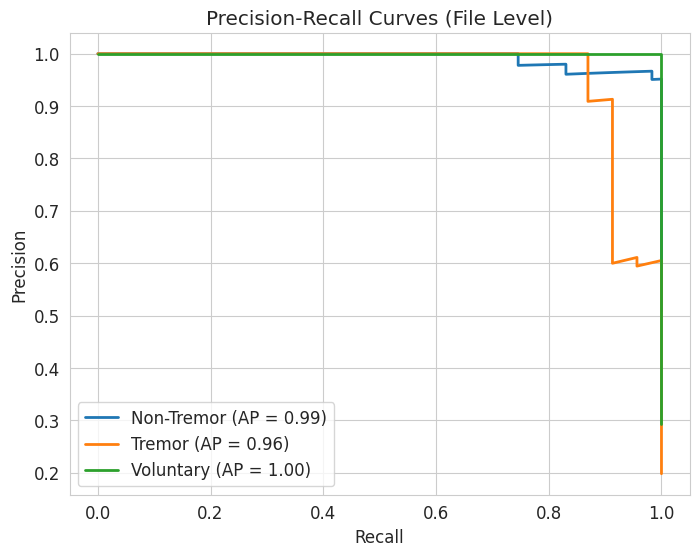


===== Random Forest | FILE LEVEL METRICS =====
Accuracy: 0.9569 | Log Loss: 0.2226 | Precision: 0.9500 | Recall: 0.9541 | F1: 0.9519 | FNR: 0.0459


In [ ]:
# Random Forest

rf_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])
rf_params = {"clf__n_estimators": [100,200,300], "clf__max_depth": [None,10,20]}
best_rf = train_and_evaluate(rf_pipe, rf_params, X, y, groups, "Random Forest")


Fitting 4 folds for each of 8 candidates, totalling 32 fits
Training time for KNN: 14.12 seconds

===== KNN | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.76      0.74      0.75      3712
      Tremor       0.70      0.65      0.67      3688
   Voluntary       0.79      0.87      0.83      3192

    accuracy                           0.75     10592
   macro avg       0.75      0.75      0.75     10592
weighted avg       0.75      0.75      0.75     10592



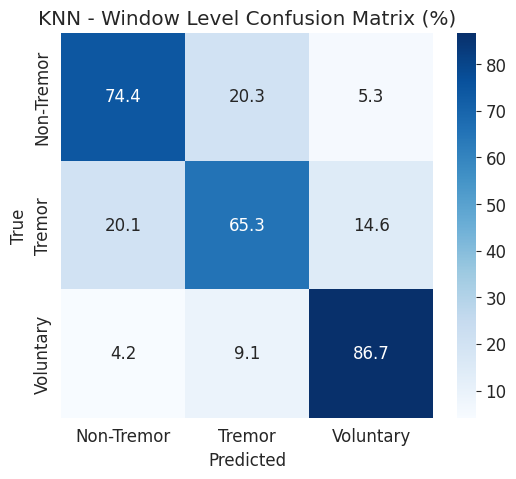

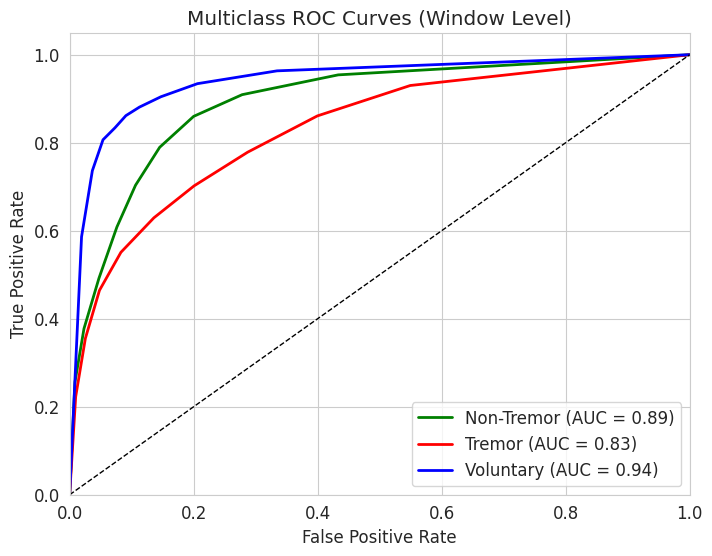

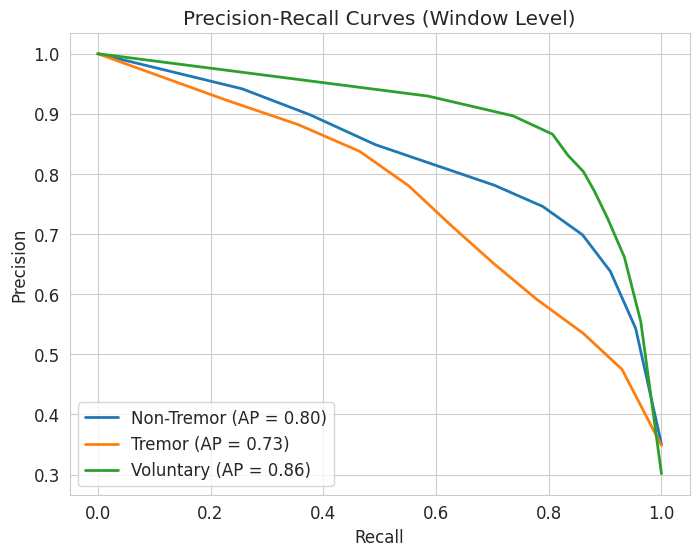


===== KNN | WINDOW LEVEL METRICS =====
Accuracy: 0.7495 | Log Loss: 2.2713 | Precision: 0.7492 | Recall: 0.7548 | F1: 0.7511 | FNR: 0.2452

===== KNN | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.98      0.97      0.97        59
      Tremor       0.90      0.83      0.86        23
   Voluntary       0.92      1.00      0.96        34

    accuracy                           0.95       116
   macro avg       0.94      0.93      0.93       116
weighted avg       0.95      0.95      0.95       116



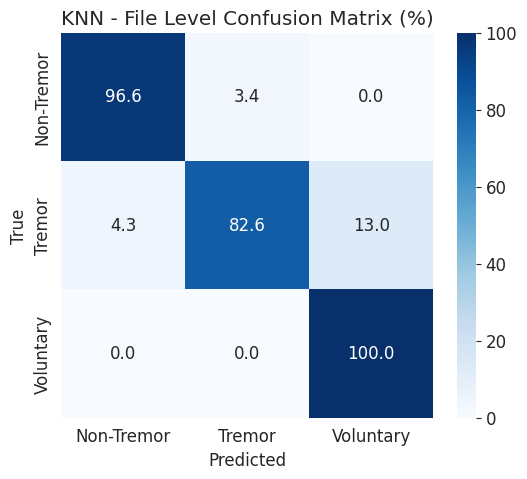

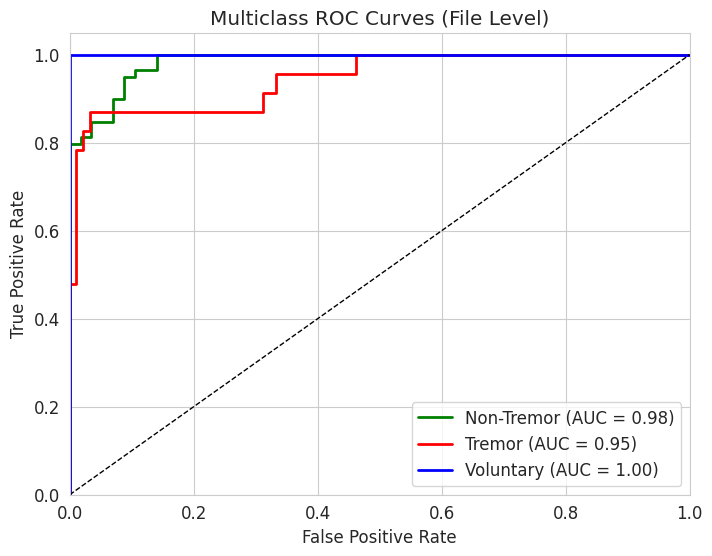

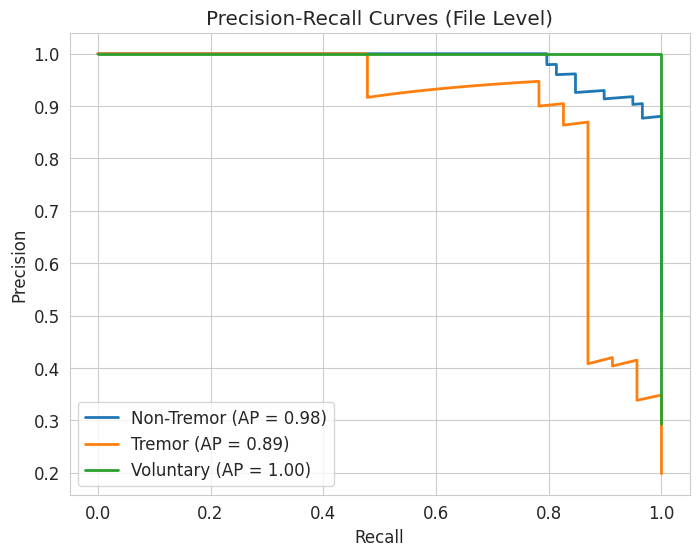


===== KNN | FILE LEVEL METRICS =====
Accuracy: 0.9483 | Log Loss: 0.3746 | Precision: 0.9355 | Recall: 0.9307 | F1: 0.9319 | FNR: 0.0693


In [ ]:
# KNN

knn_pipe = Pipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", KNeighborsClassifier())])
knn_params = {"clf__n_neighbors": [3,5,7,9], "clf__weights": ['uniform','distance']}
best_knn = train_and_evaluate(knn_pipe, knn_params, X, y, groups, "KNN")


Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for Gradient Boosting: 16177.82 seconds

===== Gradient Boosting | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.83      0.90      0.86      3712
      Tremor       0.83      0.80      0.82      3688
   Voluntary       0.96      0.90      0.93      3192

    accuracy                           0.87     10592
   macro avg       0.87      0.87      0.87     10592
weighted avg       0.87      0.87      0.87     10592



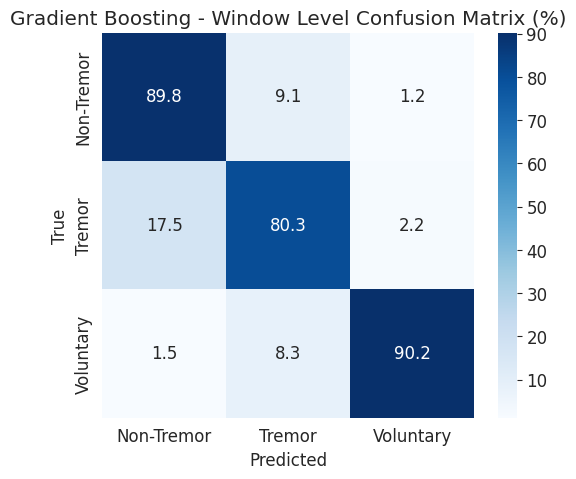

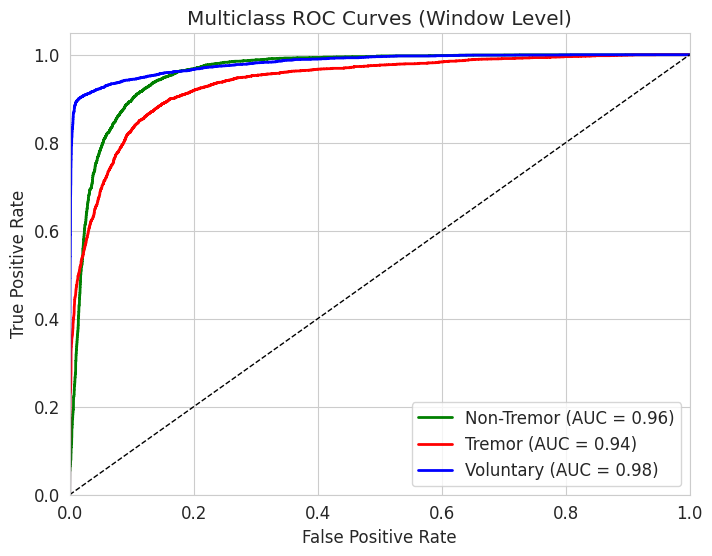

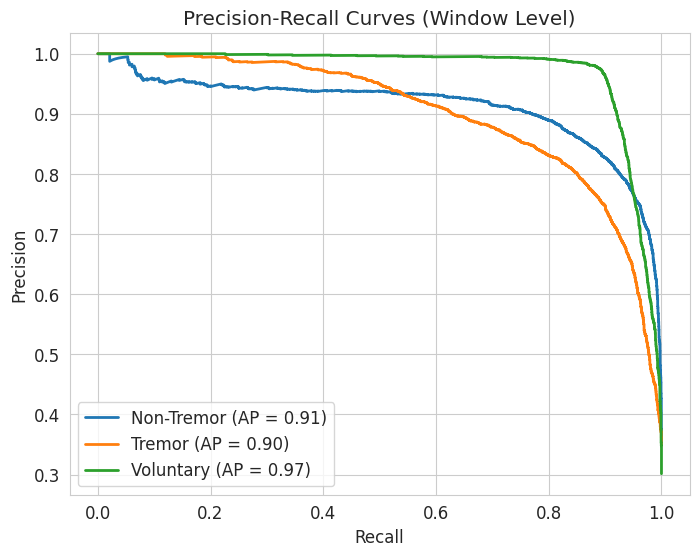


===== Gradient Boosting | WINDOW LEVEL METRICS =====
Accuracy: 0.8660 | Log Loss: 0.5119 | Precision: 0.8725 | Recall: 0.8676 | F1: 0.8692 | FNR: 0.1324

===== Gradient Boosting | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.97      0.97        59
      Tremor       0.95      0.91      0.93        23
   Voluntary       0.97      1.00      0.99        34

    accuracy                           0.97       116
   macro avg       0.96      0.96      0.96       116
weighted avg       0.97      0.97      0.97       116



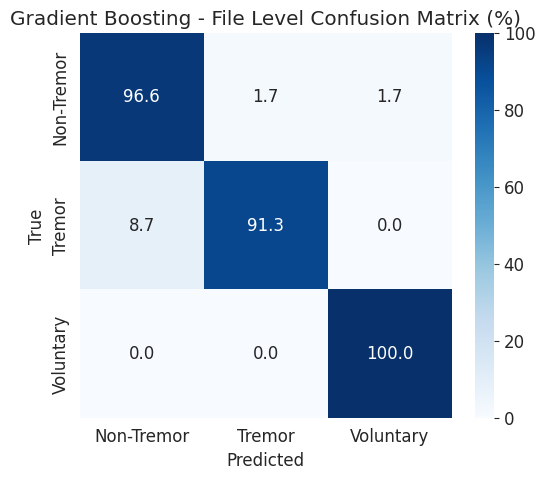

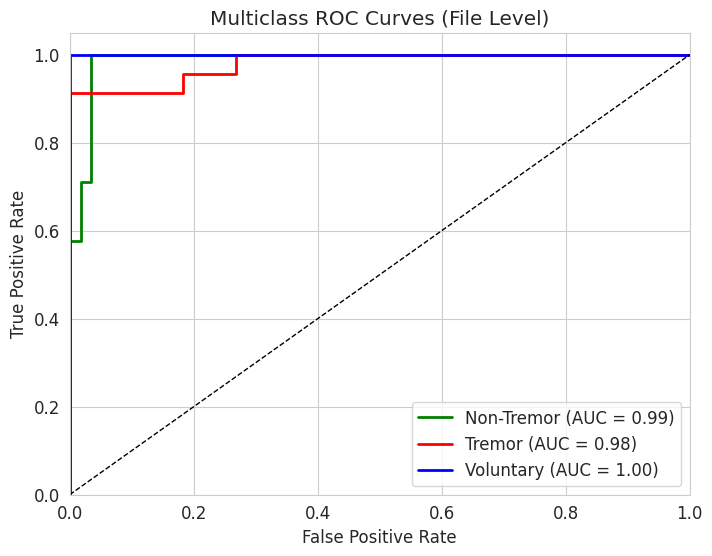

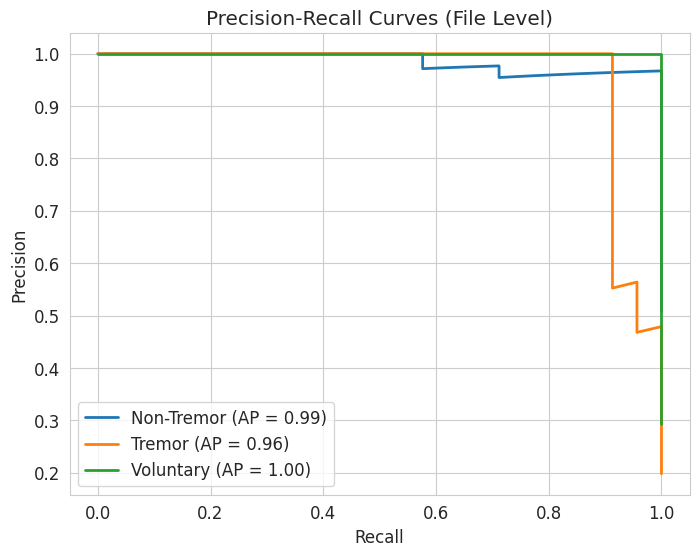


===== Gradient Boosting | FILE LEVEL METRICS =====
Accuracy: 0.9655 | Log Loss: 0.1520 | Precision: 0.9640 | Recall: 0.9597 | F1: 0.9616 | FNR: 0.0403


In [ ]:
# Gradient Boosting

gb_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_params = {"clf__n_estimators": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
             "clf__max_depth": [3,5,7]}
best_gb = train_and_evaluate(gb_pipe, gb_params, X, y, groups, "Gradient Boosting")


# **Accuracy & Loss curve Function for DL Models**

In [ ]:
def train_final_and_plot(model_builder_or_pipeline, X_train, y_train, X_val, y_val, title, level="Window", **kwargs):
    """
    Train final model on train+val and plot curves (train/val loss & accuracy in same figure).
    """
    if title == "MLP":
        def build_keras_mlp(input_dim):
            model = Sequential([
                Input(shape=(input_dim,)),
                Dense(256, activation='relu'),
                BatchNormalization(),
                Dropout(0.3),
                Dense(128, activation='relu'),
                BatchNormalization(),
                Dropout(0.3),
                Dense(64, activation='relu'),
                Dropout(0.2),
                Dense(3, activation='softmax')
            ])
            model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            return model

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = build_keras_mlp(X_train_scaled.shape[1])
        history = model.fit(X_train_scaled, y_train,
                            validation_data=(X_val_scaled, y_val),
                            epochs=100, batch_size=64, verbose=0,
                            callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
        plot_training_history(history, title, level=level)
        return model

    elif title == "LSTM":
        lstm_clf = LSTMClassifier3(units=kwargs['units'], dropout=kwargs['dropout'],
                                   batch_size=kwargs['batch_size'], epochs=kwargs['epochs'],
                                   optimizer=kwargs['optimizer'])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
        X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
        lstm_clf.model_ = lstm_clf.build_model(X_train_reshaped.shape[2])
        history = lstm_clf.model_.fit(X_train_reshaped, y_train,
                                      validation_data=(X_val_reshaped, y_val),
                                      epochs=kwargs['epochs'], batch_size=kwargs['batch_size'],
                                      verbose=0, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
        plot_training_history(history, title, level=level)
        return lstm_clf

    elif title == "TabNet":
        tabnet_model = TabNetClassifier(
            n_d=kwargs['n_d'], n_a=kwargs['n_a'], n_steps=kwargs['n_steps'],
            gamma=kwargs['gamma'], optimizer_params=dict(lr=kwargs['lr']),
            mask_type='entmax', seed=RANDOM_STATE, verbose=0
        )
        X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
        y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
        X_val_np = X_val.values if hasattr(X_val, 'values') else X_val
        y_val_np = y_val.values if hasattr(y_val, 'values') else y_val

        history = tabnet_model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_val_np, y_val_np)],
            max_epochs=kwargs['max_epochs'], patience=kwargs['patience'],
            batch_size=256, virtual_batch_size=128,
            eval_metric=['logloss', 'accuracy']
        )

        plot_training_history(history, title, level=level)
        return tabnet_model


    elif title == "CNN+LSTM":
        input_dim = X_train.shape[1]
        model = build_cnn_lstm_model(input_dim,
                                     conv_filters=kwargs['conv_filters'],
                                     lstm_units=kwargs['lstm_units'],
                                     dropout=kwargs['dropout'])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
        X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
        history = model.fit(X_train_reshaped, y_train,
                            validation_data=(X_val_reshaped, y_val),
                            epochs=kwargs['epochs'], batch_size=kwargs['batch_size'],
                            verbose=0, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
        plot_training_history(history, title, level=level)
        return model

    else:
        return None

# **Deep Learning Models**

Training time for MLP: 46.18 seconds

===== MLP | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.73      0.80      0.76      3712
      Tremor       0.70      0.61      0.65      3688
   Voluntary       0.83      0.85      0.84      3192

    accuracy                           0.75     10592
   macro avg       0.75      0.75      0.75     10592
weighted avg       0.75      0.75      0.75     10592



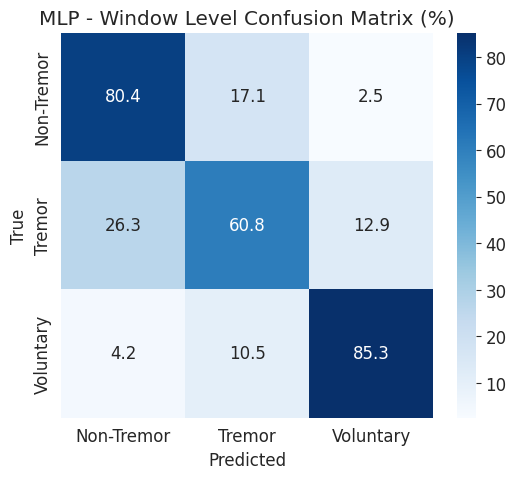

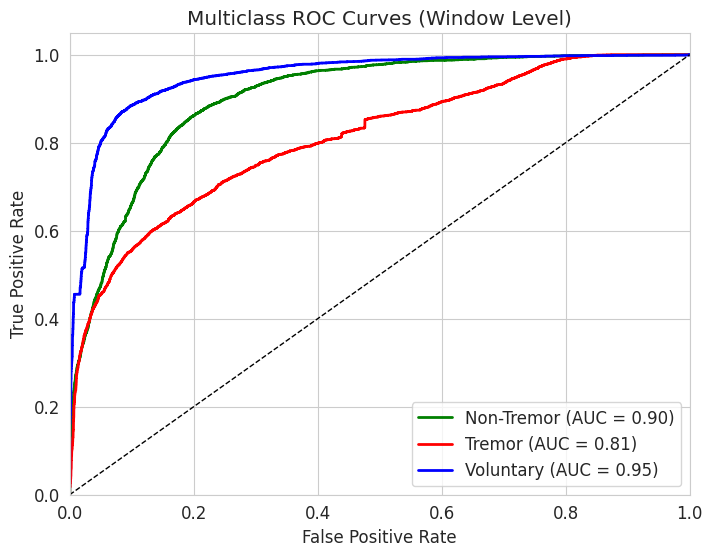

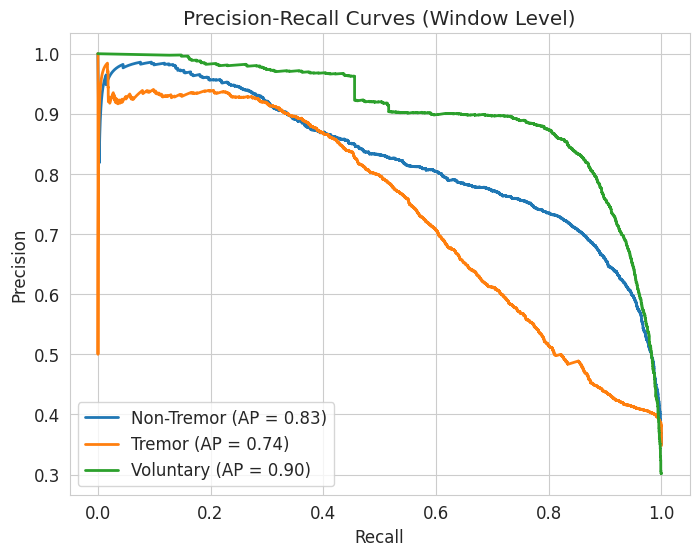


===== MLP | WINDOW LEVEL METRICS =====
Accuracy: 0.7503 | Log Loss: 0.6862 | Precision: 0.7515 | Recall: 0.7548 | F1: 0.7515 | FNR: 0.2452

===== MLP | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.95      0.98      0.97        59
      Tremor       0.94      0.74      0.83        23
   Voluntary       0.92      1.00      0.96        34

    accuracy                           0.94       116
   macro avg       0.94      0.91      0.92       116
weighted avg       0.94      0.94      0.94       116



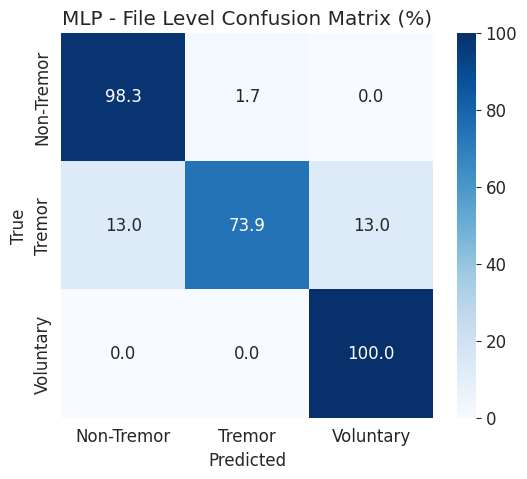

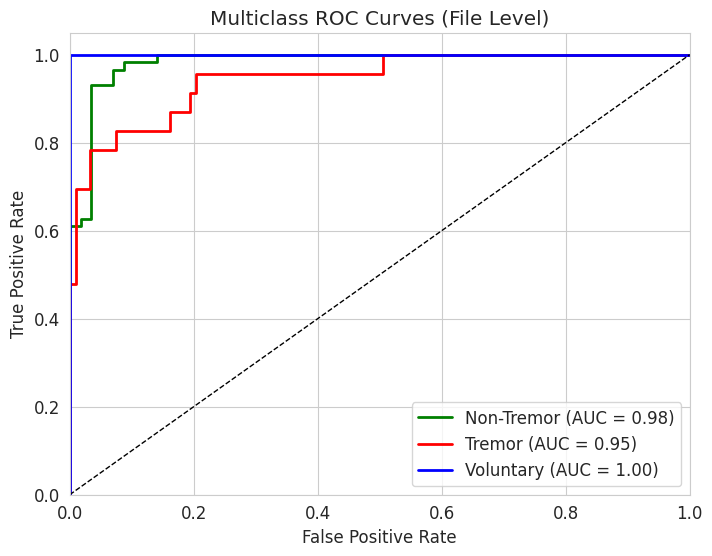

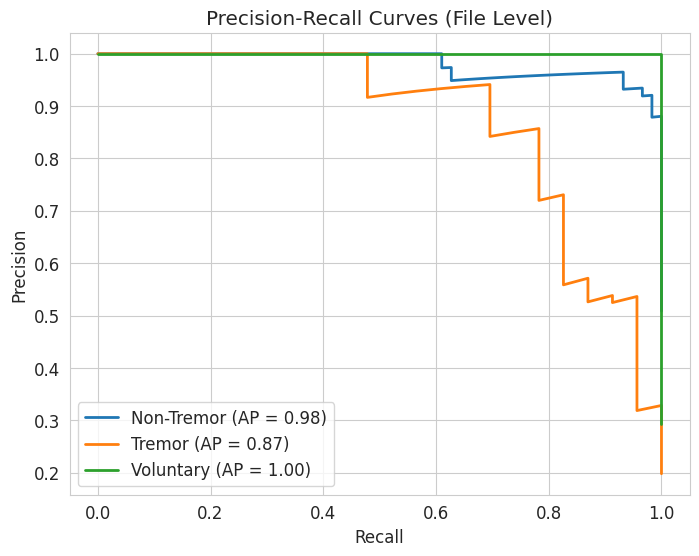


===== MLP | FILE LEVEL METRICS =====
Accuracy: 0.9397 | Log Loss: 0.3479 | Precision: 0.9381 | Recall: 0.9074 | F1: 0.9179 | FNR: 0.0926
Available history keys for MLP: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


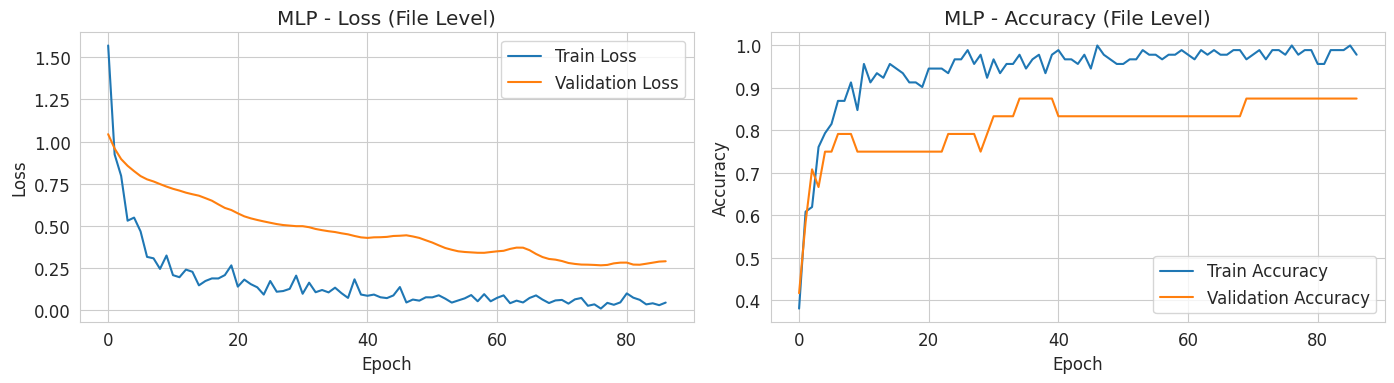

Available history keys for MLP: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


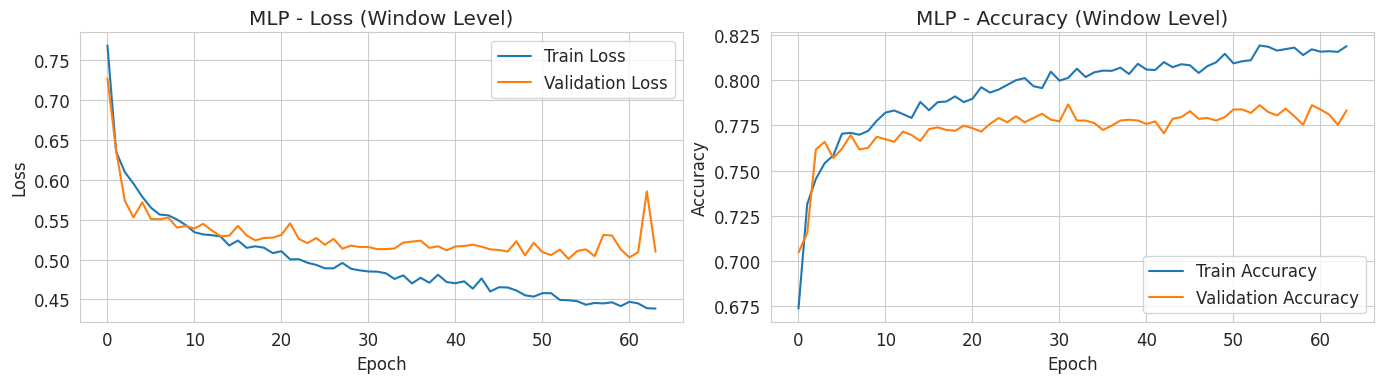

In [ ]:

#MLP
def train_mlp():
    start_time = time.time()
    best_f1 = -1
    best_model = None
    for train_idx, val_idx in cv.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        pipe = Pipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                         ("mlp", MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                                               max_iter=200, early_stopping=True, random_state=RANDOM_STATE))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_model = pipe
    elapsed = time.time() - start_time
    print(f"Training time for MLP: {elapsed:.2f} seconds")
    evaluate_model(best_model, X, y, groups, title="MLP", training_time=elapsed, history=None)
    X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    final_mlp = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final, "MLP")
    return best_model

best_mlp = train_mlp()


Fitting 4 folds for each of 6 candidates, totalling 24 fits
Training time for LSTM: 1212.49 seconds
Available history keys for LSTM: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


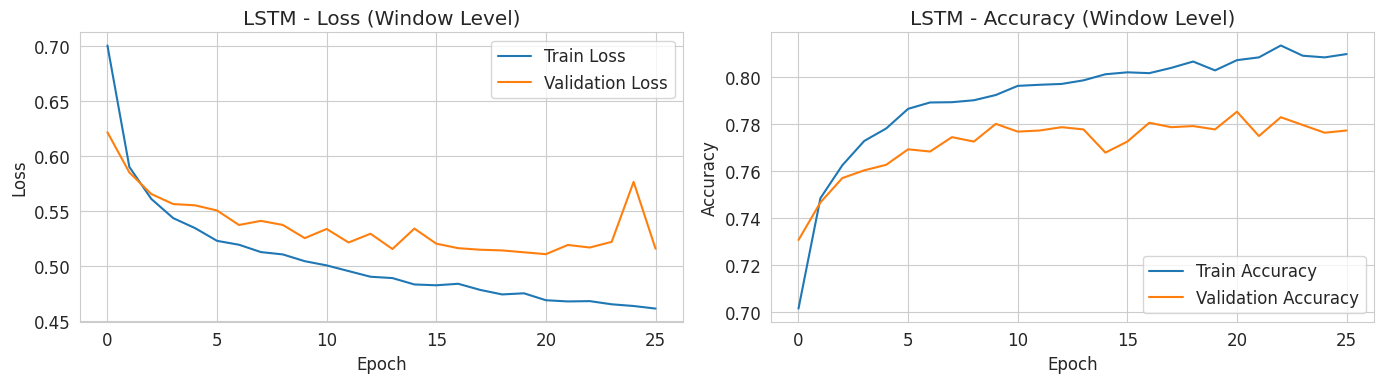


===== LSTM | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.75      0.81      0.78      3712
      Tremor       0.71      0.64      0.67      3688
   Voluntary       0.83      0.86      0.84      3192

    accuracy                           0.77     10592
   macro avg       0.77      0.77      0.77     10592
weighted avg       0.76      0.77      0.76     10592



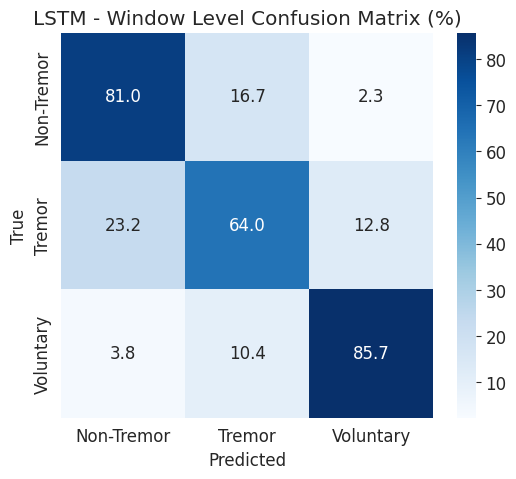

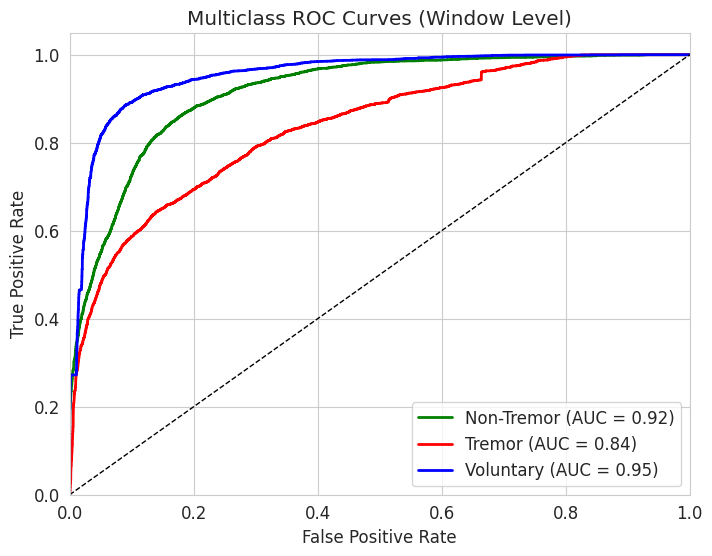

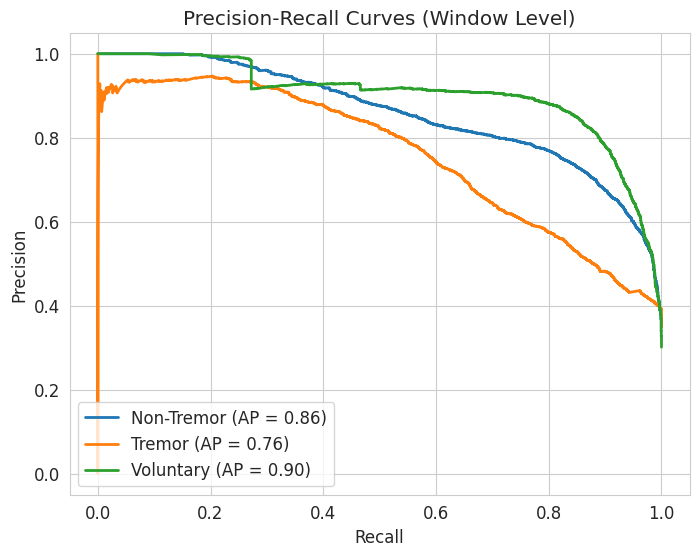


===== LSTM | WINDOW LEVEL METRICS =====
Accuracy: 0.7651 | Log Loss: 0.6079 | Precision: 0.7659 | Recall: 0.7691 | F1: 0.7665 | FNR: 0.2309

===== LSTM | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.98      0.97        59
      Tremor       0.95      0.78      0.86        23
   Voluntary       0.92      1.00      0.96        34

    accuracy                           0.95       116
   macro avg       0.94      0.92      0.93       116
weighted avg       0.95      0.95      0.95       116



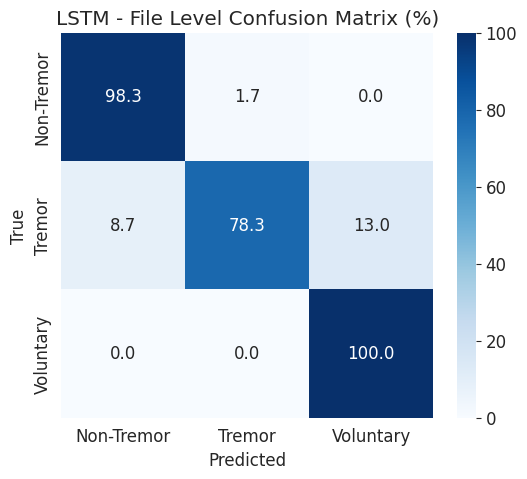

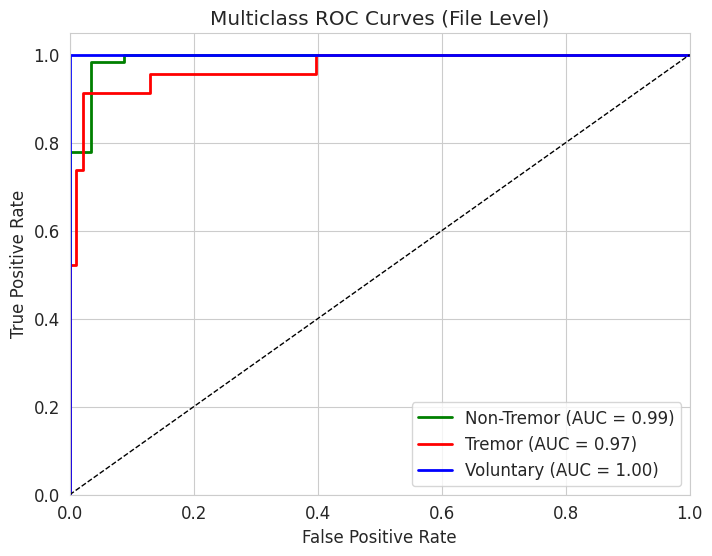

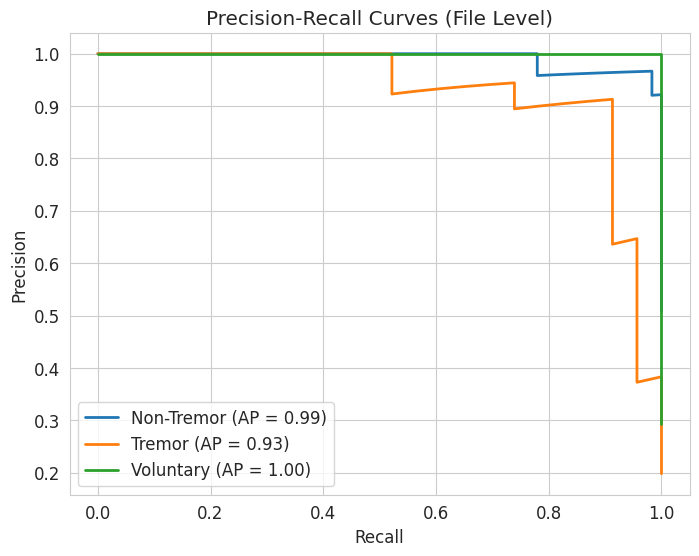


===== LSTM | FILE LEVEL METRICS =====
Accuracy: 0.9483 | Log Loss: 0.3379 | Precision: 0.9443 | Recall: 0.9219 | F1: 0.9299 | FNR: 0.0781
Available history keys for LSTM: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


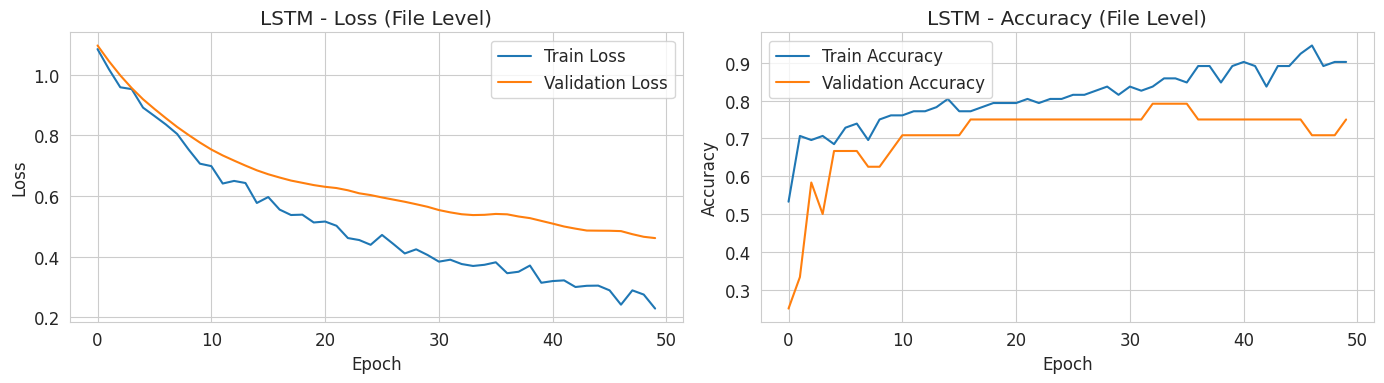

Pipeline(steps=[('clf', LSTMClassifier3(dropout=0.2, units=128))])

In [ ]:
# LSTM
class LSTMClassifier3(BaseEstimator, ClassifierMixin):
    def __init__(self, units=64, dropout=0.3, batch_size=32, epochs=30, optimizer='adam'):
        self.units = units; self.dropout = dropout; self.batch_size = batch_size
        self.epochs = epochs; self.optimizer = optimizer
    def build_model(self, input_dim, n_classes=3):
        model = Sequential([
            Input(shape=(1, input_dim)),
            LSTM(self.units),
            Dropout(self.dropout),
            Dense(self.units//2, activation='relu'),
            Dropout(self.dropout),
            Dense(n_classes, activation='softmax')
        ])
        model.compile(optimizer=self.optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    def fit(self, X, y):
        X = np.array(X).reshape((X.shape[0], 1, X.shape[1]))
        self.model_ = self.build_model(X.shape[2])
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self
    def predict(self, X):
        X = np.array(X).reshape((X.shape[0], 1, X.shape[1]))
        preds = self.model_.predict(X, verbose=0)
        return np.argmax(preds, axis=1)
    def predict_proba(self, X):
        X = np.array(X).reshape((X.shape[0], 1, X.shape[1]))
        return self.model_.predict(X, verbose=0)

X_scaled = StandardScaler().fit_transform(X)
lstm_pipe = Pipeline([("clf", LSTMClassifier3())])
lstm_params = {"clf__units": [64,128], "clf__dropout": [0.2,0.3], "clf__batch_size": [16,32], "clf__epochs": [20,30]}
lstm_search = RandomizedSearchCV(lstm_pipe, lstm_params, n_iter=6, scoring='f1_macro',
                                  cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1)
start_time = time.time()
lstm_search.fit(X_scaled, y, groups=groups)

elapsed = time.time() - start_time
print(f"Training time for LSTM: {elapsed:.2f} seconds")

best_lstm = lstm_search.best_estimator_
best_params_lstm = lstm_search.best_params_

lstm_final_params = {
    'units': best_params_lstm.get('clf__units', 64),
    'dropout': best_params_lstm.get('clf__dropout', 0.3),
    'batch_size': best_params_lstm.get('clf__batch_size', 32),
    'epochs': best_params_lstm.get('clf__epochs', 30),
    'optimizer': best_params_lstm.get('clf__optimizer', 'adam')
}

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_lstm = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final, "LSTM",
                                  units=lstm_final_params['units'],
                                  dropout=lstm_final_params['dropout'],
                                  batch_size=lstm_final_params['batch_size'],
                                  epochs=lstm_final_params['epochs'],
                                  optimizer=lstm_final_params['optimizer'])

evaluate_model(best_lstm, X_scaled, y, groups, title="LSTM", training_time=elapsed)

Fitting 4 folds for each of 4 candidates, totalling 16 fits
Training time for TabNet: 1767.40 seconds

Training final TabNet model for plotting loss/accuracy curves...

Early stopping occurred at epoch 24 with best_epoch = 14 and best_val_0_accuracy = 0.77961
History keys: ['loss', 'lr', 'val_0_logloss', 'val_0_accuracy', 'train_accuracy']
Available history keys for TabNet Final: ['loss', 'lr', 'val_0_logloss', 'val_0_accuracy', 'train_accuracy']


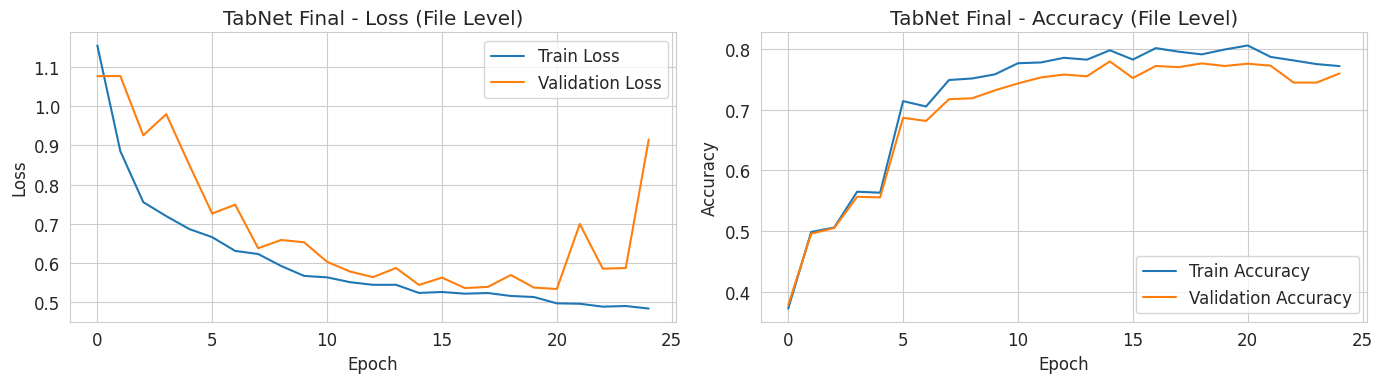


===== TabNet | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.77      0.76      0.76      3712
      Tremor       0.64      0.65      0.65      3688
   Voluntary       0.80      0.81      0.80      3192

    accuracy                           0.73     10592
   macro avg       0.74      0.74      0.74     10592
weighted avg       0.73      0.73      0.73     10592



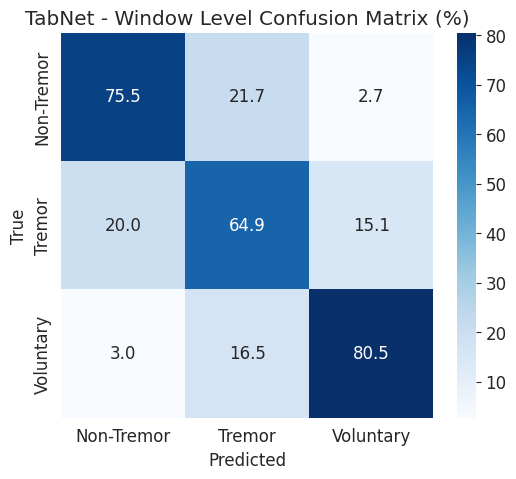

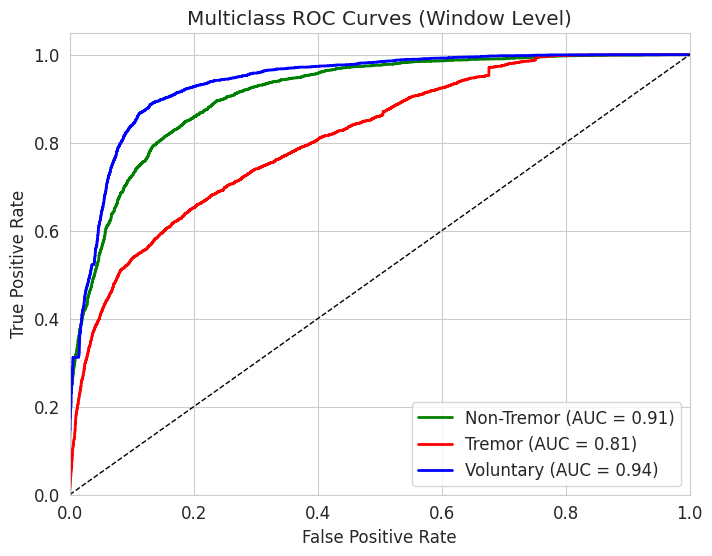

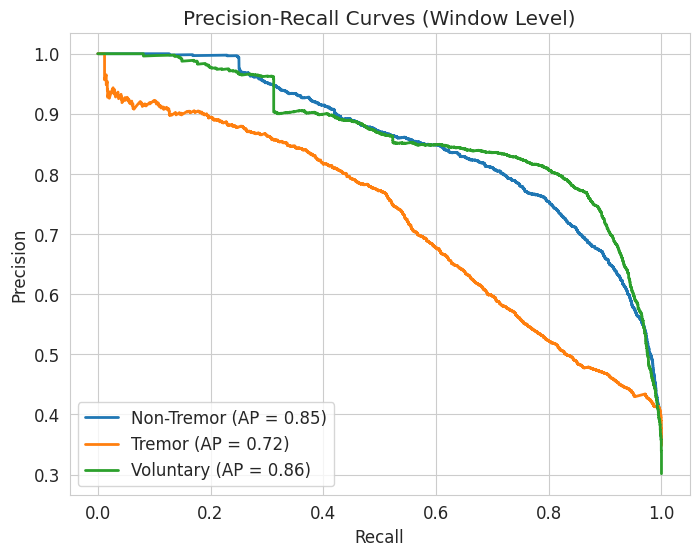


===== TabNet | WINDOW LEVEL METRICS =====
Accuracy: 0.7332 | Log Loss: 0.6425 | Precision: 0.7363 | Recall: 0.7364 | F1: 0.7363 | FNR: 0.2636

===== TabNet | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.88      0.92        59
      Tremor       0.71      0.74      0.72        23
   Voluntary       0.89      1.00      0.94        34

    accuracy                           0.89       116
   macro avg       0.86      0.87      0.86       116
weighted avg       0.89      0.89      0.89       116



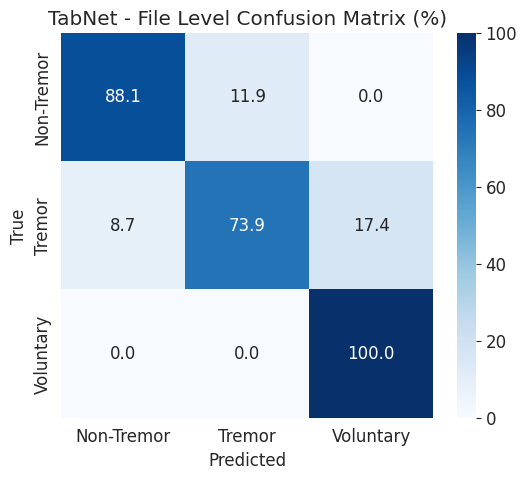

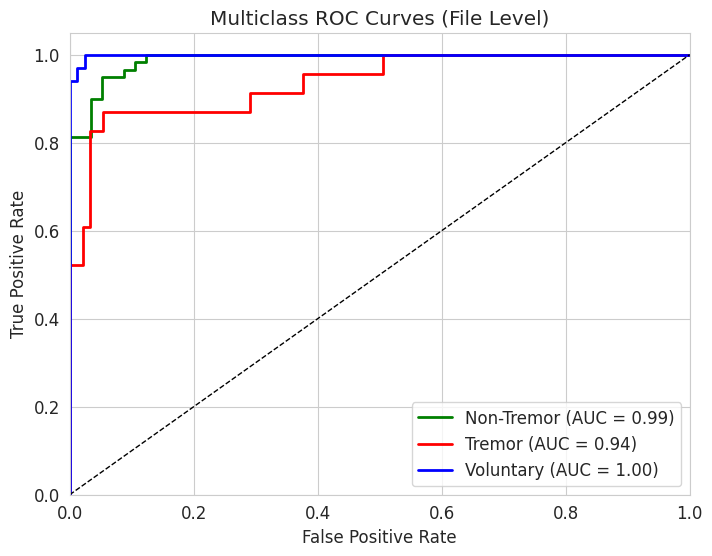

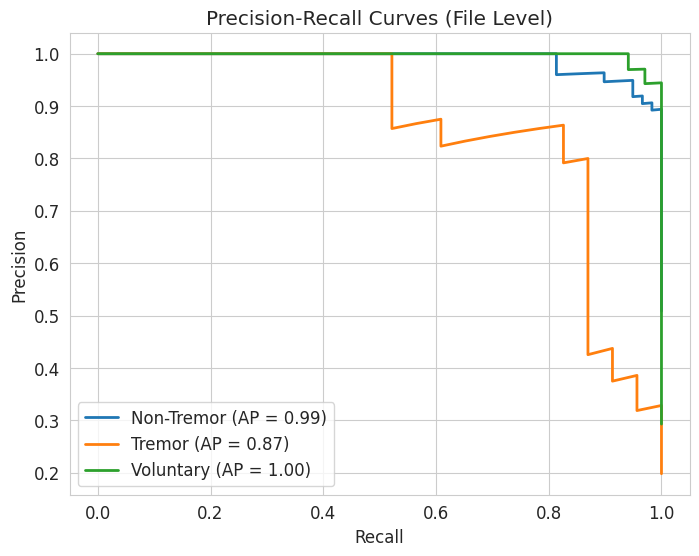


===== TabNet | FILE LEVEL METRICS =====
Accuracy: 0.8879 | Log Loss: 0.3927 | Precision: 0.8553 | Recall: 0.8735 | F1: 0.8627 | FNR: 0.1265
File-level training for TabNet completed (no history plot available for TabNet/MLP).


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf', TabNetWrapper3(lr=0.01))])

In [ ]:
# ====================== TabNet ======================
from pytorch_tabnet.callbacks import Callback

class TabNetWrapper3(BaseEstimator, ClassifierMixin):
    def __init__(self, n_d=8, n_a=8, n_steps=3, gamma=1.3, lr=0.02, max_epochs=50, patience=10, seed=42):
        self.n_d = n_d
        self.n_a = n_a
        self.n_steps = n_steps
        self.gamma = gamma
        self.lr = lr
        self.max_epochs = max_epochs
        self.patience = patience
        self.seed = seed

    def fit(self, X, y):
        X_ = X.values if hasattr(X, 'values') else X
        y_ = y.values if hasattr(y, 'values') else y

        class TrainAccuracyCallback(Callback):
            def __init__(self, model, X_train, y_train):
                self.model = model
                self.X_train = X_train
                self.y_train = y_train
                self.train_accuracy = []

            def on_epoch_end(self, epoch, logs=None):
                y_pred = self.model.predict(self.X_train)
                acc = accuracy_score(self.y_train, y_pred)
                self.train_accuracy.append(acc)

        self.model_ = TabNetClassifier(
            n_d=self.n_d, n_a=self.n_a, n_steps=self.n_steps,
            gamma=self.gamma, optimizer_params=dict(lr=self.lr),
            seed=self.seed, verbose=0
        )

        callback = TrainAccuracyCallback(self.model_, X_, y_)
        self.model_.fit(
            X_, y_,
            max_epochs=self.max_epochs,
            patience=self.patience,
            batch_size=256,
            callbacks=[callback]
        )
        return self

    def predict(self, X):
        return self.model_.predict(X.values if hasattr(X, 'values') else X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X.values if hasattr(X, 'values') else X)


tabnet_pipe = Pipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", TabNetWrapper3(seed=RANDOM_STATE))
])

tabnet_params = {
    "clf__n_d": [8, 16],
    "clf__n_steps": [3, 5],
    "clf__lr": [0.01, 0.02]
}

tabnet_search = RandomizedSearchCV(
    tabnet_pipe, tabnet_params,
    n_iter=4,
    scoring='f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1
)

start_time = time.time()
tabnet_search.fit(X, y, groups=groups)
elapsed = time.time() - start_time
print(f"Training time for TabNet: {elapsed:.2f} seconds")

best_tabnet = tabnet_search.best_estimator_
best_params_tabnet = tabnet_search.best_params_

tabnet_final_params = {
    'n_d': best_params_tabnet.get('clf__n_d', 8),
    'n_a': best_params_tabnet.get('clf__n_a', 8),
    'n_steps': best_params_tabnet.get('clf__n_steps', 3),
    'gamma': best_params_tabnet.get('clf__gamma', 1.3),
    'lr': best_params_tabnet.get('clf__lr', 0.02)
}

print("\nTraining final TabNet model for plotting loss/accuracy curves...")
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train_np = X_train_final.values if hasattr(X_train_final, 'values') else X_train_final
X_val_np = X_val_final.values if hasattr(X_val_final, 'values') else X_val_final
y_train_np = y_train_final.values if hasattr(y_train_final, 'values') else y_train_final
y_val_np = y_val_final.values if hasattr(y_val_final, 'values') else y_val_final

final_tabnet = TabNetClassifier(
    n_d=tabnet_final_params['n_d'],
    n_a=tabnet_final_params['n_a'],
    n_steps=tabnet_final_params['n_steps'],
    gamma=tabnet_final_params['gamma'],
    optimizer_params=dict(lr=tabnet_final_params['lr']),
    mask_type='entmax',
    seed=RANDOM_STATE,
    verbose=0
)

class TrainAccuracyCallback(Callback):
    def __init__(self, model, X_train, y_train):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.train_accuracy = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_train)
        acc = accuracy_score(self.y_train, y_pred)
        self.train_accuracy.append(acc)

callback = TrainAccuracyCallback(final_tabnet, X_train_np, y_train_np)

final_tabnet.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    max_epochs=50,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
    eval_metric=['logloss', 'accuracy'],
    callbacks=[callback]
)

# استخراج history معالجة بشكل آمن
history = None
if hasattr(final_tabnet, 'history_') and final_tabnet.history_:
    # history_ is a dict, we can modify it directly
    history = final_tabnet.history_
    history['train_accuracy'] = callback.train_accuracy
elif hasattr(final_tabnet, 'history'):
    # history might be a History object, extract dictionary
    hist_obj = final_tabnet.history
    if hasattr(hist_obj, 'history') and isinstance(hist_obj.history, dict):
        history = dict(hist_obj.history)  # copy to new dict
    elif isinstance(hist_obj, dict):
        history = dict(hist_obj)
    else:
        # try to convert to dict by iterating
        try:
            history = {k: v for k, v in hist_obj.items() if not callable(v)}
        except:
            history = {}
    if history:
        history['train_accuracy'] = callback.train_accuracy

if history:
    print("History keys:", list(history.keys()))
    plot_training_history(history, "TabNet Final", level="File")
else:
    print("No history found. Cannot plot.")

evaluate_model(best_tabnet, X, y, groups, title="TabNet", training_time=elapsed)

Best CNN+LSTM F1: 0.763350988859524 Params: {'conv_filters': 128, 'lstm_units': 128, 'dropout': 0.3}
Training final CNN+LSTM model and plotting curves...
Available history keys for CNN+LSTM: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


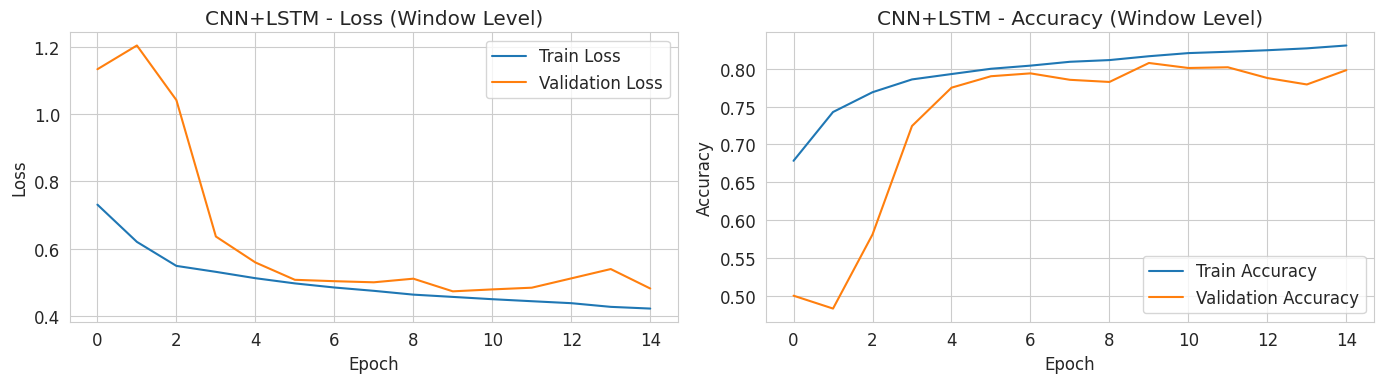

Training time for CNN+LSTM: 4617.00 seconds

===== CNN+LSTM | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.77      0.79      0.78      3712
      Tremor       0.70      0.68      0.69      3688
   Voluntary       0.86      0.84      0.85      3192

    accuracy                           0.77     10592
   macro avg       0.77      0.77      0.77     10592
weighted avg       0.77      0.77      0.77     10592



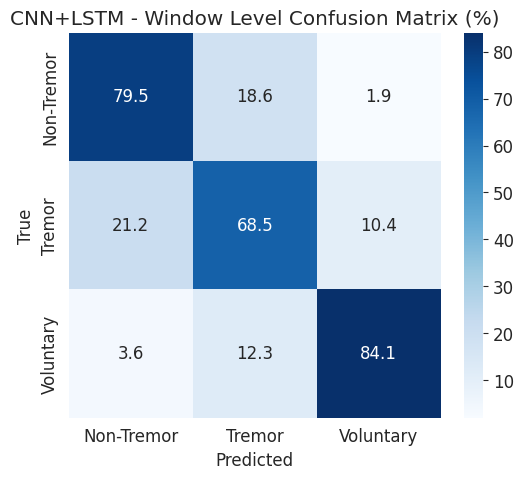

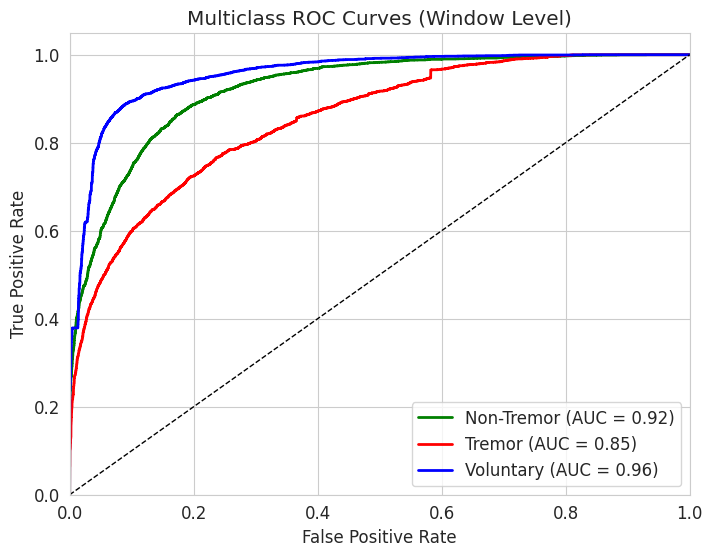

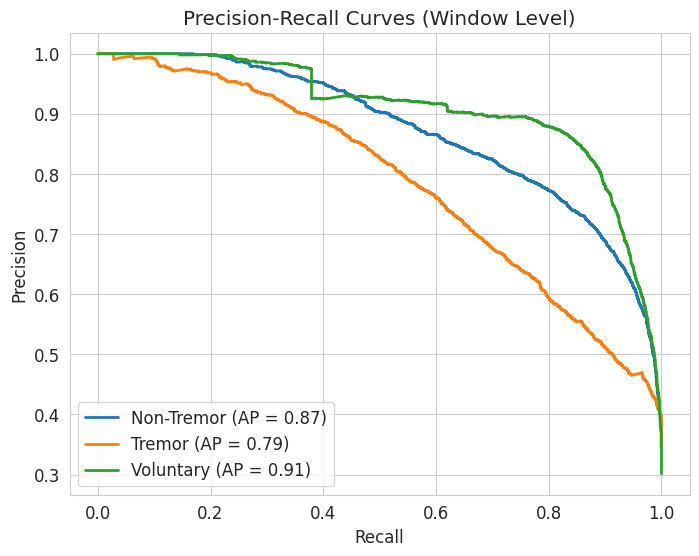


===== CNN+LSTM | WINDOW LEVEL METRICS =====
Accuracy: 0.7704 | Log Loss: 0.5731 | Precision: 0.7741 | Recall: 0.7735 | F1: 0.7737 | FNR: 0.2265

===== CNN+LSTM | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.92      0.94        59
      Tremor       0.80      0.87      0.83        23
   Voluntary       0.97      1.00      0.99        34

    accuracy                           0.93       116
   macro avg       0.91      0.93      0.92       116
weighted avg       0.93      0.93      0.93       116



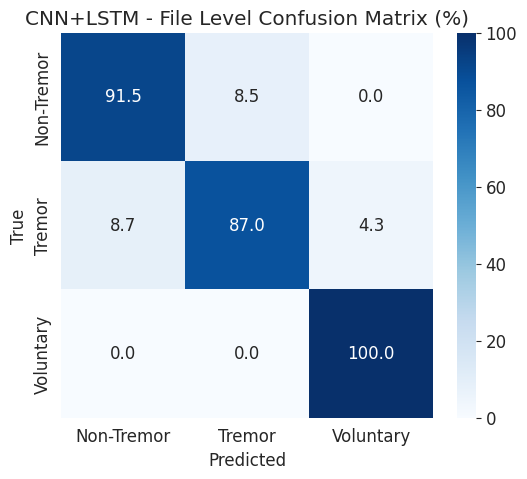

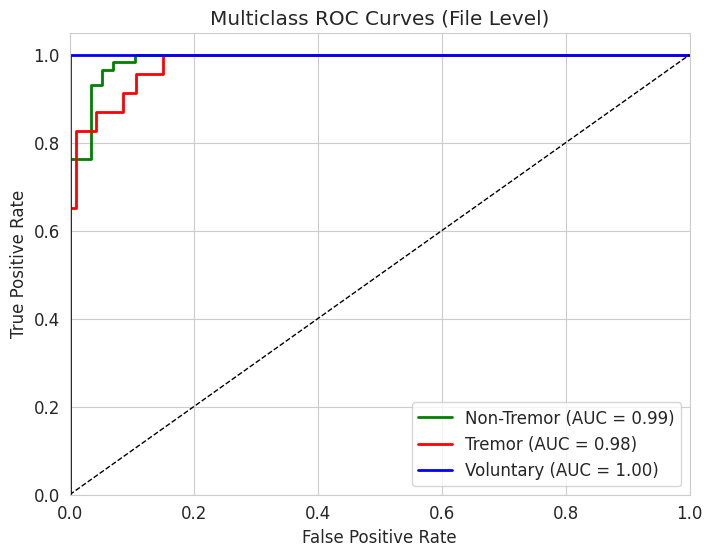

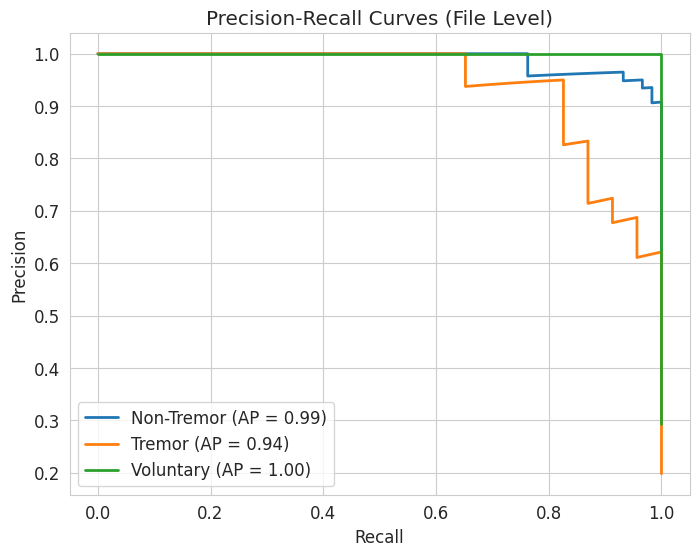


===== CNN+LSTM | FILE LEVEL METRICS =====
Accuracy: 0.9310 | Log Loss: 0.3257 | Precision: 0.9119 | Recall: 0.9283 | F1: 0.9193 | FNR: 0.0717
Available history keys for CNN+LSTM: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


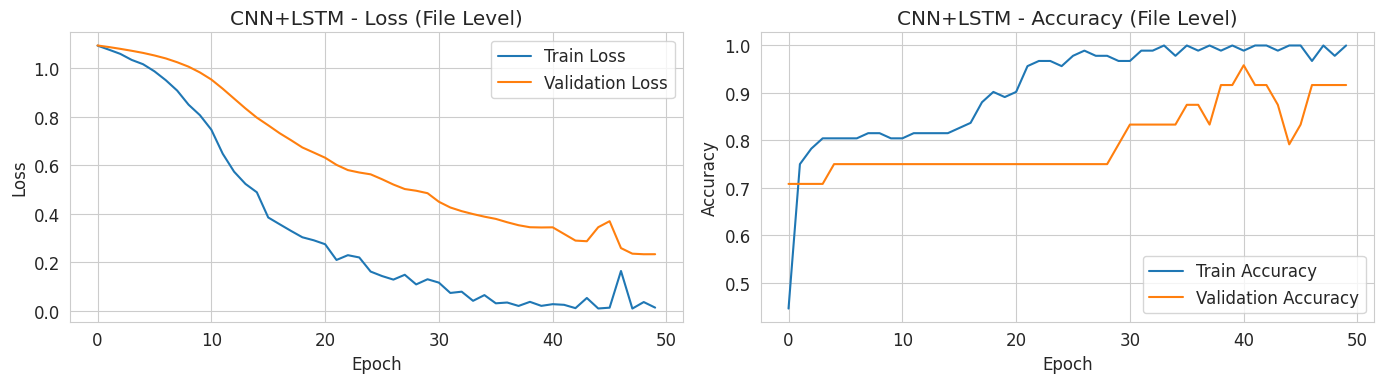

In [ ]:
# CNN + LSTM

def build_cnn_lstm_model(input_dim, conv_filters=128, lstm_units=128, dropout=0.3):
    model = Sequential([
        Conv1D(conv_filters, 3, activation="relu", padding="same", input_shape=(input_dim, 1)),
        BatchNormalization(),
        Conv1D(conv_filters//2, 3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(2, padding='same'),   # <-- أضف padding='same'
        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout),
        LSTM(lstm_units//2),
        Dropout(dropout),
        Dense(64, activation="relu"),
        Dense(3, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Hyperparameter grid (same as original, but adapted)
param_grid = [
    {"conv_filters": 64, "lstm_units": 64, "dropout": 0.2},
    {"conv_filters": 128, "lstm_units": 64, "dropout": 0.3},
    {"conv_filters": 128, "lstm_units": 128, "dropout": 0.3},
]

best_f1 = 0
best_model_cnn_lstm = None
best_params_cnn_lstm = None

start_time = time.time()

for params in param_grid:
    fold_f1s = []
    for train_idx, test_idx in cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
        model = build_cnn_lstm_model(X_train.shape[1],
                                     conv_filters=params["conv_filters"],
                                     lstm_units=params["lstm_units"],
                                     dropout=params["dropout"])
        model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0, validation_data=(X_test, y_test))
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        fold_f1s.append(f1_score(y_test, y_pred, average='macro'))
    mean_f1 = np.mean(fold_f1s)
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_model_cnn_lstm = model
        best_params_cnn_lstm = params

print("Best CNN+LSTM F1:", best_f1, "Params:", best_params_cnn_lstm)

print("Training final CNN+LSTM model and plotting curves...")
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_cnn_lstm = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final,
                                      "CNN+LSTM",
                                      conv_filters=best_params_cnn_lstm["conv_filters"],
                                      lstm_units=best_params_cnn_lstm["lstm_units"],
                                      dropout=best_params_cnn_lstm["dropout"],
                                      epochs=20, batch_size=64)

elapsed = time.time() - start_time
print(f"Training time for CNN+LSTM: {elapsed:.2f} seconds")
evaluate_cnn_lstm_model(build_cnn_lstm_model, best_params_cnn_lstm, X, y, groups, title="CNN+LSTM", training_time=elapsed)


# **Model Comparison**


STARTING MODEL COMPARISON (3-CLASS)

Evaluating LightGBM...
  → Acc: 0.9094 ± 0.0216 | Macro F1: 0.9066 ± 0.0249

Evaluating CatBoost...
  → Acc: 0.8960 ± 0.0235 | Macro F1: 0.8930 ± 0.0243

Evaluating XGBoost...
  → Acc: 0.9048 ± 0.0216 | Macro F1: 0.9021 ± 0.0245

Evaluating Gradient Boosting...
  → Acc: 0.9043 ± 0.0247 | Macro F1: 0.9017 ± 0.0272

Evaluating Random Forest...
  → Acc: 0.8923 ± 0.0314 | Macro F1: 0.8904 ± 0.0316

Evaluating SVM (RBF)...
  → Acc: 0.7655 ± 0.0397 | Macro F1: 0.7574 ± 0.0399

Evaluating KNN...
  → Acc: 0.7551 ± 0.0490 | Macro F1: 0.7512 ± 0.0436

Evaluating MLP...
  → Acc: 0.7485 ± 0.0380 | Macro F1: 0.7423 ± 0.0385

Evaluating LSTM...
  → Acc: 0.8635 ± 0.0231 | Macro F1: 0.8619 ± 0.0243

Evaluating TabNet...
  → Acc: 0.7034 ± 0.0861 | Macro F1: 0.6836 ± 0.1034

Evaluating CNN+LSTM...
  → Acc: 0.7877 ± 0.0279 | Macro F1: 0.7797 ± 0.0334

FINAL MODEL COMPARISON RESULTS
                Model  Avg Accuracy  Std Accuracy  Avg Macro F1  Std Macro F1
0       

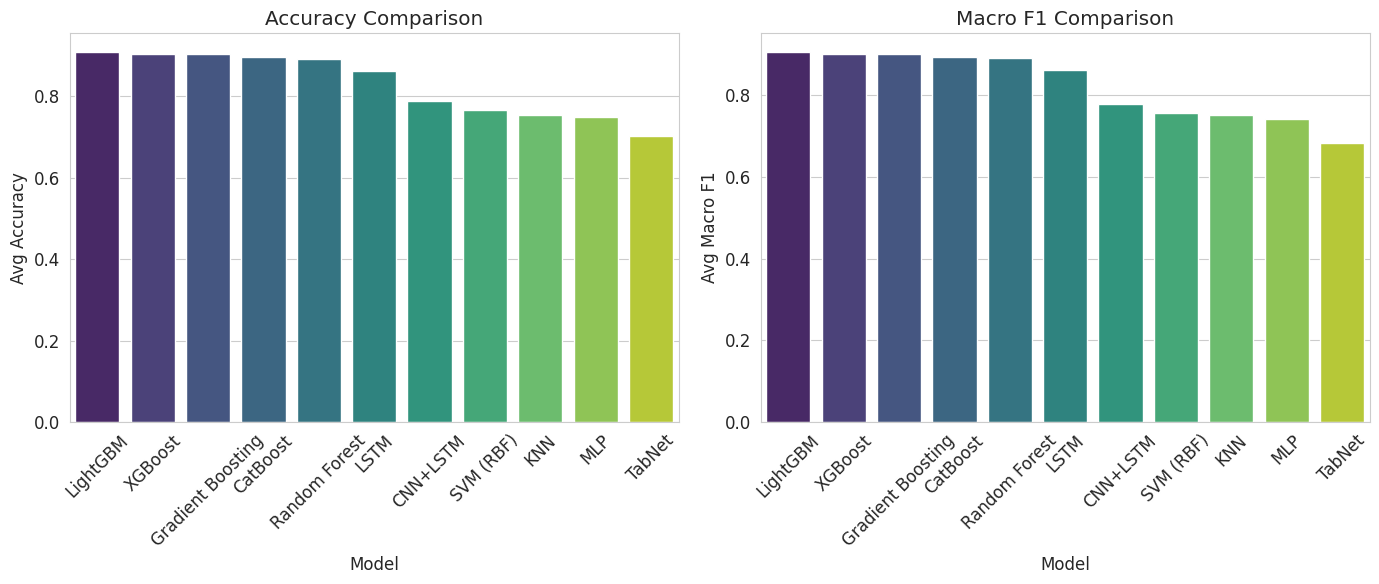

Comparison results saved to 'model_comparison.csv'


In [ ]:

# ====================== MODEL COMPARISON ======================
print("\n" + "="*80)
print("STARTING MODEL COMPARISON (3-CLASS)")
print("="*80)

# ---- 1. Collect sklearn-compatible models ----
models_to_compare = {
    "LightGBM": best_lgb,
    "CatBoost": best_cat,
    "XGBoost": best_xgb,
    "Gradient Boosting": best_gb,
    "Random Forest": best_rf,
    "SVM (RBF)": best_svm,
    "KNN": best_knn,
    "MLP": best_mlp,
    "LSTM": best_lstm,
    "TabNet": best_tabnet
}

# Use GroupKFold with 5 splits for comparison
gkf_compare = GroupKFold(n_splits=5)
comparison_results = []

# ---- 2. Evaluate sklearn models ----
for name, model in models_to_compare.items():
    print(f"\nEvaluating {name}...")
    accuracies = []
    f1_macros = []
    try:
        for train_idx, test_idx in gkf_compare.split(X, y, groups):
            X_train = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
            X_test = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]
            y_train = y[train_idx]
            y_test = y[test_idx]
            model_copy = clone_model(model)
            model_copy.fit(X_train, y_train)
            y_pred = model_copy.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            accuracies.append(acc)
            f1_macros.append(f1)
        comparison_results.append({
            "Model": name,
            "Avg Accuracy": np.mean(accuracies),
            "Std Accuracy": np.std(accuracies),
            "Avg Macro F1": np.mean(f1_macros),
            "Std Macro F1": np.std(f1_macros)
        })
        print(f"  → Acc: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f} | Macro F1: {np.mean(f1_macros):.4f} ± {np.std(f1_macros):.4f}")
    except Exception as e:
        print(f"  → Error evaluating {name}: {e}")

# ---- 3. Evaluate CNN+LSTM separately (since it's not a sklearn pipeline) ----
print("\nEvaluating CNN+LSTM...")
cnn_accuracies = []
cnn_f1_macros = []
try:
    for train_idx, test_idx in gkf_compare.split(X, y, groups):
        X_train = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
        X_test = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        # Scale and reshape
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
        X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

        # Build fresh model using best params found earlier
        model = build_cnn_lstm_model(
            input_dim=X_train_scaled.shape[1],
            conv_filters=best_params_cnn_lstm["conv_filters"],
            lstm_units=best_params_cnn_lstm["lstm_units"],
            dropout=best_params_cnn_lstm["dropout"]
        )
        model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, verbose=0)
        y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        cnn_accuracies.append(acc)
        cnn_f1_macros.append(f1)

    comparison_results.append({
        "Model": "CNN+LSTM",
        "Avg Accuracy": np.mean(cnn_accuracies),
        "Std Accuracy": np.std(cnn_accuracies),
        "Avg Macro F1": np.mean(cnn_f1_macros),
        "Std Macro F1": np.std(cnn_f1_macros)
    })
    print(f"  → Acc: {np.mean(cnn_accuracies):.4f} ± {np.std(cnn_accuracies):.4f} | Macro F1: {np.mean(cnn_f1_macros):.4f} ± {np.std(cnn_f1_macros):.4f}")
except Exception as e:
    print(f"  → Error evaluating CNN+LSTM: {e}")

# ---- 4. Combine and display results ----
comparison_df = pd.DataFrame(comparison_results).sort_values(by="Avg Macro F1", ascending=False).reset_index(drop=True)
print("\n" + "="*80)
print("FINAL MODEL COMPARISON RESULTS")
print("="*80)
print(comparison_df.round(4))

# ---- 5. Plot comparison ----
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.barplot(data=comparison_df, x="Model", y="Avg Accuracy", palette="viridis")
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.subplot(1,2,2)
sns.barplot(data=comparison_df, x="Model", y="Avg Macro F1", palette="viridis")
plt.xticks(rotation=45)
plt.title("Macro F1 Comparison")
plt.tight_layout()
plt.show()

# Save results
comparison_df.to_csv("model_comparison.csv", index=False)
print("Comparison results saved to 'model_comparison.csv'")


In [ ]:

# ====================== FINAL METRICS TABLE ======================
print("\n" + "="*80)
print("FINAL COMPARISON TABLE (All Models)")
print("="*80)

metrics_df = pd.DataFrame(all_models_metrics).T



FINAL COMPARISON TABLE (All Models)


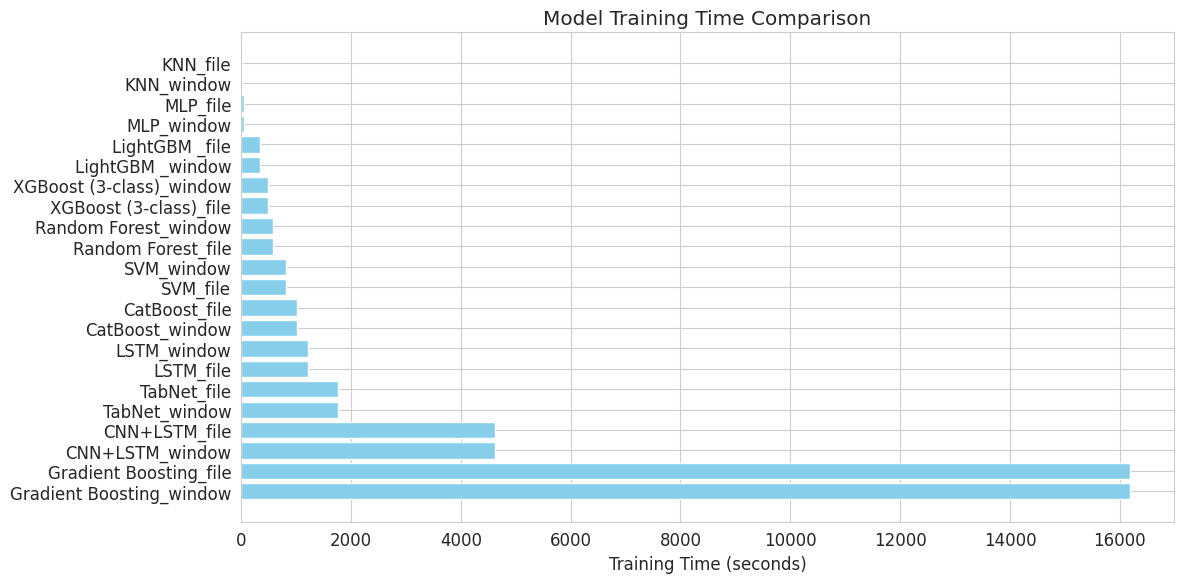

In [ ]:

# Plot Training Time Bar Chart
plt.figure(figsize=(12,6))
metrics_df_sorted = metrics_df.sort_values('Training Time', ascending=False)
plt.barh(metrics_df_sorted.index, metrics_df_sorted['Training Time'], color='skyblue')
plt.xlabel('Training Time (seconds)')
plt.title('Model Training Time Comparison')
plt.tight_layout()
plt.show()


In [ ]:

#Display models comparsion and save
print(metrics_df.round(4))

# Save metrics to CSV
metrics_df.to_csv('all_models_metrics.csv')


                          Accuracy    Loss  Precision  Recall      F1     FNR  \
LightGBM _window            0.8719  0.6197     0.8788  0.8731  0.8750  0.1269   
LightGBM _file              0.9741  0.1326     0.9737  0.9654  0.9694  0.0346   
CatBoost_window             0.8631  0.3768     0.8682  0.8649  0.8657  0.1351   
CatBoost_file               0.9741  0.1825     0.9737  0.9654  0.9694  0.0346   
XGBoost (3-class)_window    0.8685  0.4452     0.8756  0.8699  0.8715  0.1301   
XGBoost (3-class)_file      0.9741  0.1564     0.9737  0.9654  0.9694  0.0346   
SVM_window                  0.7558  0.6291     0.7541  0.7611  0.7553  0.2389   
SVM_file                    0.9224  0.3841     0.9226  0.8784  0.8908  0.1216   
Random Forest_window        0.8603  0.3831     0.8674  0.8620  0.8636  0.1380   
Random Forest_file          0.9569  0.2226     0.9500  0.9541  0.9519  0.0459   
KNN_window                  0.7495  2.2713     0.7492  0.7548  0.7511  0.2452   
KNN_file                    

# **SHAP Analysis**


SHAP ANALYSIS (LightGBM with 3 classes)


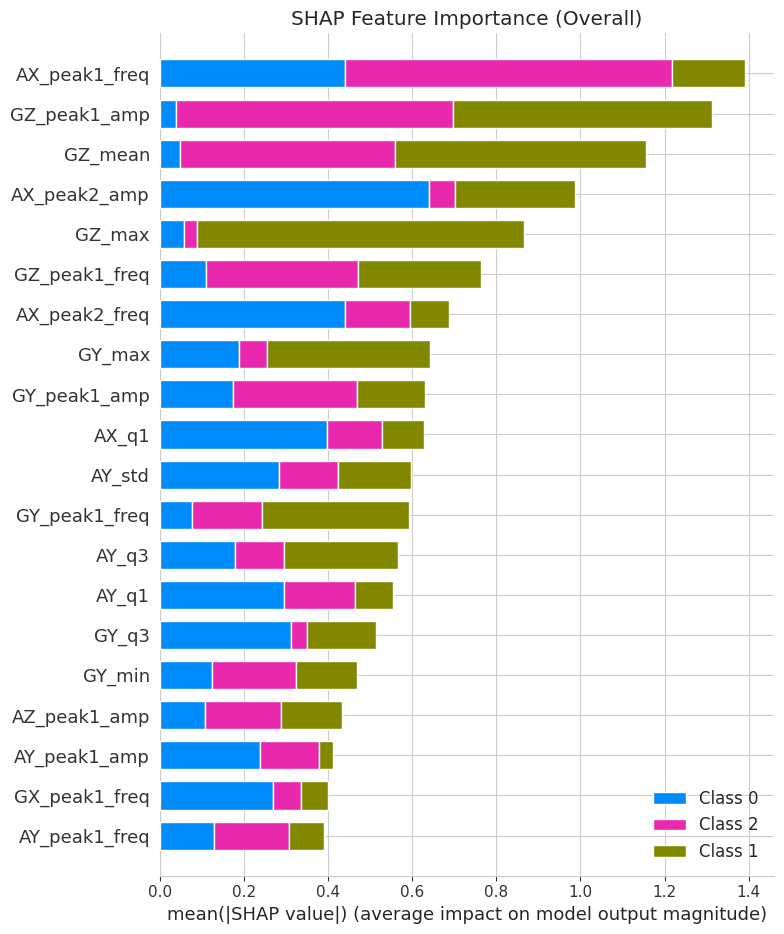

SHAP analysis completed.


In [ ]:

# ====================== SHAP ANALYSIS ON BEST LIGHTGBM ======================
print("\n" + "="*80)
print("SHAP ANALYSIS (LightGBM with 3 classes)")
print("="*80)

final_lgb = best_lgb
lgb_classifier = final_lgb.named_steps['clf']
X_sample = X.sample(n=min(200, len(X)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(lgb_classifier)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Tremor class)")
    plt.tight_layout()
    plt.show()
else:
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Overall)")
    plt.tight_layout()
    plt.show()

print("SHAP analysis completed.")

# **Save Models**

In [ ]:
joblib.dump(best_lgb, "best_lgb.pkl")
#joblib.dump(scaler, "xscaler.pkl")
joblib.dump(best_cat, "best_cat.pkl")
joblib.dump(best_xgb, "best_xgb.pkl")
joblib.dump(best_svm, "best_svm.pkl")
joblib.dump(best_rf, "best_rf.pkl")
joblib.dump(best_knn, "best_knn.pkl")
joblib.dump(best_mlp, "best_mlp.pkl")
joblib.dump(best_lstm, "best_lstm.pkl")
joblib.dump(best_tabnet, "best_tabnet.pkl")
best_model_cnn_lstm.save("best_cnn_lstm_3class.h5")
joblib.dump(best_gb, "best_gb.pkl")

' #joblib.dump(scaler, "xscaler.pkl")\njoblib.dump(best_cat, "best_cat.pkl")\njoblib.dump(best_xgb, "best_xgb.pkl")\njoblib.dump(best_svm, "best_svm.pkl")\njoblib.dump(best_rf, "best_rf.pkl")\njoblib.dump(best_knn, "best_knn.pkl")\njoblib.dump(best_mlp, "best_mlp.pkl")\njoblib.dump(best_lstm, "best_lstm.pkl")\njoblib.dump(best_tabnet, "best_tabnet.pkl")\nbest_model_cnn_lstm.save("best_cnn_lstm_3class.h5")\njoblib.dump(best_gb, "best_gb.pkl") '

In [ ]:
best_tabnet.named_steps['clf'].model_.save_model("best_tabnet")

Successfully saved model at best_tabnet.zip


'best_tabnet.zip'

# **Test samples**

In [ ]:
def preprocess_raw_csv(df_raw):
    """
    Applies resampling and bandpass filtering to raw sensor data.
    Assumes df_raw has columns T, AX, AY, AZ, GX, GY, GZ.
    """
    # 1. Resample to constant FS
    df_resampled = resample_df(df_raw.copy())
    # 2. Bandpass filter
    for c in SIGNAL_COLS:
        df_resampled[c] = bandpass(df_resampled[c].values)
    return df_resampled

def extract_windows_features(processed_df):
    """
    Extracts features from sliding windows of preprocessed sensor data.
    """
    window_features = []
    for start in range(0, len(processed_df) - WINDOW_SIZE + 1, WINDOW_SIZE):
        win = processed_df.iloc[start:start + WINDOW_SIZE]
        feats = extract_features(win)
        window_features.append(feats)
    if not window_features:
        return pd.DataFrame()
    return pd.DataFrame(window_features)

def align_features_to_model(features_df, model_pipeline, X_global=X):
    """
    Reindexes the extracted features to match the model's expected input columns.
    """
    # Get feature names from the trained model if available, otherwise use global X columns
    model_feature_names = None
    if hasattr(model_pipeline, 'feature_names_in_'):
        model_feature_names = model_pipeline.feature_names_in_
    elif hasattr(model_pipeline.named_steps['clf'], 'feature_names_in_'):
        model_feature_names = model_pipeline.named_steps['clf'].feature_names_in_

    if model_feature_names is not None:
        # Ensure all columns are strings for reindexing consistency
        current_columns = [str(col) for col in features_df.columns]
        features_df.columns = current_columns
        features_df = features_df.reindex(columns=model_feature_names, fill_value=0)
    else:
        # Fallback to the global X columns if model feature names are not accessible
        print("Warning: Could not get feature names from model pipeline, using global X columns.")
        # Ensure columns are aligned by name and fill missing with 0
        features_df = features_df.reindex(columns=X_global.columns, fill_value=0.0)

    # Handle NaN/Inf values, as done during training
    features_df = features_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return features_df

def predict_file(model_pipeline, raw_file_df, file_id, true_class_label):
    """
    Preprocesses a raw file, extracts features, makes predictions,
    and returns window-level details and the file-level prediction.
    """
    df_copy = raw_file_df.copy()
    df_copy.columns = ["T","AX","AY","AZ","GX","GY","GZ","file_id","label"] # Ensure correct columns

    # Preprocess raw data
    processed_df = preprocess_raw_csv(df_copy)

    # Extract window features
    feats_df = extract_windows_features(processed_df)

    if feats_df.empty:
        return None, None, None # No windows to process

    # Align features to model's expected input
    feats_df_aligned = align_features_to_model(feats_df, model_pipeline)

    # Make predictions
    proba = model_pipeline.predict_proba(feats_df_aligned)
    window_preds = np.argmax(proba, axis=1)
    final_pred_idx = np.bincount(window_preds).argmax() # Majority vote

    class_names = {0: "Non-Tremor", 1: "Tremor", 2: "Voluntary"}
    final_pred_str = class_names.get(final_pred_idx, "Unknown")

    # Prepare window_df for output
    window_df = feats_df_aligned.copy()
    window_df["predicted_class_idx"] = window_preds
    window_df["predicted_class_name"] = [class_names.get(p, "Unknown") for p in window_preds]
    window_df["confidence_0"] = proba[:, 0]
    window_df["confidence_1"] = proba[:, 1]
    window_df["confidence_2"] = proba[:, 2]

    return window_df, final_pred_str, true_class_label

In [ ]:
# ====================== TESTING ON REAL FILES (TRAINING-LIKE PREPROCESSING) ======================
def test_model_on_file(raw_df, model_pipeline, file_id):
    """
    Test a single raw file: applies resample, bandpass, windowing, feature extraction,
    then majority voting and probabilities.
    Returns: (predicted_class_index, probabilities_per_window, true_label)
    """
    file_data = raw_df[raw_df["file_id"] == file_id].copy()
    if len(file_data) == 0:
        print(f"File {file_id} not found.")
        return None, None, None

    # 1. Resample to constant FS
    df_resampled = resample_df(file_data)
    # 2. Bandpass filter
    for c in SIGNAL_COLS:
        df_resampled[c] = bandpass(df_resampled[c].values)

    # 3. Sliding windows + feature extraction
    window_features = []
    for start in range(0, len(df_resampled) - WINDOW_SIZE + 1, WINDOW_SIZE):
        win = df_resampled.iloc[start:start + WINDOW_SIZE]
        feats = extract_features(win)
        window_features.append(feats)

    if not window_features:
        print("No complete windows found.")
        return None, None, None

    features_df = pd.DataFrame(window_features)

    # Reindex to match model's expected columns (handle both pipeline and raw classifier)
    if hasattr(model_pipeline, 'feature_names_in_'):
        features_df = features_df.reindex(columns=model_pipeline.feature_names_in_, fill_value=0)
    elif hasattr(model_pipeline.named_steps['clf'], 'feature_names_in_'):
        features_df = features_df.reindex(columns=model_pipeline.named_steps['clf'].feature_names_in_, fill_value=0)
    else:
        # Fallback: use the columns from training (X.columns)
        features_df = features_df.reindex(columns=X.columns, fill_value=0)

    proba = model_pipeline.predict_proba(features_df)           # shape (n_windows, 3)
    window_preds = np.argmax(proba, axis=1)
    final_pred = np.bincount(window_preds).argmax()             # majority vote
    true_label = file_data['label'].iloc[0]

    return final_pred, proba, true_label

# ====================== SELECT AND TEST ONE FILE PER CLASS ======================
print("\n" + "="*80)
print("TESTING ON REAL FILES (CONTROL, PARKINSON, VOLUNTARY)")
print("="*80)

# Group file IDs by true label (0=Control, 1=Parkinson) and also detect voluntary via CD=02
control_ids = []
parkinson_ids = []
voluntary_ids = []

for fid in raw_df["file_id"].unique():
    # True label from raw metadata (0 or 1)
    true_lab = raw_df[raw_df["file_id"] == fid]["label"].iloc[0]
    if true_lab == 2:
        voluntary_ids.append(fid)
    elif true_lab == 0:
        control_ids.append(fid)
    else:
        parkinson_ids.append(fid)

# Test one from each category (if exists)
class_names = ["Non-Tremor", "Tremor", "Voluntary"]

if control_ids:
    fid = control_ids[0]
    pred, proba, true = test_model_on_file(raw_df, best_lgb, fid)
    if pred is not None:
        print(f"\nCONTROL file: {fid}")
        print(f"   True class: {class_names[true]} (label={true})")
        print(f"   Predicted class: {class_names[pred]} (confidence: {np.max(proba.mean(axis=0)):.3f})")
        print(f"   Window agreement: {np.mean(np.argmax(proba, axis=1) == pred):.2%}")

if parkinson_ids:
    fid = parkinson_ids[0]
    pred, proba, true = test_model_on_file(raw_df, best_lgb, fid)
    if pred is not None:
        print(f"\nPARKINSON file: {fid}")
        print(f"   True class: {class_names[true]} (label={true})")
        print(f"   Predicted class: {class_names[pred]} (confidence: {np.max(proba.mean(axis=0)):.3f})")
        print(f"   Window agreement: {np.mean(np.argmax(proba, axis=1) == pred):.2%}")

if voluntary_ids:
    fid = voluntary_ids[0]
    pred, proba, true = test_model_on_file(raw_df, best_lgb, fid)
    if pred is not None:
        print(f"\nVOLUNTARY file: {fid}")
        print(f"   True label from original (0/1): {true} (but CD=02 forces Voluntary class)")
        print(f"   Predicted class: {class_names[pred]} (confidence: {np.max(proba.mean(axis=0)):.3f})")
        print(f"   Window agreement: {np.mean(np.argmax(proba, axis=1) == pred):.2%}")
else:
    print("\nNo voluntary files (CD=02) found in raw data for testing.")

print("\n" + "="*80)
print("TESTING COMPLETED")
print("="*80)


TESTING ON REAL FILES (CONTROL, PARKINSON, VOLUNTARY)

CONTROL file: Clean Dataset – Control Group/ID01010100
   True class: Non-Tremor (label=0)
   Predicted class: Non-Tremor (confidence: 1.000)
   Window agreement: 100.00%

PARKINSON file: Clean Dataset – Parkinson’s Group/ID07010201
   True class: Tremor (label=1)
   Predicted class: Tremor (confidence: 0.998)
   Window agreement: 100.00%

VOLUNTARY file: ‏‏Clean Dataset – Voluntary Group/ID01020101
   True label from original (0/1): 2 (but CD=02 forces Voluntary class)
   Predicted class: Voluntary (confidence: 1.000)
   Window agreement: 100.00%

TESTING COMPLETED



RANDOM TEST ON ORIGINAL DATASET (WINDOW-LEVEL DETAILS + FILE CONFUSION MATRIX)
Available files: Control=60, Parkinson=23, Voluntary=37


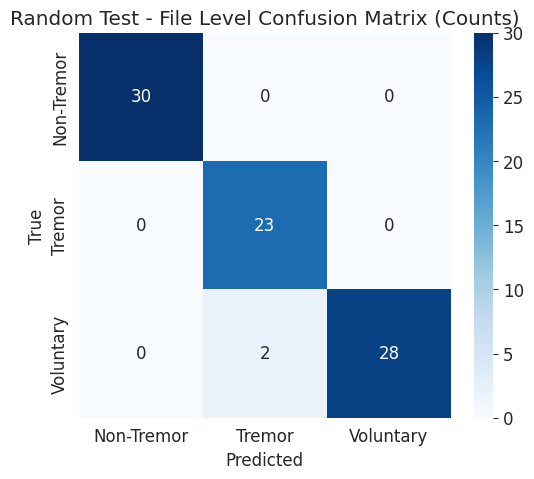


Classification Report (File Level):
              precision    recall  f1-score   support

  Non-Tremor       1.00      1.00      1.00        30
      Tremor       0.92      1.00      0.96        23
   Voluntary       1.00      0.93      0.97        30

    accuracy                           0.98        83
   macro avg       0.97      0.98      0.97        83
weighted avg       0.98      0.98      0.98        83


--- Window-Level DataFrame (showing all rows) ---


,file_id,true_class,AX_mean,AX_std,AX_median,AX_q1,AX_q3,AX_min,AX_max,AX_peak1_freq,AX_peak1_amp,AX_peak2_freq,AX_peak2_amp,AY_mean,AY_std,AY_median,AY_q1,AY_q3,AY_min,AY_max,AY_peak1_freq,AY_peak1_amp,AY_peak2_freq,AY_peak2_amp,AZ_mean,AZ_std,AZ_median,AZ_q1,AZ_q3,AZ_min,AZ_max,AZ_peak1_freq,AZ_peak1_amp,AZ_peak2_freq,AZ_peak2_amp,GX_mean,GX_std,GX_median,GX_q1,GX_q3,GX_min,GX_max,GX_peak1_freq,GX_peak1_amp,GX_peak2_freq,GX_peak2_amp,GY_mean,GY_std,GY_median,GY_q1,GY_q3,GY_min,GY_max,GY_peak1_freq,GY_peak1_amp,GY_peak2_freq,GY_peak2_amp,GZ_mean,GZ_std,GZ_median,GZ_q1,GZ_q3,GZ_min,GZ_max,GZ_peak1_freq,GZ_peak1_amp,GZ_peak2_freq,GZ_peak2_amp,predicted_class_idx,predicted_class_name,confidence_0,confidence_1,confidence_2
0,Clean Dataset – Control Group/ID05010101,0,-0.039861,0.098093,-0.032229,-0.110171,0.034966,-0.269869,0.132393,0.995075,2.633788,2.985224,2.280702,-0.019623,0.150572,-0.038842,-0.120416,0.045199,-0.267324,0.632111,0.995075,4.596873,7.960597,2.694736,0.016352,0.118943,0.020414,-0.061778,0.120240,-0.340406,0.219656,0.995075,3.099157,2.985224,2.411250,0.007440,0.046129,0.014575,-0.032521,0.045561,-0.089266,0.094634,1.990149,1.254017,4.975373,0.992704,-0.008595,0.027054,-0.005884,-0.021331,0.007549,-0.061755,0.050659,0.995075,1.046868,2.985224,0.474276,0.003369,0.021059,-0.001955,-0.012777,0.018469,-0.036871,0.047496,1.990149,0.753962,0.995075,0.305858,0,Non-Tremor,0.991477,8.186197e-03,0.000337
1,Clean Dataset – Control Group/ID05010101,0,0.008147,0.077569,0.013742,-0.033390,0.063648,-0.182101,0.151239,2.985224,1.571617,15.921194,1.465811,-0.002789,0.057862,-0.007754,-0.047320,0.039047,-0.104137,0.161225,6.965522,1.102245,3.980299,1.051934,-0.002329,0.055616,-0.008289,-0.043349,0.043578,-0.151977,0.118959,6.965522,0.998629,5.970448,0.945858,-0.005246,0.020708,-0.005988,-0.019373,0.005707,-0.057605,0.046729,6.965522,0.557327,2.985224,0.372878,0.001688,0.010532,0.001081,-0.005732,0.009569,-0.027655,0.020342,0.995075,0.262091,1.990149,0.206842,0.001950,0.011608,0.002273,-0.007066,0.009778,-0.020923,0.027985,3.980299,0.372507,0.995075,0.311698,0,Non-Tremor,0.998765,6.718986e-04,0.000563
2,Clean Dataset – Control Group/ID05010101,0,-0.009095,0.063810,-0.011418,-0.059822,0.031921,-0.163248,0.144554,15.921194,1.748866,16.916269,1.213309,-0.000366,0.063329,-0.001990,-0.037406,0.039493,-0.177222,0.115588,0.995075,1.896065,6.965522,1.142534,-0.000895,0.076846,0.003577,-0.053449,0.042601,-0.178880,0.161474,2.985224,2.204542,0.995075,1.554648,0.000195,0.017289,0.001250,-0.012084,0.011348,-0.032598,0.040321,6.965522,0.449718,3.980299,0.383044,-0.001547,0.013037,-0.005494,-0.011423,0.005764,-0.020256,0.025823,0.995075,0.384206,2.985224,0.349227,-0.001796,0.012697,0.000153,-0.008954,0.006835,-0.031398,0.020476,0.995075,0.458587,1.990149,0.300960,0,Non-Tremor,0.999748,1.775556e-04,0.000074
3,Clean Dataset – Parkinson’s Group/ID07020203,1,0.046930,0.302786,0.084222,-0.075151,0.213889,-0.809736,0.793464,2.985224,5.930499,5.970448,5.365993,-0.052505,0.624276,-0.058296,-0.462403,0.340768,-1.483934,1.249917,0.995075,15.379388,5.970448,14.057342,0.030223,0.265909,0.053363,-0.162787,0.238857,-0.548298,0.462423,0.995075,9.497270,2.985224,5.359241,0.014729,0.153459,0.037515,-0.045827,0.117849,-0.373127,0.291758,0.995075,4.218820,5.970448,4.118710,0.012215,0.090167,0.016141,-0.067939,0.090213,-0.174068,0.188487,0.995075,2.084169,1.990149,1.899574,0.012549,0.139142,-0.018021,-0.105701,0.126276,-0.163525,0.296606,0.995075,5.399488,1.990149,3.040109,1,Tremor,0.000201,5.068578e-01,0.492941
4,Clean Dataset – Parkinson’s Group/ID07020203,1,-0.020758,0.211135,-0.050426,-0.165850,0.079236,-0.488046,0.485644,6.965522,5.663970,4.975373,3.751266,0.082476,0.401883,0.073595,-0.163908,0.293071,-0.971877,1.032961,5.970448,11.848362,6.965522,6.866507,0.023715,0.183553,-0.007446,-0.096647,0.141247,-0.343451,0.396201,6.965522,5.942517,5.970448,3.841867,0.007548,0.103120,0.004193,-0.053461,0.074304,-0.255060,0.231231,5.970448,2.705739,6.965522,2.529364,-0.0


Saved window results to 'random_test_window_results.csv'

FOLDER TEST (specify your folder path containing CSV files)


In [ ]:
def preprocess_raw_csv(df_raw):
    """
    Applies resampling and bandpass filtering to raw sensor data.
    Assumes df_raw has columns T, AX, AY, AZ, GX, GY, GZ.
    """
    # 1. Resample to constant FS
    df_resampled = resample_df(df_raw.copy())
    # 2. Bandpass filter
    for c in SIGNAL_COLS:
        df_resampled[c] = bandpass(df_resampled[c].values)
    return df_resampled

def extract_windows_features(processed_df):
    """
    Extracts features from sliding windows of preprocessed sensor data.
    """
    window_features = []
    for start in range(0, len(processed_df) - WINDOW_SIZE + 1, WINDOW_SIZE):
        win = processed_df.iloc[start:start + WINDOW_SIZE]
        feats = extract_features(win)
        window_features.append(feats)
    if not window_features:
        return pd.DataFrame()
    return pd.DataFrame(window_features)

def align_features_to_model(features_df, model_pipeline, X_global=X):
    """
    Reindexes the extracted features to match the model's expected input columns.
    """
    # Get feature names from the trained model if available, otherwise use global X columns
    model_feature_names = None
    if hasattr(model_pipeline, 'feature_names_in_'):
        model_feature_names = model_pipeline.feature_names_in_
    elif hasattr(model_pipeline.named_steps['clf'], 'feature_names_in_'):
        model_feature_names = model_pipeline.named_steps['clf'].feature_names_in_

    if model_feature_names is not None:
        # Ensure all columns are strings for reindexing consistency
        current_columns = [str(col) for col in features_df.columns]
        features_df.columns = current_columns
        features_df = features_df.reindex(columns=model_feature_names, fill_value=0)
    else:
        # Fallback to the global X columns if model feature names are not accessible
        print("Warning: Could not get feature names from model pipeline, using global X columns.")
        # Ensure columns are aligned by name and fill missing with 0
        features_df = features_df.reindex(columns=X_global.columns, fill_value=0.0)

    # Handle NaN/Inf values, as done during training
    features_df = features_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return features_df

def predict_file(model_pipeline, raw_file_df, file_id, true_class_label):
    """
    Preprocesses a raw file, extracts features, makes predictions,
    and returns window-level details and the file-level prediction.
    """
    df_copy = raw_file_df.copy()
    df_copy.columns = ["T","AX","AY","AZ","GX","GY","GZ","file_id","label"] # Ensure correct columns

    # Preprocess raw data
    processed_df = preprocess_raw_csv(df_copy)

    # Extract window features
    feats_df = extract_windows_features(processed_df)

    if feats_df.empty:
        return None, None, None # No windows to process

    # Align features to model's expected input
    feats_df_aligned = align_features_to_model(feats_df, model_pipeline)

    # Make predictions
    proba = model_pipeline.predict_proba(feats_df_aligned)
    window_preds = np.argmax(proba, axis=1)
    final_pred_idx = np.bincount(window_preds).argmax() # Majority vote

    class_names = {0: "Non-Tremor", 1: "Tremor", 2: "Voluntary"}
    final_pred_str = class_names.get(final_pred_idx, "Unknown")

    # Prepare window_df for output
    window_df = feats_df_aligned.copy()
    window_df["predicted_class_idx"] = window_preds
    window_df["predicted_class_name"] = [class_names.get(p, "Unknown") for p in window_preds]
    window_df["confidence_0"] = proba[:, 0]
    window_df["confidence_1"] = proba[:, 1]
    window_df["confidence_2"] = proba[:, 2]

    return window_df, final_pred_str, true_class_label

def random_test_from_original(raw_df, model_pipeline, n_per_class=30):
    """
    Select random files from each class from raw_df, test each file,
    return a detailed window-level dataframe and a file-level confusion matrix.
    """
    # Identify files by their true label (0,1) plus CD=02 for voluntary
    control_files = []
    parkinson_files = []
    voluntary_files = []
    for fid in raw_df["file_id"].unique():
        true_lab = raw_df[raw_df["file_id"] == fid]["label"].iloc[0]
        if true_lab == 2:
            voluntary_files.append(fid)
        elif true_lab == 0:
            control_files.append(fid)
        else:
            parkinson_files.append(fid)

    print(f"Available files: Control={len(control_files)}, Parkinson={len(parkinson_files)}, Voluntary={len(voluntary_files)}")

    # Random selection with n_per_class (or all if less)
    selected = []
    if control_files:
        selected.extend(np.random.choice(control_files, min(n_per_class, len(control_files)), replace=False))
    if parkinson_files:
        selected.extend(np.random.choice(parkinson_files, min(n_per_class, len(parkinson_files)), replace=False))
    if voluntary_files:
        selected.extend(np.random.choice(voluntary_files, min(n_per_class, len(voluntary_files)), replace=False))

    all_window_dfs = []
    y_true_files = []
    y_pred_files = []

    for fid in selected:
        file_raw = raw_df[raw_df["file_id"] == fid].copy()
        true_label = file_raw["label"].iloc[0]
        true_class = true_label

        window_df, final_pred_str, _ = predict_file(model_pipeline, file_raw, fid, true_class)
        if window_df is not None:
            window_df.insert(0, "file_id", fid)
            window_df.insert(1, "true_class", true_class)
            all_window_dfs.append(window_df)
            final_pred_num = 0 if final_pred_str == "Non-Tremor" else 1 if final_pred_str == "Tremor" else 2
            y_true_files.append(true_class)
            y_pred_files.append(final_pred_num)

    if not all_window_dfs:
        print("No files selected.")
        return None, None

    combined_windows = pd.concat(all_window_dfs, ignore_index=True)

    # Shuffle rows to mix classes, but ensure first few rows show examples of each class
    # We'll keep first 3 rows from each class if available
    sample_rows = []
    for class_val in [0, 1, 2]:
        class_rows = combined_windows[combined_windows["true_class"] == class_val]
        if len(class_rows) > 0:
            sample_rows.append(class_rows.iloc[:3])  # take first 3 rows per class

    if sample_rows:
        sample_rows = pd.concat(sample_rows, ignore_index=True)
        # Remove those rows from the main df and concatenate at the top
        combined_windows = combined_windows.drop(sample_rows.index)
        combined_windows = pd.concat([sample_rows, combined_windows], ignore_index=True)

    # File-level confusion matrix (counts, not percentages)
    cm = confusion_matrix(y_true_files, y_pred_files)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title("Random Test - File Level Confusion Matrix (Counts)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report (File Level):")
    print(classification_report(y_true_files, y_pred_files,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))

    return combined_windows, (y_true_files, y_pred_files)


# ====================== EXAMPLE USAGE ======================
print("\n" + "="*80)
print("RANDOM TEST ON ORIGINAL DATASET (WINDOW-LEVEL DETAILS + FILE CONFUSION MATRIX)")
print("="*80)

# Use best_lgb as model (or any trained model)
window_results, file_level_results = random_test_from_original(raw_df, best_lgb, n_per_class=30)

if window_results is not None:
    # Display the DataFrame in a single scrollable view (Colab-friendly)
    from IPython.display import display
    print("\n--- Window-Level DataFrame (showing all rows) ---")
    # Set display options to show all columns in one line
    with pd.option_context('display.max_columns', None, 'display.width', None):
        display(window_results)

    window_results.to_csv("random_test_window_results.csv", index=False)
    print("\nSaved window results to 'random_test_window_results.csv'")

print("\n" + "="*80)
print("FOLDER TEST (specify your folder path containing CSV files)")
print("="*80)


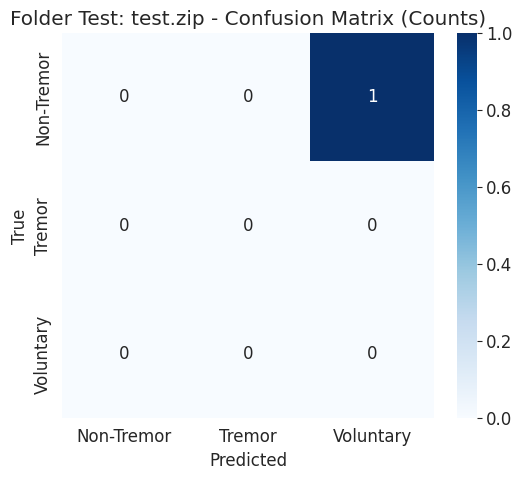


Classification Report (File Level):
              precision    recall  f1-score   support

  Non-Tremor       0.00      0.00      0.00       1.0
      Tremor       0.00      0.00      0.00       0.0
   Voluntary       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

                       file  true_class  pred_class
0  Hamdy_read_save_4_ms.csv           0           2


In [ ]:
def test_folder(folder_path, model_pipeline, raw_df, default_label=None):
    def get_true_class(fid, folder_name="", filename=""):
        # 1. Try folder name
        if "control" in folder_name.lower():
            return 0
        elif "parkinson" in folder_name.lower():
            return 1
        elif "voluntary" in folder_name.lower():
            return 2

        # 2. Try filename
        fname_lower = filename.lower()
        if "control" in fname_lower:
            return 0
        elif "parkinson" in fname_lower:
            return 1
        elif "voluntary" in fname_lower:
            return 2

        # 3. Try raw_df (بدون استخدام cd)
        subset = raw_df[raw_df["file_id"] == fid]
        if len(subset) > 0:
            return subset["label"].iloc[0]  # 0, 1, أو 2 مباشرة

        # 4. Use default_label if provided
        if default_label is not None:
            return default_label

        return None

    # Handle zip file
    temp_dir = None
    if folder_path.lower().endswith('.zip'):
        temp_dir = tempfile.mkdtemp(prefix="tabnet_test_")
        with zipfile.ZipFile(folder_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
        base_path = temp_dir
    else:
        base_path = folder_path

    y_true = []
    y_pred = []
    file_names = []
    all_csv_files = []

    for root, dirs, files in os.walk(base_path):
        folder_name = os.path.basename(root) if root != base_path else ""

        for filename in files:
            if not filename.lower().endswith(".csv"):
                continue
            all_csv_files.append(filename)
            filepath = os.path.join(root, filename)
            df_raw = pd.read_csv(filepath)
            df_raw.columns = ["T","AX","AY","AZ","GX","GY","GZ"]
            file_id = os.path.splitext(filename)[0]
            true_class = get_true_class(file_id, folder_name, filename)
            if true_class is None:
                print(f"Skipping {filename}: cannot determine true class.")
                continue

            # Preprocess and predict
            processed_df = preprocess_raw_csv(df_raw)
            feats_df = extract_windows_features(processed_df)
            if feats_df.empty:
                print(f"No windows in {filename}, skipping.")
                continue
            feats_df = align_features_to_model(feats_df, model_pipeline)
            proba = model_pipeline.predict_proba(feats_df)
            preds = np.argmax(proba, axis=1)
            final_pred = np.bincount(preds).argmax()
            y_true.append(true_class)
            y_pred.append(final_pred)
            file_names.append(filename)

    if temp_dir and os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)

    if not y_true:
        print(f"No files processed. Found {len(all_csv_files)} CSV files.")
        return None

    # Always use all three class labels for reporting
    all_labels = [0, 1, 2]
    all_class_names = {
        0: "Non-Tremor",
        1: "Tremor",
        2: "Voluntary"
    }
    display_target_names = [all_class_names[label] for label in all_labels]

    # Confusion matrix (counts)
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=display_target_names,
                yticklabels=display_target_names)
    plt.title(f"Folder Test: {os.path.basename(folder_path)} - Confusion Matrix (Counts)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report (File Level):")
    print(classification_report(y_true, y_pred, labels=all_labels,
                                target_names=display_target_names))

    return pd.DataFrame({"file": file_names, "true_class": y_true, "pred_class": y_pred})

#set test files, folder pth here
folder_path = "/content/test.zip"
folder_results = test_folder(folder_path, best_lgb, raw_df)
if folder_results is not None:
  print(folder_results)

# Test Function

In [ ]:
def test_tremor_model(sensor_data_raw, global_X_df, model_path="/content/best_lgb.pkl"):
    import matplotlib.pyplot as plt
    cols = ["AX", "AY", "AZ", "GX", "GY", "GZ"]
    df = pd.DataFrame(sensor_data_raw, columns=cols).astype(float)

    # Apply scaling factors as per original notebook's data loading
    df[["AX", "AY", "AZ"]] = (df[["AX", "AY", "AZ"]] / 16384.0) * 9.81
    df[["GX", "GY", "GZ"]] = np.radians(df[["GX", "GY", "GZ"]] / 131.0)

    # Load the best LightGBM model
    model = joblib.load(model_path)

    results = []
    file_predictions = []
    all_features = []
    class_names = {0: "Non-Tremor", 1: "Tremor", 2: "Voluntary"}

    # Iterate through each sample, creating windows and extracting features
    for i in range(len(df)):
        start = max(0, i - 10)
        end = min(len(df), i + 20)
        window = df.iloc[start:end].copy()

        # Ensure a fixed window size (e.g., by repeating/padding if too small)
        if len(window) < WINDOW_SIZE:
            # Simple repetition to meet minimum size, or pad with zeros/mean
            repeat_count = (WINDOW_SIZE // len(window)) + 1
            window = pd.concat([window] * repeat_count, ignore_index=True)[:WINDOW_SIZE]

        try:
            # Extract features using the notebook's defined function
            features = extract_features(window)
            features_df = pd.DataFrame([features])

            # Handle NaN/Inf values, as done during training
            features_df = features_df.replace([np.inf, -np.inf], np.nan)
            features_df = features_df.fillna(0) # Or use a more sophisticated imputer if preferred

            # Reindex to ensure feature order and presence match the trained model
            # Use global_X_df.columns.tolist() as a robust fallback for feature names
            model_features = model.named_steps['clf'].feature_name_ if hasattr(model.named_steps['clf'], 'feature_name_') else global_X_df.columns.tolist()
            features_df = features_df.reindex(columns=model_features, fill_value=0.0)

            all_features.append(features_df)

            # Predict and get probabilities
            pred_class = model.predict(features_df)[0]
            proba = model.predict_proba(features_df)[0]

            # Get predicted label and confidence
            predicted_label = class_names.get(pred_class, "Unknown")
            confidence = proba[pred_class] * 100

            file_predictions.append(pred_class)

            results.append({
                "Sample": i,
                "Prediction": predicted_label,
                "Confidence %": round(confidence, 2),
                "Non-Tremor %": round(proba[0] * 100, 2),
                "Tremor %": round(proba[1] * 100, 2),
                "Voluntary %": round(proba[2] * 100, 2)
            })

        except Exception as e:
            print(f"Error at sample {i}: {e}")
            results.append({
                "Sample": i,
                "Prediction": "Error",
                "Confidence %": 0,
                "Non-Tremor %": 0,
                "Tremor %": 0,
                "Voluntary %": 0
            })

    # Determine final file-level prediction by majority voting
    if len(file_predictions) > 0:
        from collections import Counter
        final_pred_class = Counter(file_predictions).most_common(1)[0][0]
        final_label = class_names.get(final_pred_class, "Unknown")
    else:
        final_label = "Unknown"

    print("\n" + "="*25)
    print(f"FINAL FILE PREDICTION: {final_label}")
    print("="*25 + "\n")

    # SHAP Analysis
    # ==========================SHAP Analysis==========================
    shap_importance_df = pd.DataFrame()

    if len(all_features) > 0:
        try:
            full_features_df = pd.concat(all_features, ignore_index=True)
            full_features_df.columns = [str(c) for c in full_features_df.columns]
            real_model = model.named_steps["clf"]
            explainer = shap.TreeExplainer(real_model)
            shap_values = explainer.shap_values(full_features_df)

            # Define class names for SHAP plot for consistent labeling
            shap_class_names = [class_names[0], class_names[1], class_names[2]]

            # Plot SHAP summary for all classes with a stacked bar plot
            plt.figure(figsize=(12, 8)) # Increased figure size for better readability
            shap.summary_plot(shap_values, full_features_df, plot_type="bar", show=False,
                              class_names=shap_class_names)
            plt.title("SHAP Feature Importance (All Classes)")
            plt.tight_layout()
            plt.show()

            # Calculate overall feature importance for shap_importance_df
            # shap_values is a list of arrays, each (n_samples, n_features). Stack them.
            shap_values_stacked = np.stack(shap_values, axis=0) # Shape: (n_classes, n_samples, n_features)

            # Calculate mean absolute SHAP value for each feature, averaged across all samples and classes
            mean_shap_overall = np.mean(np.abs(shap_values_stacked), axis=(0, 1))

            feature_names = [str(c) for c in full_features_df.columns]

            shap_importance_df = pd.DataFrame({
                "feature": feature_names,
                "mean_shap": mean_shap_overall
            })

            shap_importance_df = (
                shap_importance_df
                .sort_values("mean_shap", ascending=False)
                .head(10) # Display top 10 overall features
                .reset_index(drop=True)
            )

            print("\nDEBUG SHAP")
            print("Shape:", shap_importance_df.shape)
            print(shap_importance_df.head())

            # Plot top 10 overall features based on mean absolute SHAP values
            plt.figure(figsize=(10, 6))
            sns.barplot(
                data=shap_importance_df,
                x="mean_shap",
                y="feature",
                palette='viridis' # Using a general palette for overall importance
            )
            plt.title("Top 10 Overall SHAP Feature Importance")
            plt.xlabel("Mean |SHAP| Value (Overall)")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.show()

            print("\n" + "="*25)
            print("TOP FILE-LEVEL FEATURES (Overall SHAP)")
            print("="*25)

        except Exception as e:
            print("\nSHAP ERROR:")
            print(e)
            print("\nFeature columns sample:")
            print(full_features_df.columns[:10])
            print("\nSHAP type:")
            print(type(shap_values))
            try:
                print("SHAP shape:", np.array(shap_values).shape)
            except:
                pass

    results_df = pd.DataFrame(results)
    return results_df, shap_importance_df


FINAL FILE PREDICTION: Non-Tremor



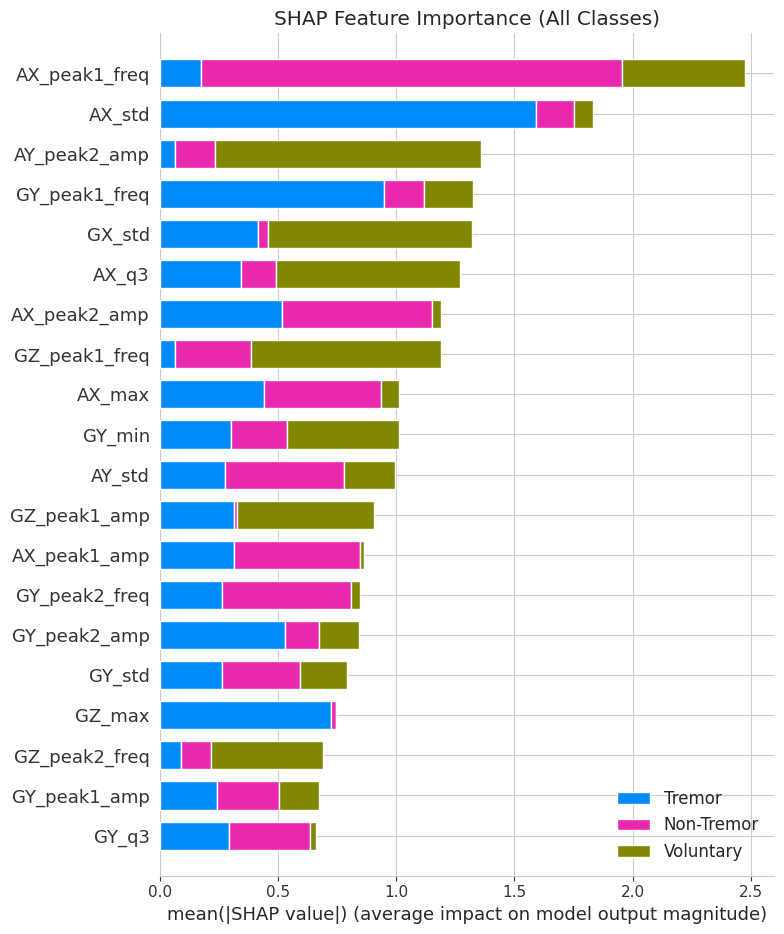


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (6, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,97.38,97.38,2.62,0.0
1,1,Non-Tremor,97.38,97.38,2.62,0.0
2,2,Non-Tremor,97.38,97.38,2.62,0.0
3,3,Non-Tremor,97.38,97.38,2.62,0.0
4,4,Non-Tremor,97.38,97.38,2.62,0.0
5,5,Non-Tremor,97.38,97.38,2.62,0.0


In [ ]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [0.907402, -8.767567, 6.663063, -0.027446, 0.016787, -0.000533], # Non-tremor like
    [-4.924, -1.288, -11.940, -3.728, 10.504, -10.259], # Tremor like
    [-4.838682, -3.28245, -5.781997, -0.047564, 0.156014, 0.054492],
    [-4.249708, 0.186748, -6.698976, 0.012657, 0.057156, -0.022516],
    [-7.345411, 6.964733, 4.168305, 0.536789, -0.645505, 1.701629],
    [7.917625, 3.74932, -2.815581, -0.106985, 0.049562, -0.048363]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Voluntary



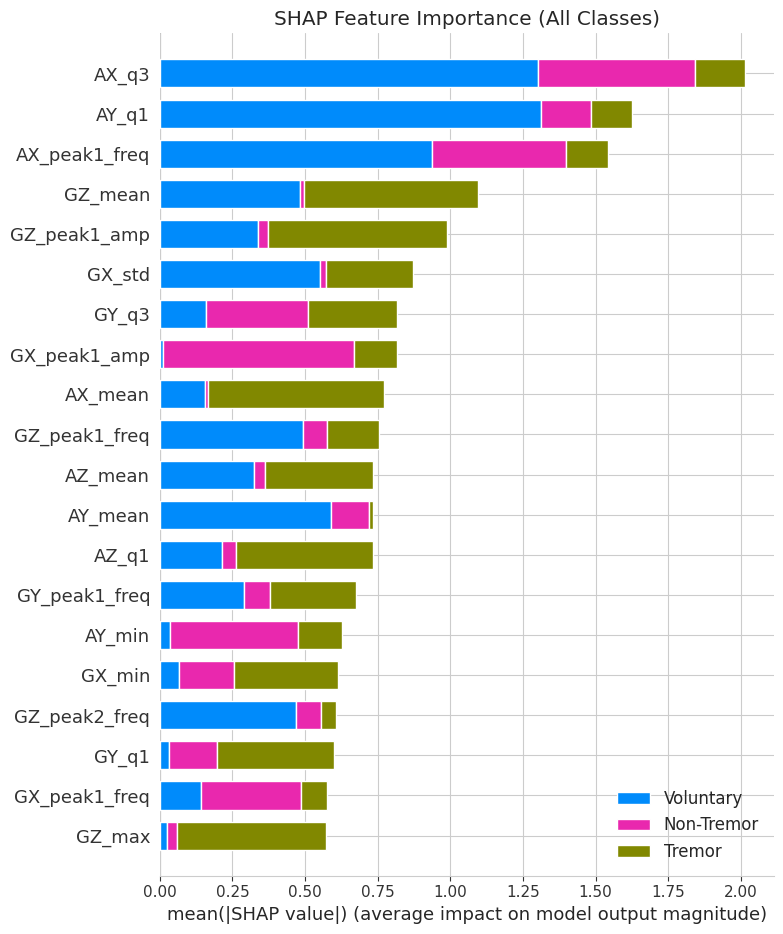


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (19, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Voluntary,92.63,4.98,2.39,92.63
1,1,Voluntary,92.63,4.98,2.39,92.63
2,2,Voluntary,92.63,4.98,2.39,92.63
3,3,Voluntary,92.63,4.98,2.39,92.63
4,4,Voluntary,92.63,4.98,2.39,92.63
5,5,Voluntary,92.63,4.98,2.39,92.63
6,6,Voluntary,92.63,4.98,2.39,92.63
7,7,Voluntary,92.63,4.98,2.39,92.63
8,8,Voluntary,92.63,4.98,2.39,92.63
9,9,Voluntary,92.63,4.98,2.39,92.63


In [ ]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-2544, 14340, -6864, 3840, -335, -1518],
    [-2380, 14188, -5644, 3888, 1635, -9604],
    [-524, 14480, -7148, 3888, -1663, -1491],
    [-528, 15052, -6672, 3904, 461, -4012],
    [-2808, 14040, -5936, 3904, 595, -339],
    [152, 14872, -6996, 3936, 704, 984],
    [-636, 14988, -6836, 3936, 1622, -3290],
    [-716, 14388, -7040, 3952, 296, 179],
    [-2456, 14196, -7584, 3952, -960, -91],
    [-2008, 14092, -7136, 3952, -448, -321],
    [-1224, 14264, -6732, 3952, -1394, 2425],
    [1356, 11692, -11328, 3952, 48, 530],
    [-80, 14880, -7036, 3968, 1145, 3629],
    [-1524, 14348, -6936, 3968, 1421, -101],
    [-1784, 14440, -6996, 3968, -389, -341],
    [-1840, 14336, -7012, 3968, -834, 941],
    [-1940, 14320, -6380, 3968, -798, -113],
    [-672, 14648, -6540, 3968, 565, 3321],
    [-1832, 14900, -7552, 3968, 2363, -2584]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



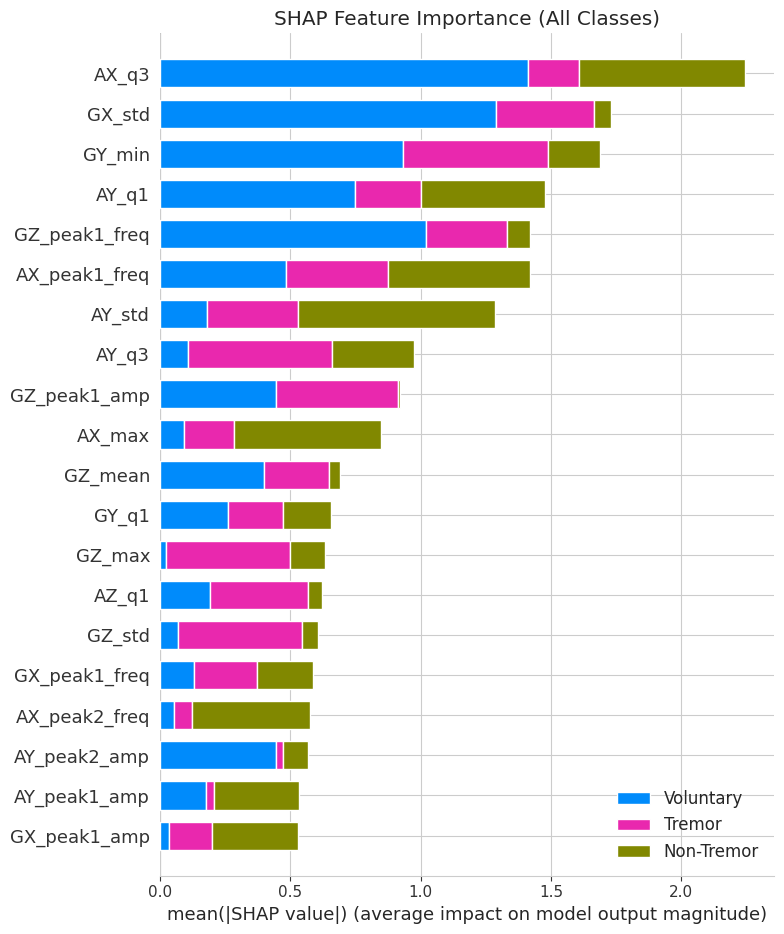


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (22, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,92.88,92.88,7.05,0.07
1,1,Non-Tremor,94.05,94.05,5.86,0.09
2,2,Non-Tremor,72.38,72.38,25.41,2.22
3,3,Non-Tremor,72.38,72.38,25.41,2.22
4,4,Non-Tremor,72.38,72.38,25.41,2.22
5,5,Non-Tremor,72.38,72.38,25.41,2.22
6,6,Non-Tremor,72.38,72.38,25.41,2.22
7,7,Non-Tremor,72.38,72.38,25.41,2.22
8,8,Non-Tremor,72.38,72.38,25.41,2.22
9,9,Non-Tremor,72.38,72.38,25.41,2.22


In [ ]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-5256, 928, -14992, 6000, 39, 326],
    [-5288, 976, -15032, 6000, 37, 352],
    [-5288, 1060, -15096, 6000, 88, 295],
    [-5272, 1004, -14964, 6000, 60, 410],
    [-5256, 920, -15008, 6000, 25, 313],
    [-5376, 1016, -15044, 6000, 53, 372],
    [-5244, 1004, -14940, 6000, 25, 338],
    [-5228, 1000, -14968, 6000, 29, 392],
    [-5136, 980, -15028, 6000, 38, 339],
    [-5204, 1044, -14940, 6000, 55, 376],
    [-5236, 1028, -15040, 6000, 40, 335],
    [-5224, 1052, -14988, 6000, 39, 367],
    [-5188, 1088, -15044, 6000, 63, 389],
    [-5136, 1128, -15128, 6000, -5, 332],
    [-5216, 1036, -15040, 6000, 64, 368],
    [-5112, 1076, -14964, 6000, 47, 342],
    [-5128, 1044, -14952, 6000, 25, 393],
    [-5216, 1108, -15092, 6000, 39, 386],
    [-5108, 1120, -15072, 6000, 47, 382],
    [-5084, 1008, -15100, 6000, 13, 395],
    [-5108, 1124, -15076, 6000, 42, 426],
    [-5908, 1008, -15028, 6000, 453, 150]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Tremor



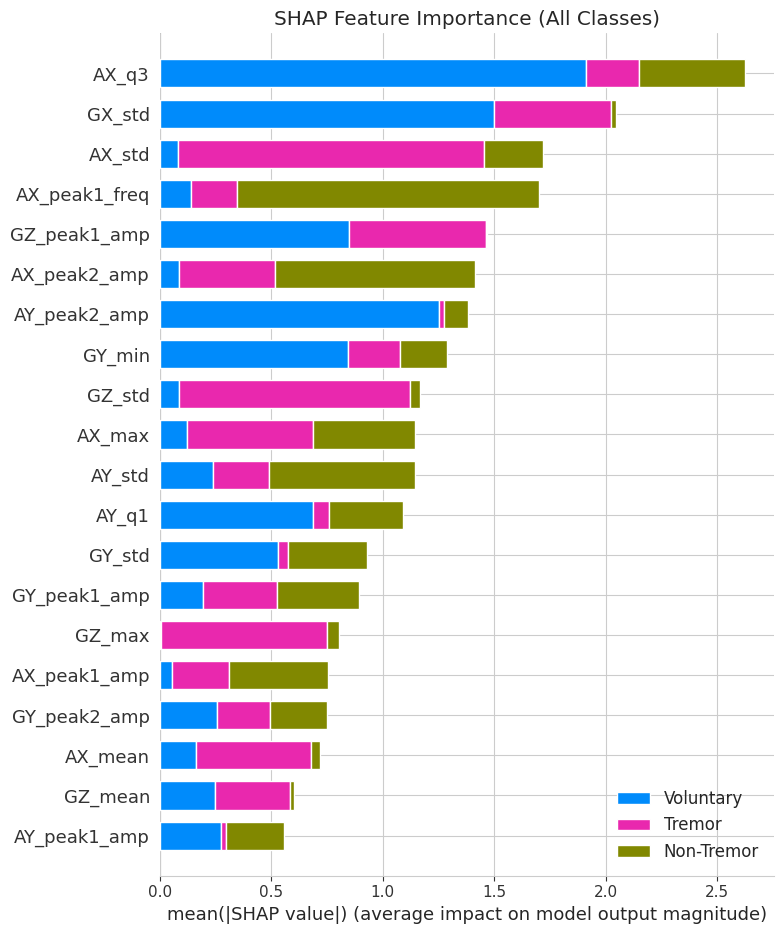


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (26, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,95.60,4.40,95.60,0.01
1,1,Tremor,95.60,4.40,95.60,0.01
2,2,Tremor,94.58,5.41,94.58,0.01
3,3,Tremor,94.83,5.16,94.83,0.01
4,4,Tremor,97.13,2.86,97.13,0.01
5,5,Tremor,98.34,1.66,98.34,0.00
6,6,Tremor,98.98,1.02,98.98,0.00
7,7,Tremor,98.98,1.02,98.98,0.00
8,8,Tremor,98.98,1.02,98.98,0.00
9,9,Tremor,98.98,1.02,98.98,0.00


In [ ]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-1526.78, 174.54, 796.55, -8.77, -9.59, 1.28],
    [-1516.49, 176.93, 795.35, -8.5, -8.07, 1.31],
    [-1516.01, 176.93, 797.75, -8.63, -6.61, 1.25],
    [-1518.16, 175.49, 800.62, -8.69, -5.6, 1.12],
    [-1520.08, 174.78, 806.37, -8.23, -5.6, 0.93],
    [-1519.12, 176.45, 807.09, -8.34, -6.21, 0.69],
    [-1522.23, 177.65, 805.17, -7.46, -6.48, 0.51],
    [-1520.8, 180.52, 804.21, -7.41, -6.63, 0.64],
    [-1514.33, 180.52, 797.03, -7.27, -5.97, 0.51],
    [-1513.61, 179.33, 791.04, -7.01, -5.2, 0.51],
    [-1517.21, 179.09, 783.86, -7.35, -4.61, 0.67],
    [-1523.19, 179.57, 784.34, -7.19, -3.22, 0.69],
    [-1526.06, 180.76, 782.66, -7.73, -1.92, 0.93],
    [-1528.7, 178.13, 780.51, -8.15, -0.88, 0.96],
    [-1530.85, 179.33, 781.71, -8.42, -0.64, 0.93],
    [-1537.56, 175.97, 779.55, -8.95, -1.81, 0.88],
    [-1539.23, 174.3, 783.38, -8.93, -3.06, 1.09],
    [-1543.06, 171.66, 780.75, -9.51, -4.96, 1.36],
    [-1542.11, 171.19, 782.66, -9.46, -5.97, 1.41],
    [-1545.7, 168.55, 781.23, -9.91, -6.85, 1.57],
    [-1544.02, 167.35, 778.59, -10.02, -7.09, 1.6],
    [-1545.22, 167.59, 780.75, -9.78, -7.19, 1.6],
    [-1549.53, 168.31, 781.23, -10.1, -7.81, 1.65],
    [-1544.74, 168.79, 782.9, -9.99, -8.61, 1.79],
    [-1546.41, 170.71, 785.3, -9.54, -9.46, 1.97],
    [-1544.02, 171.19, 784.1, -9.54, -10.15, 2.0]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Voluntary



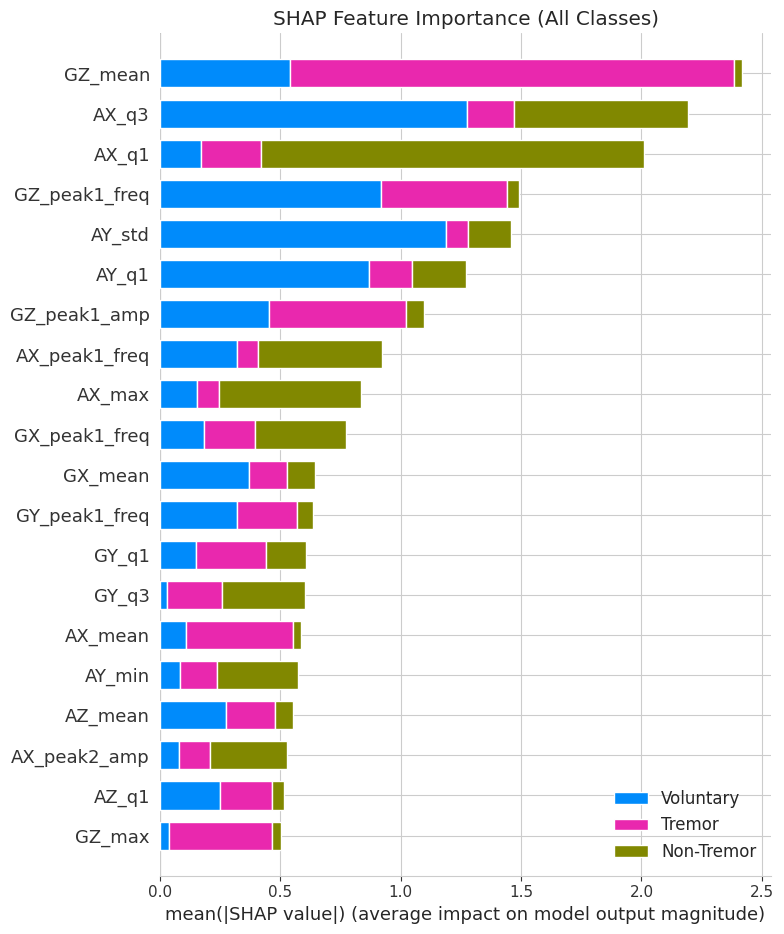


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (26, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Voluntary,63.76,24.16,12.08,63.76
1,1,Voluntary,93.02,3.57,3.42,93.02
2,2,Voluntary,94.81,2.50,2.69,94.81
3,3,Voluntary,96.67,0.68,2.65,96.67
4,4,Voluntary,66.76,18.98,14.27,66.76
5,5,Voluntary,91.64,4.86,3.50,91.64
6,6,Voluntary,67.02,13.05,19.93,67.02
7,7,Voluntary,67.02,13.05,19.93,67.02
8,8,Voluntary,67.02,13.05,19.93,67.02
9,9,Voluntary,67.02,13.05,19.93,67.02


In [ ]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-7752, 11228, -8724, 234, 1091, 500],
    [-9720, 11880, -9060, 1387, 1432, -983],
    [-7148, 10852, -9412, 2897, 3085, -1482],
    [-8996, 11652, -9500, 2307, 2272, -30],
    [-7612, 10240, -10464, 4011, 3486, -1527],
    [-8460, 10732, -10584, 2671, 2239, -1556],
    [-7084, 9484, -11388, 3579, 2860, -1845],
    [-7240, 9424, -11272, 2809, 2280, -465],
    [-8508, 8732, -12132, 2722, 2337, -1717],
    [-7280, 9100, -12092, 1690, 2141, 109],
    [-7880, 9296, -12532, 2289, 2107, -1668],
    [-8032, 9088, -12788, 2938, 3078, -921],
    [-5460, 7480, -13136, 4150, 4109, -465],
    [-7772, 8364, -13684, 1817, 994, -2904],
    [-7632, 7760, -13540, 1489, 1543, -589],
    [-5704, 7296, -13660, 3345, 2525, -1497],
    [-8300, 8184, -13984, 2550, 2536, -1653],
    [-5380, 5872, -14500, 4162, 2611, -1542],
    [-7968, 6672, -15372, 3525, 2707, -1999],
    [-4556, 5340, -15056, 2699, 2625, -1501],
    [-7592, 6196, -15872, 3662, 2816, -1504],
    [-4792, 3948, -15792, 3373, 3712, -1426],
    [-5748, 5300, -15952, 2334, 2569, -1760],
    [-4124, 3916, -15804, 2850, 2617, -837],
    [-6116, 3648, -16800, 3943, 3538, -1496],
    [-4628, 3664, -16000, 902, 1604, -693]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Tremor



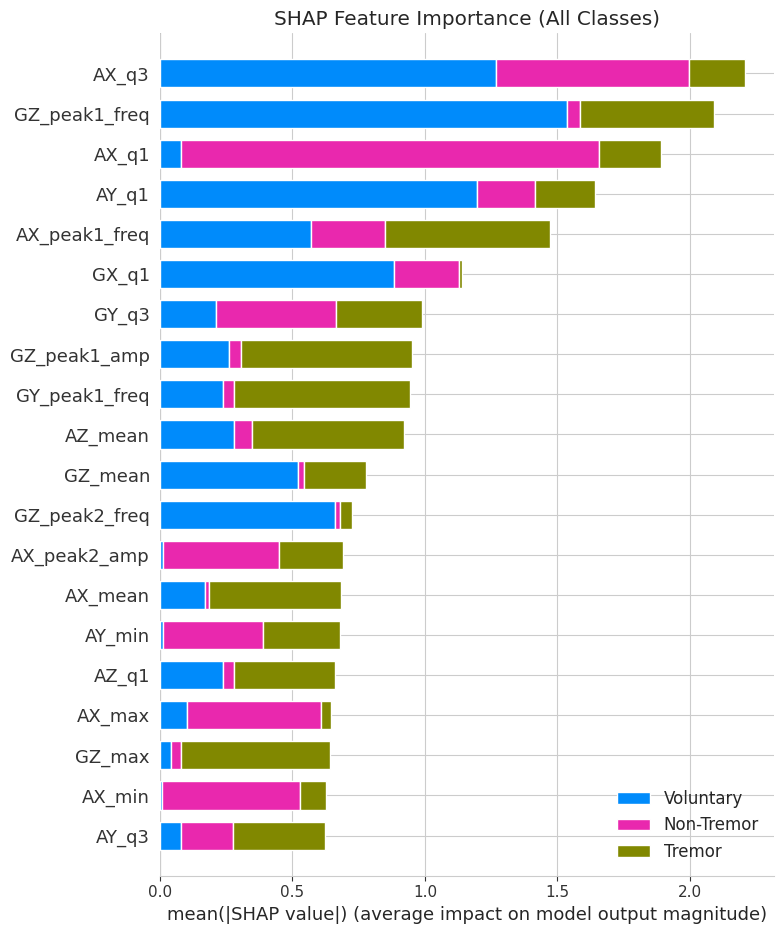


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (25, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,89.91,5.53,89.91,4.57
1,1,Tremor,95.00,1.47,95.00,3.53
2,2,Tremor,95.59,1.98,95.59,2.43
3,3,Tremor,92.38,3.23,92.38,4.39
4,4,Tremor,92.63,2.84,92.63,4.53
5,5,Tremor,93.96,2.23,93.96,3.81
6,6,Tremor,93.96,2.23,93.96,3.81
7,7,Tremor,93.96,2.23,93.96,3.81
8,8,Tremor,93.96,2.23,93.96,3.81
9,9,Tremor,93.96,2.23,93.96,3.81


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-7064, 13280, -2152, -771, -105, 461],
    [-7920, 13444, -2632, -915, -342, 396],
    [-7704, 14024, -2240, -446, 767, -892],
    [-7660, 13812, -1764, -1165, -416, -256],
    [-7476, 13640, -2476, 119, 467, -620],
    [-7964, 14000, -2256, -1053, -342, -275],
    [-7816, 14180, -2280, -325, 269, 16],
    [-7788, 13600, -2432, 240, 537, -226],
    [-7412, 13136, -2340, -1115, 2, 618],
    [-8344, 15136, -2076, -569, -207, -664],
    [-7836, 13468, -2472, 1313, 1446, -211],
    [-7632, 13756, -2248, -2005, -1175, -786],
    [-9356, 15284, -2384, 203, 633, -81],
    [-6352, 12144, -2300, 286, 710, 328],
    [-7080, 13556, -2300, -1400, -619, -107],
    [-8540, 14276, -2456, 225, 684, -593],
    [-7788, 13764, -2320, -1306, -676, 47],
    [-8504, 15020, -2628, 656, 469, -484],
    [-6732, 11916, -2740, -187, 957, 31],
    [-9124, 14672, -2252, -1418, -189, 1235],
    [-7268, 14504, -2188, 1969, 1887, -202],
    [-7800, 12996, -2728, 1235, 865, -1141],
    [-7564, 12952, -3404, 460, 597, -643],
    [-8380, 14844, -2352, 13, 380, -708],
    [-7652, 14100, -3240, 2069, 1459, -2321]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Tremor



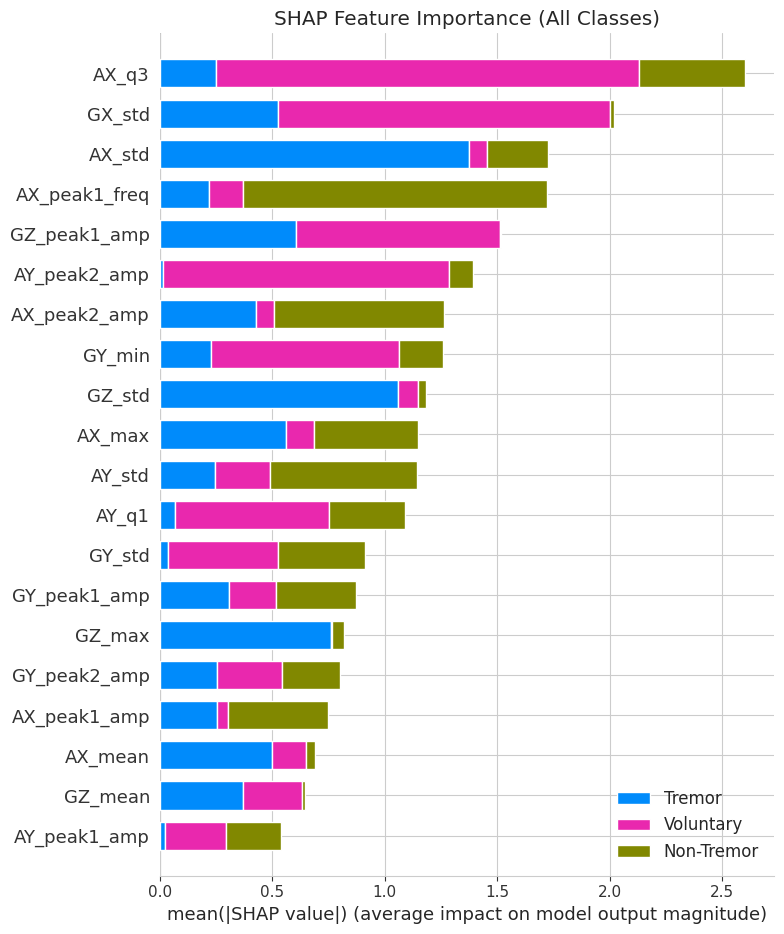


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (40, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,94.96,5.04,94.96,0.00
1,1,Tremor,95.51,4.49,95.51,0.00
2,2,Tremor,92.24,7.75,92.24,0.01
3,3,Tremor,92.24,7.75,92.24,0.01
4,4,Tremor,96.55,3.44,96.55,0.00
5,5,Tremor,96.69,3.30,96.69,0.00
6,6,Tremor,96.69,3.30,96.69,0.00
7,7,Tremor,97.27,2.73,97.27,0.00
8,8,Tremor,96.06,3.94,96.06,0.00
9,9,Tremor,96.06,3.94,96.06,0.00


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-1511.22, 201.83, 786.73, -12.5, 2.05, -0.72],
    [-1507.87, 200.16, 789.61, -12.2, 1.36, -1.55],
    [-1501.16, 201.11, 787.69, -12.12, 1.2, -2.08],
    [-1501.16, 202.07, 789.37, -12.42, 1.89, -2.56],
    [-1500.93, 202.79, 791.52, -11.75, 3.6, -2.98],
    [-1501.4, 201.59, 788.41, -11.99, 5.46, -3.38],
    [-1502.6, 201.83, 790.57, -11.72, 7.06, -3.68],
    [-1513.61, 204.7, 793.44, -11.88, 7.89, -3.76],
    [-1518.4, 203.03, 797.27, -11.99, 8.26, -3.73],
    [-1521.99, 202.55, 798.47, -11.51, 7.54, -3.73],
    [-1531.81, 201.11, 799.18, -11.56, 5.3, -3.68],
    [-1533.25, 202.07, 799.9, -11.16, 2.13, -3.33],
    [-1537.32, 204.46, 798.95, -10.87, -1.55, -2.26],
    [-1537.08, 206.62, 799.18, -10.79, -4.1, -1.39],
    [-1534.68, 206.62, 801.58, -10.29, -5.22, -0.45],
    [-1524.87, 204.94, 806.61, -10.63, -5.73, 0.51],
    [-1514.33, 202.31, 805.89, -10.31, -6.24, 1.2],
    [-1514.33, 198.48, 809.48, -10.42, -7.14, 1.97],
    [-1499.73, 199.2, 807.8, -10.74, -7.35, 2.37],
    [-1500.45, 199.92, 805.89, -10.9, -6.5, 2.72],
    [-1500.21, 198.72, 804.69, -11.96, -4.93, 2.93],
    [-1502.6, 196.32, 800.62, -12.2, -2.8, 2.88],
    [-1508.35, 194.17, 797.27, -12.63, -1.36, 2.93],
    [-1504.52, 188.66, 789.85, -13.16, -0.4, 2.77],
    [-1501.64, 182.44, 789.37, -12.95, -0.11, 2.42],
    [-1500.45, 177.89, 785.06, -13.03, -0.03, 2.08],
    [-1507.63, 172.38, 782.19, -12.31, 1.07, 1.71],
    [-1501.16, 174.54, 786.02, -12.5, 2.48, 1.44],
    [-1510.74, 175.26, 784.1, -12.23, 3.78, 1.23],
    [-1524.15, 182.44, 786.02, -12.15, 4.37, 1.33],
    [-1525.59, 189.86, 785.78, -12.44, 4.08, 1.41],
    [-1530.85, 194.41, 783.38, -12.82, 2.98, 1.41],
    [-1528.22, 196.56, 783.62, -12.9, 1.23, 1.36],
    [-1531.09, 200.63, 784.58, -13.72, -0.88, 1.23],
    [-1533.01, 203.75, 789.61, -13.91, -3.14, 1.33],
    [-1529.66, 205.18, 795.35, -14.71, -6.24, 1.6],
    [-1525.35, 204.23, 797.75, -15.48, -9.97, 1.44],
    [-1524.87, 205.9, 792.96, -15.53, -13.22, 1.44],
    [-1511.94, 209.01, 791.04, -16.33, -16.12, 1.2],
    [-1497.58, 209.73, 791.28, -16.89, -18.3, 0.88]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



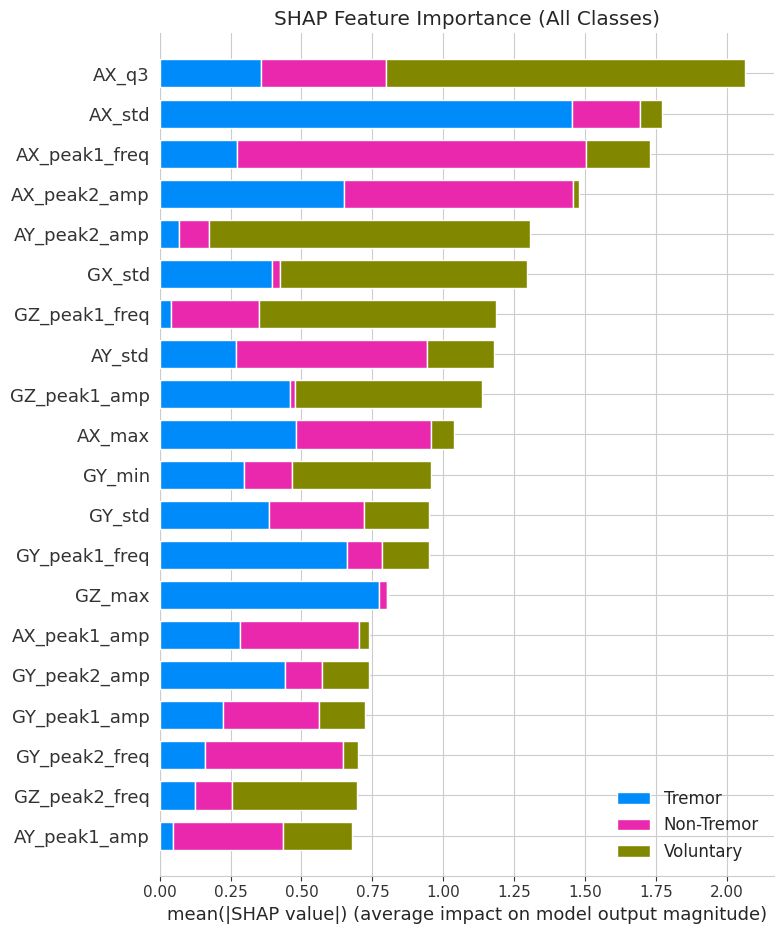


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (21, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,82.67,82.67,17.33,0.0
1,1,Non-Tremor,62.18,62.18,37.82,0.0
2,2,Non-Tremor,62.18,62.18,37.82,0.0
3,3,Non-Tremor,62.18,62.18,37.82,0.0
4,4,Non-Tremor,62.18,62.18,37.82,0.0
5,5,Non-Tremor,62.18,62.18,37.82,0.0
6,6,Non-Tremor,62.18,62.18,37.82,0.0
7,7,Non-Tremor,62.18,62.18,37.82,0.0
8,8,Non-Tremor,62.18,62.18,37.82,0.0
9,9,Non-Tremor,62.18,62.18,37.82,0.0


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-19.27, -3.96, 0.87, -0.31, 0.07, -0.07],
    [-19.61, -4.19, 0.96, 0.33, 0.08, 0.19],
    [-10.92, -2.7, 8.9, 0.78, 0.25, 0.07],
    [-10.64, -2.54, 6.82, 4.37, 2.76, 3.93],
    [-9.19, 4.42, 6.39, 0.46, 0.7, -0.45],
    [-16.77, 4.5, 6.33, 0.61, 1.12, -0.49],
    [-19.61, 1.3, 0.78, 0.06, -1.85, 0.94],
    [-19.47, 1.3, 1.65, 0.35, -0.34, 0.16],
    [-19.61, 1.92, 2.16, -0.13, -0.51, 0.19],
    [-19.34, 2.07, 2.77, 0.01, -0.15, 0.16],
    [-18.94, -0.84, -2.9, 0.35, -1.27, 0.97],
    [-19.61, -0.18, -1.58, 0.2, 1.12, -0.49],
    [-19.61, 0.05, -0.91, -0.14, 1.56, -0.8],
    [-18.47, -0.04, -1.59, -0.16, -2.32, 2.21],
    [-19.61, 2.55, 0.65, 0.02, -1.1, 0.79],
    [-19.61, -1.44, -0.87, -0.04, -0.41, 0.46],
    [-18.76, -0.67, -3.84, 0.05, 0.52, -0.34],
    [-19.61, -1.63, -3.92, 0.26, -0.07, 0.4],
    [-19.18, -1.98, -1.82, 0.39, 0.11, 0.24],
    [-19.61, -2.13, -1.63, 0.45, 0.19, 0.09],
    [-19.61, -2.14, -1.52, 0.48, 0.26, 0.01]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Voluntary



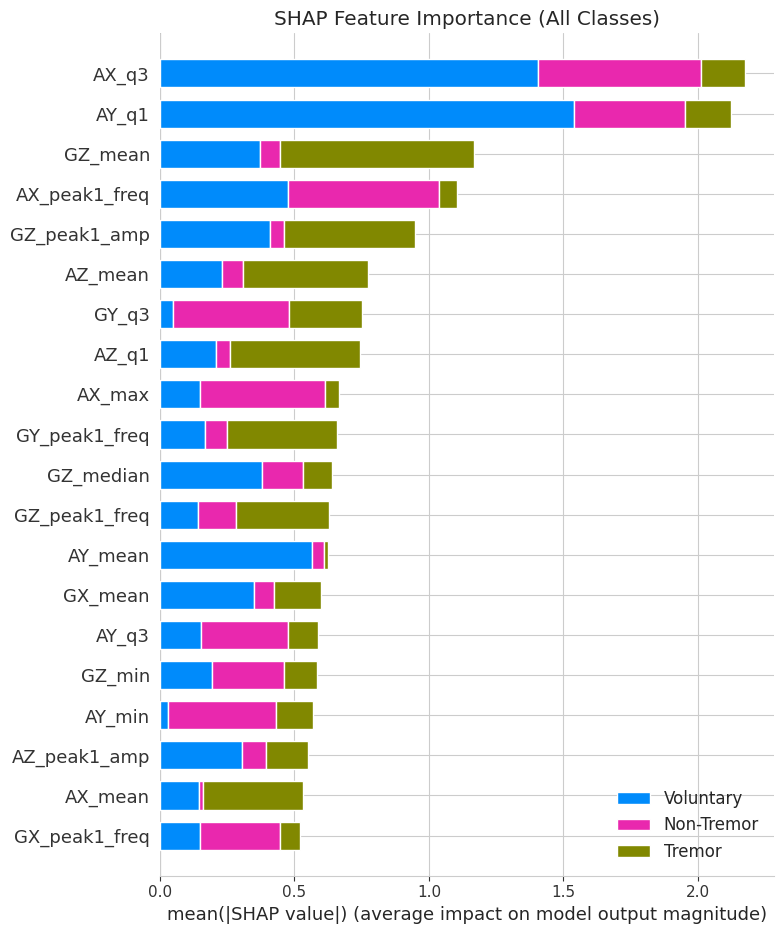


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (26, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Voluntary,93.89,5.47,0.64,93.89
1,1,Voluntary,94.17,4.33,1.49,94.17
2,2,Voluntary,91.24,7.40,1.37,91.24
3,3,Voluntary,92.14,6.54,1.33,92.14
4,4,Voluntary,93.61,5.59,0.81,93.61
5,5,Voluntary,93.92,3.78,2.30,93.92
6,6,Voluntary,86.53,12.83,0.64,86.53
7,7,Voluntary,86.53,12.83,0.64,86.53
8,8,Voluntary,86.53,12.83,0.64,86.53
9,9,Voluntary,86.53,12.83,0.64,86.53


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-1384, 464, -17536, -606, -1188, 810],
    [-1356, 472, -17664, -657, -1112, 810],
    [-1312, 500, -17488, -651, -1073, 820],
    [-1280, 556, -17608, -675, -1025, 807],
    [-1188, 532, -17584, -711, -1048, 777],
    [-1108, 472, -17496, -724, -1058, 741],
    [-1180, 496, -17568, -747, -1083, 752],
    [-1180, 500, -17716, -817, -1109, 727],
    [-1232, 428, -17864, -857, -1131, 760],
    [-1236, 544, -17840, -921, -1126, 794],
    [-1200, 468, -17812, -956, -1122, 795],
    [-1444, 568, -17824, -1020, -1126, 773],
    [-1572, 616, -17820, -1048, -1082, 723],
    [-1512, 704, -17944, -1107, -1044, 711],
    [-1692, 808, -18148, -1112, -945, 702],
    [-1800, 804, -17956, -1135, -875, 745],
    [-1812, 916, -17848, -1133, -744, 708],
    [-1896, 940, -17936, -1092, -629, 707],
    [-1844, 1080, -17728, -1056, -508, 690],
    [-1796, 996, -17760, -1070, -413, 701],
    [-1688, 944, -17808, -1060, -330, 651],
    [-1592, 904, -17952, -1021, -248, 624],
    [-1428, 816, -17920, -1049, -163, 546],
    [-1460, 732, -17916, -1047, -119, 479],
    [-1208, 724, -17844, -1065, -90, 401],
    [-1148, 724, -17848, -1129, -93, 343]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



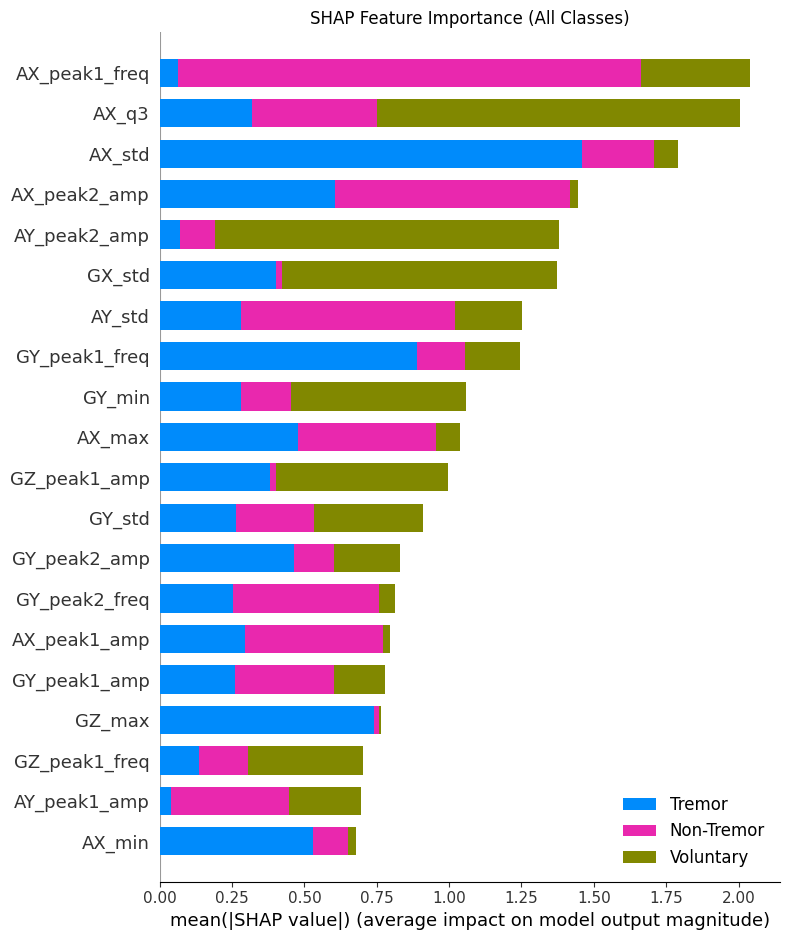


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (19, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,52.97,52.97,47.02,0.0
1,1,Non-Tremor,52.97,52.97,47.02,0.0
2,2,Non-Tremor,52.97,52.97,47.02,0.0
3,3,Non-Tremor,52.97,52.97,47.02,0.0
4,4,Non-Tremor,52.97,52.97,47.02,0.0
5,5,Non-Tremor,52.97,52.97,47.02,0.0
6,6,Non-Tremor,52.97,52.97,47.02,0.0
7,7,Non-Tremor,52.97,52.97,47.02,0.0
8,8,Non-Tremor,52.97,52.97,47.02,0.0
9,9,Non-Tremor,52.97,52.97,47.02,0.0


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-15.88, 0.33, 8.3, -0.22, -0.07, -0.02],
    [-16.11, 0.57, 7.68, 0.01, -0.08, 0.14],
    [-16.62, 0.25, 7.91, -0.04, -0.1, 0.06],
    [-15.64, 0.4, 7.41, -0.1, 0.12, -0.02],
    [-16.09, 1.91, 7.81, 0.08, -0.31, 0.35],
    [-17.23, 0.62, 7.27, -0.09, 0.08, 0.15],
    [-15.73, 1.73, 7.13, -0.14, -0.04, -0.13],
    [-17.08, 0.59, 6.97, 0.05, -0.29, 0.02],
    [-16.81, 1.13, 8.07, 0.02, -0.37, 0.13],
    [-16.33, 0.41, 7.61, -0.27, -0.07, -0.03],
    [-16.68, 0.18, 7.52, -0.14, -0.06, 0.02],
    [-16.31, -0.65, 7.94, 0.01, -0.02, 0.13],
    [-16.49, 0.18, 7.69, -0.08, -0.07, 0.03],
    [-16.62, 0.13, 7.46, 0.07, 0.01, 0.14],
    [-16.18, 1.12, 7.72, -0.15, -0.16, 0.02],
    [-15.67, 0.57, 7.92, 0.01, -0.32, -0.18],
    [-15.84, 0.16, 8.04, -0.02, 0.03, 0],
    [-16.18, 0.29, 8.01, -0.08, -0.09, -0.01],
    [-16.08, -0.17, 7.92, -0.38, 0.02, 0.01]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



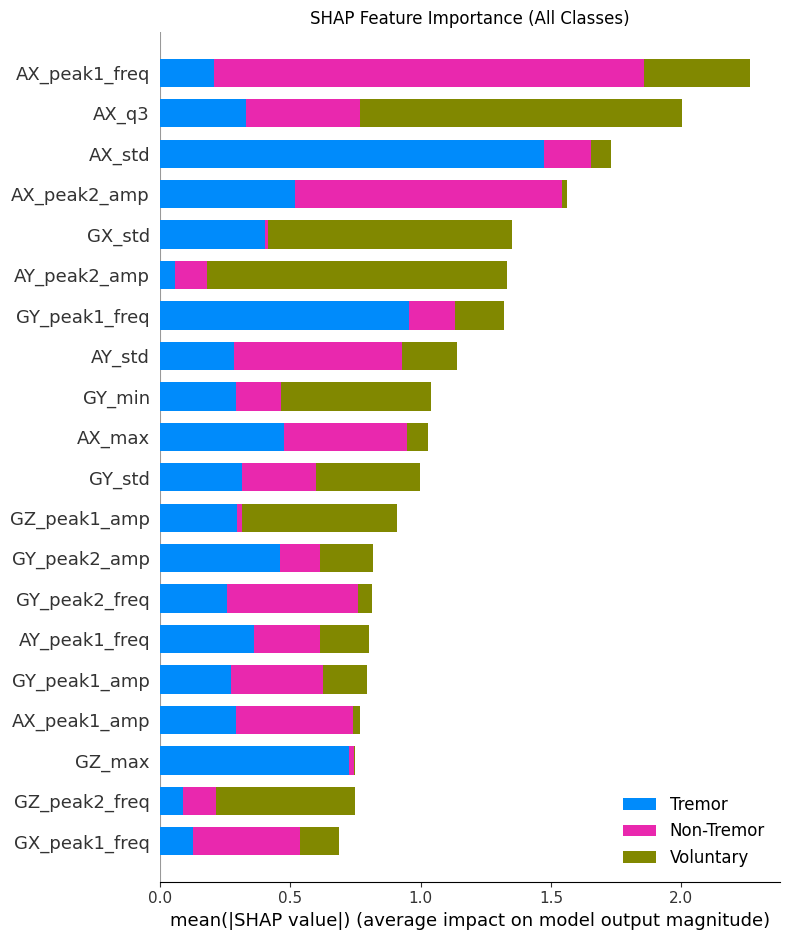


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (19, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,88.91,88.91,11.09,0.00
1,1,Non-Tremor,88.91,88.91,11.09,0.00
2,2,Non-Tremor,88.91,88.91,11.09,0.00
3,3,Non-Tremor,88.91,88.91,11.09,0.00
4,4,Non-Tremor,88.91,88.91,11.09,0.00
5,5,Non-Tremor,88.91,88.91,11.09,0.00
6,6,Non-Tremor,88.91,88.91,11.09,0.00
7,7,Non-Tremor,88.91,88.91,11.09,0.00
8,8,Non-Tremor,88.91,88.91,11.09,0.00
9,9,Non-Tremor,88.91,88.91,11.09,0.00


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-16.14, 0.44, 7.82, -0.01, -0.16, 0.04],
    [-16.19, 0.4, 7.63, 0.05, -0.19, -0.06],
    [-15.74, -0.34, 7.37, -0.1, -0.08, -0.06],
    [-16.48, 0.54, 7.6, -0.01, -0.22, 0.07],
    [-16.32, 0.52, 7.62, -0.18, -0.1, -0.06],
    [-16.4, 0.29, 7.35, -0.08, -0.15, -0.02],
    [-16.03, 0.49, 7.55, -0.13, -0.15, 0.01],
    [-16.49, 0.35, 7.85, -0.05, -0.18, 0.07],
    [-16.04, 0.33, 7.52, 0.02, -0.16, -0.03],
    [-16.34, 0.65, 7.65, -0.15, -0.11, -0.03],
    [-15.82, 0.45, 7.61, -0.11, -0.13, 0],
    [-15.93, 0.1, 7.34, -0.14, -0.04, -0.05],
    [-16.05, 0.17, 7.6, -0.04, -0.2, 0.03],
    [-16.41, 0.49, 7.78, -0.05, -0.18, 0.04],
    [-16.45, 0.54, 7.59, -0.14, -0.09, -0.02],
    [-16.06, 0.54, 7.55, -0.13, -0.15, 0.02],
    [-16.11, 0.36, 7.67, 0, -0.21, 0.06],
    [-16.33, 0.13, 7.42, 0.02, -0.14, -0.01],
    [-16.51, 0.51, 7.74, -0.1, -0.13, -0.01]
]
# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



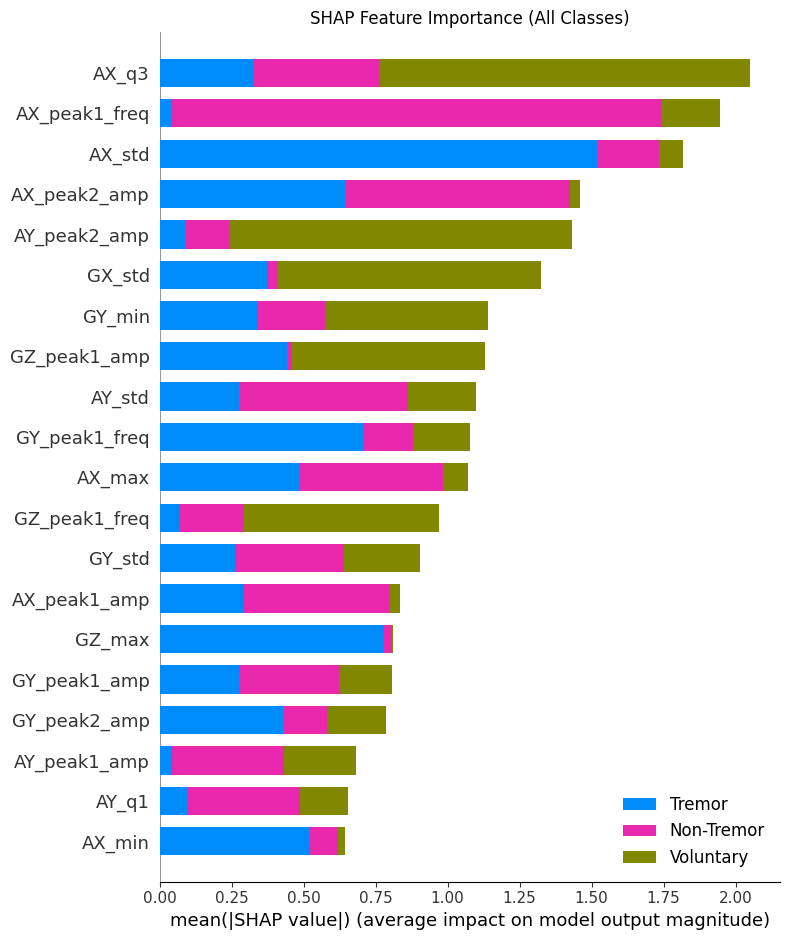


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (24, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,71.99,71.99,28.01,0.0
1,1,Non-Tremor,54.96,54.96,45.04,0.0
2,2,Tremor,55.67,44.32,55.67,0.0
3,3,Tremor,55.67,44.32,55.67,0.0
4,4,Non-Tremor,74.50,74.50,25.49,0.0
5,5,Non-Tremor,74.50,74.50,25.49,0.0
6,6,Non-Tremor,74.50,74.50,25.49,0.0
7,7,Non-Tremor,74.50,74.50,25.49,0.0
8,8,Non-Tremor,74.50,74.50,25.49,0.0
9,9,Non-Tremor,74.50,74.50,25.49,0.0


In [ ]:
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-15.73, -1.82, 7.82, -0.19, -0.09, -0.01],
    [-16.79, -0.62, 8.08, 0.14, -0.26, 0.23],
    [-15.69, -0.33, 8.36, -0.07, -0.08, -0.01],
    [-15.18, -0.39, 8.36, -0.07, -0.13, 0],
    [-15.49, -0.52, 8.32, -0.08, -0.09, 0.02],
    [-14.83, -0.47, 8.47, -0.04, -0.23, 0],
    [-14.74, -0.78, 8.76, -0.08, -0.09, 0.01],
    [-15.27, -0.81, 8.4, 0.02, -0.1, -0.05],
    [-13.92, -0.92, 8.85, -0.14, -0.18, -0.02],
    [-14.98, 0.59, 9.01, 0.9, 0.43, 0.52],
    [-14.53, 3.68, 7.87, -0.04, -0.34, -0.03],
    [-15.06, 3.74, 7.83, 0, 0.11, -0.16],
    [-15.48, 3.45, 7.47, -0.08, -0.04, -0.04],
    [-15.27, 3.33, 7.79, -0.07, -0.06, 0.01],
    [-15.36, 3.3, 7.6, -0.09, -0.09, 0.01],
    [-15.45, 3.26, 7.79, -0.09, -0.12, 0.01],
    [-17.49, 8.24, 3.6, -0.62, 1.67, 1.23],
    [-17.76, 2.72, 6.33, -0.09, 0.11, 0.03],
    [-17.69, 1.73, 6.41, -0.07, -0.06, -0.01],
    [-17.65, 2.23, 6.05, 0.03, -0.13, 0.01],
    [-11.97, -1.21, 7.19, -0.96, -1.12, -0.59],
    [-15.48, 1.38, 8.21, -0.07, -0.1, -0.03],
    [-17.09, 0.39, 7.9, -0.43, -0.07, 0.03],
    [-17.2, 0.16, 8.02, 0.1, 0.04, 0.06]
]
# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)